# Amazon ML Challenge 2026: Business Entity Resolution

## Step 1: Problem statement (summarised from both PDFs)

**Task.** We get business records from **3 independent sources**, each with `entity_id`, `business_name`, `business_address` and `country`. **Source 1 (S1)** is the *deduplicated reference*. For **every S1 entity** we must find **all** S2 and S3 records that refer to the same real-world business. An S1 entity can match zero, one or many S2/S3 records. There is no shared identifier; the source is given only by the `S1-/S2-/S3-` id prefix and by the file.

**Noise to expect** (from the PS): name abbreviations (Corp/Corporation, Pvt/Private, Ltd/Limited), legal-suffix inconsistencies, DBA/trade names, `&` vs `and`, word-order transpositions, typos and transliterations. Address abbreviations (Rd/Road, St/Street), transliteration variants, missing components (no PIN, no state), landmark references ("Near SBI ATM"), municipal numbering formats and component reordering.

**Evaluation metric: macro-averaged F<sub>0.5</sub>.** For each S1 entity *i*, with predicted set $\hat M_i$ and true set $M_i$:

$$P_i=\frac{|\hat M_i\cap M_i|}{|\hat M_i|},\qquad R_i=\frac{|\hat M_i\cap M_i|}{|M_i|},\qquad F_{0.5,i}=\frac{1.25\,P_iR_i}{0.25\,P_i+R_i}$$

$$\text{Score}=\frac{1}{N_{S1}}\sum_i F_{0.5,i}$$

*Singletons* (true $M_i=\emptyset$) score **1.0** if we predict an empty list, else **0.0**. The metric is precision-heavy: β = 0.5 weights precision about twice as much as recall, so false merges cost more than misses.
Edge cases: if we predict ∅ for a non-singleton, *P* is undefined and *R* = 0, so the score is 0.

**Data schema**
| file | columns |
|---|---|
| `train/train_source{1,2,3}.tsv`, `test/test_source{1,2,3}.tsv` | `entity_id`, `business_name`, `business_address`, `country` |
| `train/train_ground_truth.tsv` | `source1_entity_id`, `matched_entity_ids` (comma-separated S2/S3 ids, empty for singletons) |

All files are **tab-separated** (addresses and ID lists contain commas). The training countries are US and India. **The test set adds France**, which never appears in training. `country` must be treated as an *open* set of labels: nothing may be hard-coded, filtered or one-hot-encoded to {US, India}, and every test S1 entity, France included, must appear in the output.

**Submission format.** Two TSV files go in `output/`:
1. `matching_results.tsv` has columns `source1_entity_id` and `matched_entity_ids`. It is the only scored file.
2. `candidate_pairs.tsv` has columns `source1_entity_id` and `candidate_entity_ids`. It holds the exact candidate set fed to the final matching model (the *last* blocking stage), and is used to audit recall ceiling and reduction ratio.

Both files follow the same rules: one row per test S1 entity (no duplicates, none missing); comma-separated lists without quoting; empty value for no matches; only S2/S3 ids that exist in the test set; no duplicate ids within a list; matches ⊆ candidates.

**Constraints and rules**
* Final model: **MIT or Apache-2.0 licence, ≤ 8B parameters**.
* **No external data lookup of any kind**: no ER APIs, business registries, geocoding APIs or internet augmentation. Only the provided training data may be used. (Pre-trained open-licence models and generic libraries are allowed; they are not entity lookups.)
* At most 5 leaderboard submissions per day. The public leaderboard uses a subset of test and the private leaderboard the rest; final rank follows the private leaderboard.
* The final package is a zip containing `output/` (both TSVs), `code/business_entity_resolution/{src/, README.md, requirements.txt}` and a filled `Documentation_template.md` covering methodology, blocking strategy, model architecture and features, experiments and conclusions.
* The challenge window runs from 25 Sep 2026 00:00 IST to 27 Sep 2026 23:59 IST.

**PS update (portal): `candidate_pairs.tsv` is part of the final submission.**
1. *Blocking has to scale.* Comparing every record with every other one is not an option (Amazon resolves billions of records), so blocking must cut the search space to a **small candidate set per S1 entity**.
2. *Candidate generation counts toward the final ranking.* The organisers review `candidate_pairs.tsv` and the code that produces it alongside the `matching_results.tsv` score. **A smaller candidate set per S1 entity ranks higher** in the final evaluation, beyond the leaderboard.

So blocking here is a *two-sided* objective: minimise candidates per S1 while keeping the recall ceiling. The trade-off is chosen explicitly and reported in Steps 5–6.

**Tips given in the PS:** invest in blocking (it bounds recall), use string-similarity features (Jaccard, Levenshtein, TF-IDF cosine), model country-specific address patterns, weigh the precision/recall trade-off, and do not neglect singletons.

**How to read this notebook.** Code cells tagged `eda-only` are analysis and diagnostics. All other code cells form the reproducible pipeline. The same cells are exported verbatim to `code/business_entity_resolution/src/pipeline.py`, which regenerates both output files from the raw TSVs (see its README).

## Environment decision

The original brief asked for a local conda env (Python 3.11). The local machine has **no NVIDIA GPU** (Intel Arc iGPU, 16 GB RAM), so the work moved to cloud GPUs. The notebook detects where it runs and adapts; there are three modes, and the code is identical across them:

| mode | detected by | data | artifacts (cache) | final files |
|---|---|---|---|---|
| **Lightning AI Studio** (used for the final run) | `/teamspace/studios/this_studio` exists | the uploaded `.tsv.gz` / `.tsv` / `.zip` anywhere in the studio → decompressed to `amlc/data/` | `amlc/output/` on the persistent studio disk | `output/` in the studio root, plus the zip |
| Google Colab (development runs) | `/content` exists | `MyDrive/ML_Challenge/data/*.tsv.gz` → local VM disk | local VM disk, `rsync`-backed-up to `MyDrive/ML_Challenge/output/` after every expensive step | `MyDrive/ML_Challenge/output/submission/` |
| script (`src/pipeline.py`) | env `ER_DATA_DIR` set | `ER_DATA_DIR/{train,test}/*.tsv` | `work/artifacts/` | `ER_OUT_DIR` |

Every expensive stage is cached, so a re-run (or a restart after a crash) resumes where it stopped.

All modelling choices are **scaled to the hardware reported in the next cell**: batch sizes, bf16 vs fp16, number of transformer training pairs and chunk sizes all derive from the detected GPU, VRAM, cores and RAM. Development ran on a Colab T4 (2 vCPUs, 12.7 GB RAM), where every stage had to stream in chunks. The final run uses an A100 machine.

In [1]:
import os, sys, gc, re, json, time, math, random, shutil, subprocess, unicodedata, warnings
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
TEAM_NAME = os.environ.get('ER_TEAM', 'team')      # used only for the name of the final zip

if 'ER_DATA_DIR' in os.environ:                       # script mode (src/pipeline.py)
    MODE = 'script'
elif Path('/teamspace/studios/this_studio').exists():   # Lightning AI Studio
    MODE = 'lightning'
elif Path('/content').exists():                        # Google Colab
    MODE = 'colab'
else:                                                  # any other Jupyter machine: behaves like Lightning, rooted at cwd
    MODE = 'lightning'
IN_COLAB = MODE == 'colab'
DRIVE_OUT = None
if MODE == 'colab':
    DRIVE_ROOT = Path('/content/drive/MyDrive/ML_Challenge')
    DRIVE_DATA = DRIVE_ROOT / 'data'                   # gz TSVs uploaded from the local machine
    DRIVE_OUT  = DRIVE_ROOT / 'output'                 # persistent backup of every artifact
    LOCAL      = Path('/content/amlc')                 # fast local VM disk: all reads/writes happen here
    CODE_SRC   = DRIVE_ROOT / 'code' / 'business_entity_resolution'
    FINAL_OUT  = LOCAL / 'output' / 'submission'
elif MODE == 'lightning':
    ROOT       = Path('/teamspace/studios/this_studio') if Path('/teamspace/studios/this_studio').exists() else Path.cwd()
    LOCAL      = ROOT / 'amlc'                         # persistent studio disk
    CODE_SRC   = ROOT / 'code' / 'business_entity_resolution'
    FINAL_OUT  = ROOT / 'output'                       # matching_results.tsv + candidate_pairs.tsv
else:
    DATA_DIR   = Path(os.environ['ER_DATA_DIR'])
    FINAL_OUT  = Path(os.environ.get('ER_OUT_DIR', 'output')).resolve()
    LOCAL      = FINAL_OUT.parent / 'work'
    CODE_SRC   = Path(__file__).resolve().parents[1] if '__file__' in globals() else None
LOCAL_DATA = LOCAL / 'data'                            # decompressed raw TSVs (flat), colab + lightning
OUT = LOCAL / ('output' if MODE != 'script' else 'artifacts')
for d in [OUT, FINAL_OUT]:
    d.mkdir(parents=True, exist_ok=True)

def raw_path(name):
    """Path of a raw TSV, e.g. raw_path('train_source1')."""
    return DATA_DIR / name.split('_')[0] / f'{name}.tsv' if MODE == 'script' else LOCAL_DATA / f'{name}.tsv'

def backup(sub=''):
    """Colab only: mirror local artifacts to Drive after every expensive step (Lightning/script disks are persistent)."""
    if MODE != 'colab': return
    t = time.time(); (DRIVE_OUT / sub).mkdir(parents=True, exist_ok=True)
    subprocess.run(['rsync', '-a', '--size-only', f'{OUT / sub}/', f'{DRIVE_OUT / sub}/'], check=True)
    print(f'[backup] {sub or "all"} -> Drive in {time.time()-t:.0f}s')

try:
    display
except NameError:            # plain python: show tables as text
    def display(x): print(x)

pd.set_option('display.max_colwidth', 110); pd.set_option('display.width', 250); pd.set_option('display.max_columns', 40)
T0 = time.time()
def elapsed(): return f'{(time.time()-T0)/60:.1f} min'
print('mode:', MODE, '| artifacts:', OUT, '| final output:', FINAL_OUT)

mode: lightning | artifacts: /teamspace/studios/this_studio/amlc/output | final output: /teamspace/studios/this_studio/output


In [2]:
# ---- Hardware report ----
import psutil, platform
print('Python  :', sys.version.split()[0], '|', platform.platform())
try:
    cpu = [l.split(':',1)[1].strip() for l in open('/proc/cpuinfo') if l.startswith('model name')][0]
except Exception:
    cpu = platform.processor()
print('CPU     :', cpu, '| logical cores:', os.cpu_count())
vm = psutil.virtual_memory()
print(f'RAM     : {vm.total/2**30:.1f} GiB total, {vm.available/2**30:.1f} GiB available')
print(f'Disk    : {shutil.disk_usage(str(LOCAL.parent if LOCAL.parent.exists() else ".")).free/2**30:.0f} GiB free')
if shutil.which('nvidia-smi'):
    r = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,driver_version', '--format=csv'], capture_output=True, text=True)
    print('nvidia-smi:\n' + r.stdout.strip())
else:
    print('nvidia-smi: not found -> this machine has NO GPU (choose a GPU machine / runtime)')
import torch
HAS_GPU = torch.cuda.is_available()
print('torch', torch.__version__, '| CUDA available:', HAS_GPU, '| CUDA', torch.version.cuda)
if HAS_GPU:
    p = torch.cuda.get_device_properties(0)
    GPU_NAME, GPU_MEM_GB = p.name, p.total_memory/2**30
    # bf16 only where it is native (Ampere+, CC >= 8.0). On a T4 (CC 7.5) torch reports bf16 "supported" but emulates it -> use fp16.
    NATIVE_BF16 = p.major >= 8
    print(f'GPU     : {GPU_NAME}, {GPU_MEM_GB:.1f} GiB VRAM, compute capability {p.major}.{p.minor}, '
          f'native bf16={NATIVE_BF16} -> mixed precision will use {"bf16" if NATIVE_BF16 else "fp16"}')
else:
    NATIVE_BF16 = False
    GPU_NAME, GPU_MEM_GB = None, 0
    print('WARNING: no CUDA GPU. Steps 1-6 run on CPU, but the cross-encoder in Step 7 needs a GPU runtime.')

Python  : 3.12.11 | Linux-6.8.0-60-generic-x86_64-with-glibc2.39
CPU     : AMD EPYC 7J13 64-Core Processor | logical cores: 30
RAM     : 216.3 GiB total, 209.3 GiB available
Disk    : 435 GiB free
nvidia-smi:
name, memory.total [MiB], driver_version
NVIDIA A100-SXM4-40GB, 40960 MiB, 570.148.08


torch 2.8.0+cu128 | CUDA available: True | CUDA 12.8
GPU     : NVIDIA A100-SXM4-40GB, 39.5 GiB VRAM, compute capability 8.0, native bf16=True -> mixed precision will use bf16


In [3]:
# ---- Libraries: installs only what is missing (Colab / Lightning images already ship torch) ----
%pip install -q anyascii rapidfuzz polars lightgbm transformers scikit-learn pyarrow psutil matplotlib scipy joblib
import importlib
for m in ['polars','pandas','numpy','scipy','sklearn','lightgbm','rapidfuzz','anyascii','transformers','torch','matplotlib']:
    try:
        mod = importlib.import_module(m); print(f'{m:22s}', getattr(mod, '__version__', 'ok'))
    except Exception as e:
        print(f'{m:22s} MISSING ({e.__class__.__name__})')

Note: you may need to restart the kernel to use updated packages.
polars                 1.44.2
pandas                 2.1.4
numpy                  1.26.4
scipy                  1.11.4
sklearn                1.3.2
lightgbm               4.7.0
rapidfuzz              3.14.6
anyascii               0.3.3
transformers           5.17.0
torch                  2.8.0+cu128
matplotlib             3.8.2


In [4]:
# ---- Put the 7 raw TSVs in place (decompressed, flat) ----
RAW_NAMES = ['train_source1', 'train_source2', 'train_source3', 'train_ground_truth', 'test_source1', 'test_source2', 'test_source3']
EXPECTED_UPLOAD_BYTES = 1_094_887_778        # size of lightning_upload.zip built on the local machine
def _gunzip(src, dst):
    subprocess.run(f'gunzip -c "{src}" > "{dst}.part" && mv "{dst}.part" "{dst}"', shell=True, check=True)

if all(raw_path(n).exists() for n in RAW_NAMES):
    print('all 7 raw TSVs already prepared -> skipping download / unzip / decompress')
elif MODE == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    LOCAL_DATA.mkdir(parents=True, exist_ok=True); DRIVE_OUT.mkdir(parents=True, exist_ok=True)
    for n in RAW_NAMES:
        if not raw_path(n).exists(): _gunzip(DRIVE_DATA / f'{n}.tsv.gz', raw_path(n))
elif MODE == 'lightning':
    # Accepts any of: the 7 files as .tsv.gz, as .tsv (e.g. train/ and test/ folders), or inside .zip files, anywhere under the studio root.
    import zipfile
    LOCAL_DATA.mkdir(parents=True, exist_ok=True); UNZ = LOCAL / 'unzipped'; UNZ.mkdir(exist_ok=True)
    skip = lambda p: LOCAL in p.parents or '.Trash' in str(p) or '.cache' in str(p)
    def _find(name):
        for base in [ROOT, UNZ]:
            for ext in ['.tsv', '.tsv.gz']:
                hits = [p for p in base.rglob(name + ext) if base == UNZ or not skip(p)]
                if hits: return hits[0]
        return None
    zips = [p for p in ROOT.rglob('*.zip') if not skip(p) and 'submission' not in p.name and 'trained_models' not in p.name]
    for z in zips:
        marker = UNZ / f'.extracted_{z.name}_{z.stat().st_size}'
        if marker.exists():
            print(f'{z.name}: already extracted -> skipping unzip'); continue
        if all(_find(n) is not None for n in RAW_NAMES):
            print(f'{z.name}: data already available -> skipping unzip'); continue
        if not zipfile.is_zipfile(z):
            print(f'  SKIPPED {z.name}: not a complete zip ({z.stat().st_size:,} bytes; the full upload is '
                  f'{EXPECTED_UPLOAD_BYTES:,} bytes) -> the upload is unfinished or broken, upload it again')
            continue
        print('  extracting', z); zipfile.ZipFile(z).extractall(UNZ); marker.touch()
    for n in RAW_NAMES:
        if raw_path(n).exists():
            print(f'{n}: already decompressed -> skipping'); continue
        src = _find(n)
        assert src is not None, (f'{n}.tsv(.gz) not found under {ROOT}. Upload lightning_upload.zip completely '
                                 f'({EXPECTED_UPLOAD_BYTES:,} bytes), or upload the 7 .tsv.gz files directly, then re-run this cell.')
        if src.name.endswith('.gz'): _gunzip(src, raw_path(n))
        else: os.symlink(src, raw_path(n))
if MODE == 'colab':   # restore finished stages from the Drive backup
    t = time.time()
    subprocess.run(['rsync', '-a', '--size-only', f'{DRIVE_OUT}/', f'{OUT}/'], check=True)
    print(f'restored artifact backup from Drive in {time.time()-t:.0f}s:', sorted(p.name for p in OUT.iterdir()))
for n in RAW_NAMES:
    assert raw_path(n).exists(), f'missing {raw_path(n)}'
    print(f'{n:22s} {raw_path(n).stat().st_size/2**20:8.1f} MiB  <- {raw_path(n)}')
print(elapsed())


all 7 raw TSVs already prepared -> skipping download / unzip / decompress
train_source1             200.3 MiB  <- /teamspace/studios/this_studio/amlc/data/train_source1.tsv
train_source2             466.6 MiB  <- /teamspace/studios/this_studio/amlc/data/train_source2.tsv
train_source3             480.4 MiB  <- /teamspace/studios/this_studio/amlc/data/train_source3.tsv
train_ground_truth        121.1 MiB  <- /teamspace/studios/this_studio/amlc/data/train_ground_truth.tsv
test_source1              166.9 MiB  <- /teamspace/studios/this_studio/amlc/data/test_source1.tsv
test_source2              485.9 MiB  <- /teamspace/studios/this_studio/amlc/data/test_source2.tsv
test_source3              482.6 MiB  <- /teamspace/studios/this_studio/amlc/data/test_source3.tsv
0.1 min


# Step 2: Exploratory data analysis

In [5]:
import polars as pl
import matplotlib.pyplot as plt
pl.Config.set_tbl_rows(25); pl.Config.set_fmt_str_lengths(110); pl.Config.set_tbl_width_chars(250)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})

def read_tsv(path):
    # quote_char=None: quotes are literal characters in this data (a handful of names contain '"')
    return pl.read_csv(path, separator='\t', quote_char=None, infer_schema=False)

# expected row counts = `wc -l` minus header, measured on the raw files locally
EXPECTED = {'train_source1': 2206821, 'train_source2': 5034616, 'train_source3': 5285603, 'train_ground_truth': 2206821,
            'test_source1': 1732544, 'test_source2': 4887273, 'test_source3': 5082316}
T = {}
for name, n in EXPECTED.items():
    T[name] = read_tsv(raw_path(name))
    print(f'{name:20s} {str(T[name].shape):>14s}  rows {"OK" if T[name].height == n else "different from the challenge files (%d)" % n}')
SRC = [k for k in T if 'source' in k]

# ground truth -> one row per positive (S1, S2/S3) pair, and per-S1 group sizes (used by EDA, splits and evaluation)
gt = T['train_ground_truth']
pairs = (gt.select(pl.col('source1_entity_id').alias('s1'), pl.col('matched_entity_ids').str.split(',').alias('rid'))
           .explode('rid').filter(pl.col('rid').is_not_null() & (pl.col('rid') != '')))
sizes = (gt.with_columns(pl.col('matched_entity_ids').fill_null('').str.split(',')
              .list.eval(pl.element().filter(pl.element() != '')).alias('ids'))
           .with_columns(pl.col('ids').list.len().alias('n'),
                         pl.col('ids').list.eval(pl.element().str.starts_with('S2-').cast(pl.Int32)).list.sum().alias('n_s2'))
           .with_columns((pl.col('n') - pl.col('n_s2')).alias('n_s3'))
           .join(T['train_source1'].select(pl.col('entity_id').alias('source1_entity_id'), 'country'), on='source1_entity_id')
           .drop('ids'))
INDIC = r'[\p{Devanagari}\p{Bengali}\p{Gujarati}\p{Gurmukhi}\p{Oriya}\p{Tamil}\p{Telugu}\p{Kannada}\p{Malayalam}]'
EXAMPLE_S1 = ['S1-965667', 'S1-314943099', 'S1-836452044', 'S1-224471505', 'S1-18727616']
print('positive pairs:', f'{pairs.height:,}', '| S1 entities:', f'{sizes.height:,}', '|', elapsed())

train_source1          (2206821, 4)  rows OK
train_source2          (5034616, 4)  rows OK
train_source3          (5285603, 4)  rows OK
train_ground_truth     (2206821, 2)  rows OK
test_source1           (1732544, 4)  rows OK
test_source2           (4887273, 4)  rows OK
test_source3           (5082316, 4)  rows OK
positive pairs: 7,638,365 | S1 entities: 2,206,821 | 0.2 min


## 2.1 Shapes, dtypes, missing values, duplicates

In [6]:
# [eda-only] analysis cell, not part of src/pipeline.py
rows = []
for k in SRC:
    df = T[k]; pref = 'S' + k[-1] + '-'
    rows.append({
        'table': k, 'rows': df.height, 'dtypes': '/'.join(sorted(set(map(str, df.dtypes)))),
        'null name %': round(100*df['business_name'].null_count()/df.height, 3),
        'null address %': round(100*df['business_address'].null_count()/df.height, 3),
        'null country %': round(100*df['country'].null_count()/df.height, 3),
        'dup entity_id': df.height - df['entity_id'].n_unique(),
        'bad id prefix': int((~df['entity_id'].str.starts_with(pref)).sum()),
        'exact dup (name,addr,country)': int(df.select(['business_name','business_address','country']).is_duplicated().sum()),
        'dup (name,country)': int(df.select(['business_name','country']).is_duplicated().sum()),
        'untrimmed/double-space name': int(df['business_name'].str.contains(r'^\s|\s$|\s\s').sum()),
        'untrimmed/double-space addr': int(df['business_address'].str.contains(r'^\s|\s$|\s\s').sum()),
    })
display(pd.DataFrame(rows).set_index('table'))

ids23 = pl.concat([T['train_source2'].select('entity_id'), T['train_source3'].select('entity_id')]).rename({'entity_id': 'rid'})
print('GT rows:', gt.height, '| unique S1 in GT:', gt['source1_entity_id'].n_unique(),
      '| S1 file ids covered by GT:', gt['source1_entity_id'].is_in(T['train_source1']['entity_id']).sum())
print('positive pairs:', pairs.height, '| unique matched ids:', pairs['rid'].n_unique(),
      '| matched ids appearing in >1 S1 group:', pairs.height - pairs['rid'].n_unique(),
      '| matched ids missing from S2/S3 files:', pairs.join(ids23, on='rid', how='anti').height)
print('duplicate ids inside one GT list:', gt.filter(pl.col('matched_entity_ids').is_not_null()).select(
      (pl.col('matched_entity_ids').str.split(',').list.len() != pl.col('matched_entity_ids').str.split(',').list.unique().list.len()).sum()).item())
del ids23; gc.collect()

,rows,dtypes,null name %,null address %,null country %,dup entity_id,bad id prefix,"exact dup (name,addr,country)","dup (name,country)",untrimmed/double-space name,untrimmed/double-space addr
table,,,,,,,,,,,
train_source1,2206821,String,0.0,0.000,0.0,0,0,0,844718,0,968
train_source2,5034616,String,0.0,3.356,0.0,0,0,50933,868414,554392,107574
train_source3,5285603,String,0.0,3.328,0.0,0,0,37241,886506,575616,4874
test_source1,1732544,String,0.0,0.000,0.0,0,0,0,623220,0,753
test_source2,4887273,String,0.0,2.648,0.0,0,0,44550,794399,500237,82739
test_source3,5082316,String,0.0,2.678,0.0,0,0,32154,791077,519596,3126


GT rows: 2206821 | unique S1 in GT: 2206821 | S1 file ids covered by GT: 2206821
positive pairs: 7638365 | unique matched ids: 7638365 | matched ids appearing in >1 S1 group: 0 | matched ids missing from S2/S3 files: 0
duplicate ids inside one GT list: 0


0

## 2.2 Country distribution per source, train vs test

country,France,India,US
table,,,
test_source1,259452,809986,663106
test_source2,703378,2312565,1871330
test_source3,731615,2405000,1945701
train_source1,0,883188,1323633
train_source2,0,2017799,3016817
train_source3,0,2115547,3170056


country,France %,India %,US %
table,,,
test_source1,14.98,46.75,38.27
test_source2,14.39,47.32,38.29
test_source3,14.40,47.32,38.28
train_source1,0.00,40.02,59.98
train_source2,0.00,40.08,59.92
train_source3,0.00,40.02,59.98


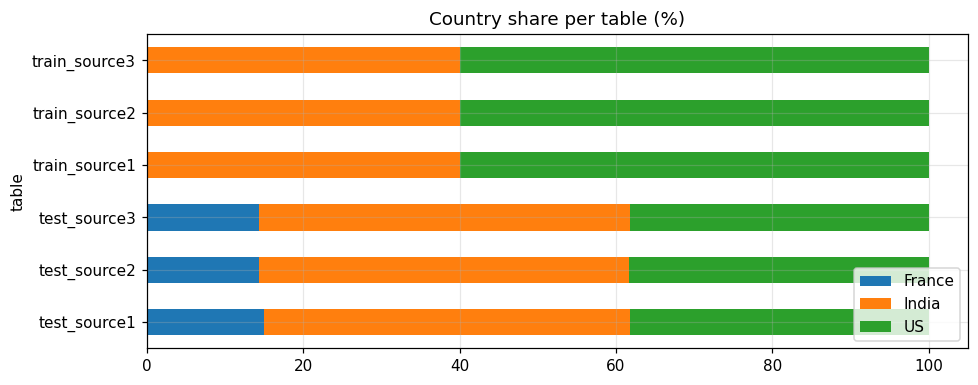

In [7]:
# [eda-only] analysis cell, not part of src/pipeline.py
cc = pl.concat([T[k].group_by('country').len().with_columns(pl.lit(k).alias('table')) for k in SRC])
cc_p = cc.to_pandas().pivot(index='table', columns='country', values='len').fillna(0).astype(int)
cc_share = (cc_p.div(cc_p.sum(1), axis=0)*100).round(2)
display(cc_p); display(cc_share.add_suffix(' %'))
ax = cc_share.plot.barh(stacked=True, figsize=(9, 3.6), title='Country share per table (%)'); ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

## 2.3 Target analysis: group sizes, singletons, S2/S3 composition, distractors

singleton rate (no matches): 5.585%


,country,S1,singleton %,mean matches,mean S2,mean S3,max
0,US,1323633,5.58,3.459,1.672,1.787,11
1,India,883188,5.59,3.465,1.676,1.788,11


,country,records,matched to some S1 %,table
0,India,2017799,73.37,train_source2
1,US,3016817,73.36,train_source2
2,US,3170056,74.62,train_source3
3,India,2115547,74.65,train_source3


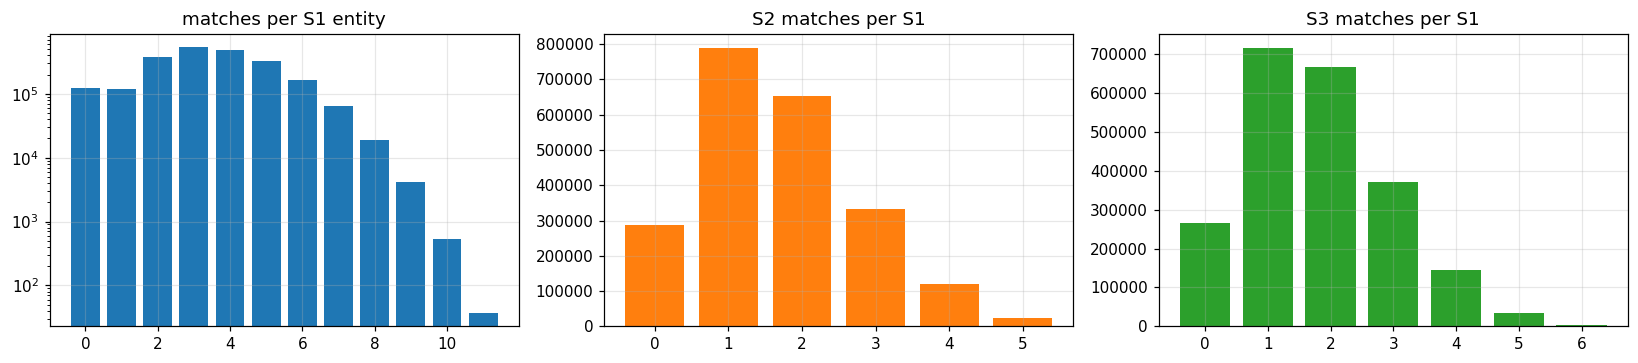

In [8]:
# [eda-only] analysis cell, not part of src/pipeline.py
print('singleton rate (no matches): %.3f%%' % (100*(sizes['n'] == 0).mean()))
display(sizes.group_by('country').agg(pl.len().alias('S1'), (pl.col('n') == 0).mean().mul(100).round(2).alias('singleton %'),
        pl.col('n').mean().round(3).alias('mean matches'), pl.col('n_s2').mean().round(3).alias('mean S2'),
        pl.col('n_s3').mean().round(3).alias('mean S3'), pl.col('n').max().alias('max')).to_pandas())

cov = []
for k in ['train_source2', 'train_source3']:
    d = T[k].with_columns(pl.col('entity_id').is_in(pairs['rid']).alias('m'))
    cov.append(d.group_by('country').agg(pl.len().alias('records'), pl.col('m').mean().mul(100).round(2).alias('matched to some S1 %')).with_columns(pl.lit(k).alias('table')))
display(pl.concat(cov).to_pandas())

fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
vc = sizes['n'].value_counts().sort('n').to_pandas(); ax[0].bar(vc['n'], vc['count']); ax[0].set_title('matches per S1 entity'); ax[0].set_yscale('log')
vc = sizes['n_s2'].value_counts().sort('n_s2').to_pandas(); ax[1].bar(vc['n_s2'], vc['count'], color='C1'); ax[1].set_title('S2 matches per S1')
vc = sizes['n_s3'].value_counts().sort('n_s3').to_pandas(); ax[2].bar(vc['n_s3'], vc['count'], color='C2'); ax[2].set_title('S3 matches per S1')
plt.tight_layout(); plt.show()

## 2.4 Text length and token statistics

name_len_mean  name_len_p95  name_tok_mean  name_tok_p95  addr_len_mean  addr_len_p95  addr_tok_mean  addr_tok_p95  addr_commas_mean  addr_commas_p95  name_len_max  addr_len_max
table         country                                                                                                                                                                                   
test_source1  France            19.4          29.0            3.1           4.0           50.1          65.0            7.2          11.0               2.0              2.0            57           147
              India             26.4          38.0            3.7           5.0           77.7         116.0           11.2          18.0               4.7              8.0            92           268
              US                22.5          35.0            3.4           5.0           35.0          48.0            5.9           8.0               2.2              3.0            66            92
test_source2  France            21.1          35.0            3.2           5.0           40.8          60.0            6.4          10.0               1.7              2.0            61           136
              India             28.3          44.0            3.9           6.0           70.4         110.0           10.4          17.0               4.0              7.0           102           269
              US                24.3          39.0            3.6           6.0           32.8          44.0            5.7           8.0               2.1              3.0            85            75
test_source3  France            21.1          36.0            3.2           5.0           41.2          60.0            6.4          10.0               1.7              2.0            75           139
              India             27.9          44.0            3.9           6.0           60.9         106.0            9.4          17.0               3.8              7.0           103           267
              US                24.6          41.0            3.6           6.0           40.0          54.0            6.1           9.0               2.2              3.0            85           107
train_source1 India             26.4          38.0            3.7           5.0           77.7         116.0           11.2          18.0               4.7              8.0           105           256
              US                22.5          35.0            3.4           5.0           35.0          48.0            5.9           8.0               2.2              3.0            68            93
train_source2 India             27.4          42.0            3.8           6.0           70.2         110.0           10.4          17.0               4.0              7.0           104           249
              US                23.6          39.0            3.5           6.0           32.7          44.0            5.7           8.0               2.1              3.0            87            73
train_source3 India             27.0          43.0            3.8           6.0           61.0         106.0            9.4          17.0               3.8              7.0           123           240
              US                24.0          40.0            3.5           6.0           39.8          53.0            6.1           9.0               2.2              3.0            88           104

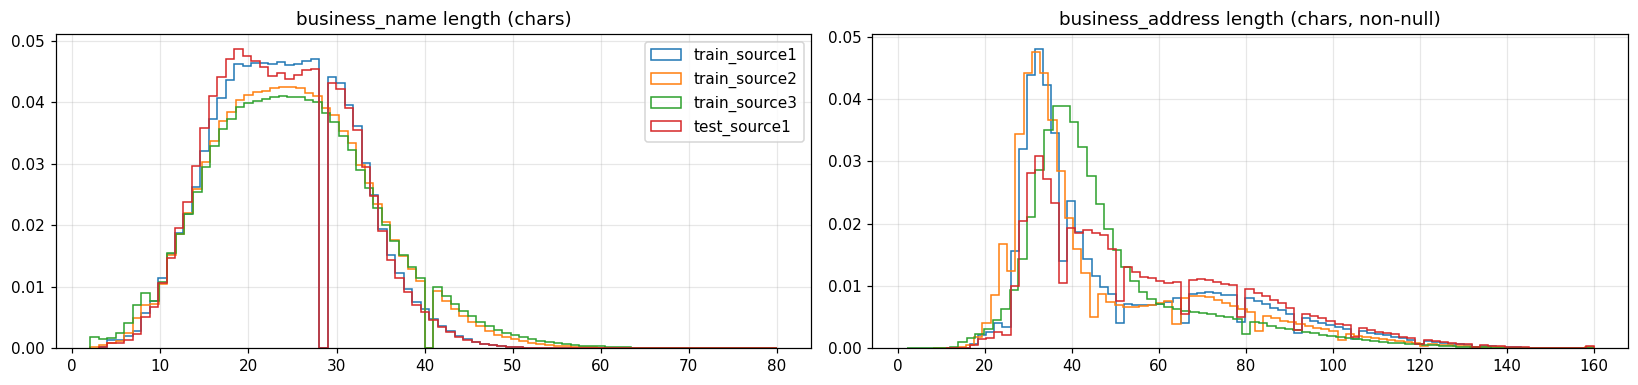

In [9]:
# [eda-only] analysis cell, not part of src/pipeline.py
def text_stats(k):
    return (T[k].select('country',
                       pl.col('business_name').str.len_chars().alias('name_len'),
                       pl.col('business_name').str.split(' ').list.len().alias('name_tok'),
                       pl.col('business_address').str.len_chars().alias('addr_len'),
                       pl.col('business_address').str.split(' ').list.len().alias('addr_tok'),
                       pl.col('business_address').str.count_matches(',').alias('addr_commas'))
              .with_columns(pl.lit(k).alias('table')))
ST = pl.concat([text_stats(k) for k in SRC])
agg = ST.group_by(['table', 'country']).agg(
    *[f(pl.col(c)).round(1).alias(f'{c}_{n}') for c in ['name_len', 'name_tok', 'addr_len', 'addr_tok', 'addr_commas']
      for n, f in [('mean', lambda e: e.mean()), ('p95', lambda e: e.quantile(.95))]],
    pl.col('name_len').max().alias('name_len_max'), pl.col('addr_len').max().alias('addr_len_max')).sort(['table', 'country'])
display(agg.to_pandas().set_index(['table', 'country']))

fig, ax = plt.subplots(1, 2, figsize=(15, 3.6))
for k in [s for s in SRC if s.startswith('train')] + ['test_source1']:
    d = ST.filter(pl.col('table') == k)
    ax[0].hist(d['name_len'].drop_nulls().clip(0, 80).to_numpy(), bins=80, histtype='step', density=True, label=k)
    ax[1].hist(d['addr_len'].drop_nulls().clip(0, 160).to_numpy(), bins=80, histtype='step', density=True, label=k)
ax[0].set_title('business_name length (chars)'); ax[1].set_title('business_address length (chars, non-null)'); ax[0].legend(); plt.tight_layout(); plt.show()

## 2.5 Field-level quality issues
Each flag below is a regex over the raw text. The table shows the percentage of rows per table where the flag fires.

,train_source1,train_source2,train_source3,test_source1,test_source2,test_source3
name: Devanagari script,0.00,5.35,2.99,0.00,6.32,3.56
name: other Indic script,0.00,4.07,2.28,0.00,4.86,2.75
name: accented Latin,0.00,5.77,6.21,2.35,7.81,8.20
name: leading junk (-- << >> etc.),0.14,2.16,2.16,0.13,1.73,1.75
name: junk symbols anywhere (<>|~*),0.01,1.24,1.23,0.01,0.96,0.98
name: looks like a domain (.com/.in..),0.00,4.00,3.99,0.00,3.19,3.23
name: ALL CAPS,0.00,18.90,2.96,0.00,17.49,3.20
name: all lowercase,0.00,5.75,6.25,0.00,5.03,5.53
name: honorific (Smt/Sri/Shri/M/s),0.36,2.24,2.47,0.42,2.64,2.95
name: legal suffix present,63.78,49.95,52.26,68.64,53.48,56.61


train_source1       train_source2        train_source3        test_source2             
                                               India    US            US  India            US  India        India France    US
name: Devanagari script                         0.00  0.00          0.00  13.35          0.00   7.47        13.37   0.00  0.00
name: other Indic script                        0.00  0.00          0.00  10.16          0.00   5.70        10.27   0.00  0.00
name: accented Latin                            0.00  0.00          6.70   4.37          6.80   5.32         3.98  24.54  6.25
name: looks like a domain (.com/.in..)          0.00  0.00          4.40   3.40          4.22   3.64         2.75   3.49  3.63
addr: missing                                   0.00  0.00          3.68   2.87          3.50   3.07         2.28   3.06  2.94
addr: Indic script                              0.00  0.00          0.00  23.67          0.00  22.49        23.81   0.00  0.00
addr: PO BOX                                    0.00  0.00          1.67   0.00          1.57   0.00         0.00   0.00  1.69
addr: landmark (near/opp/behind)               13.26  0.01          0.01  11.33          0.01   8.60        11.39   0.00  0.01
addr: no digit at all                           8.72  0.00          6.12   5.82          5.20   6.87         4.69   3.79  5.00

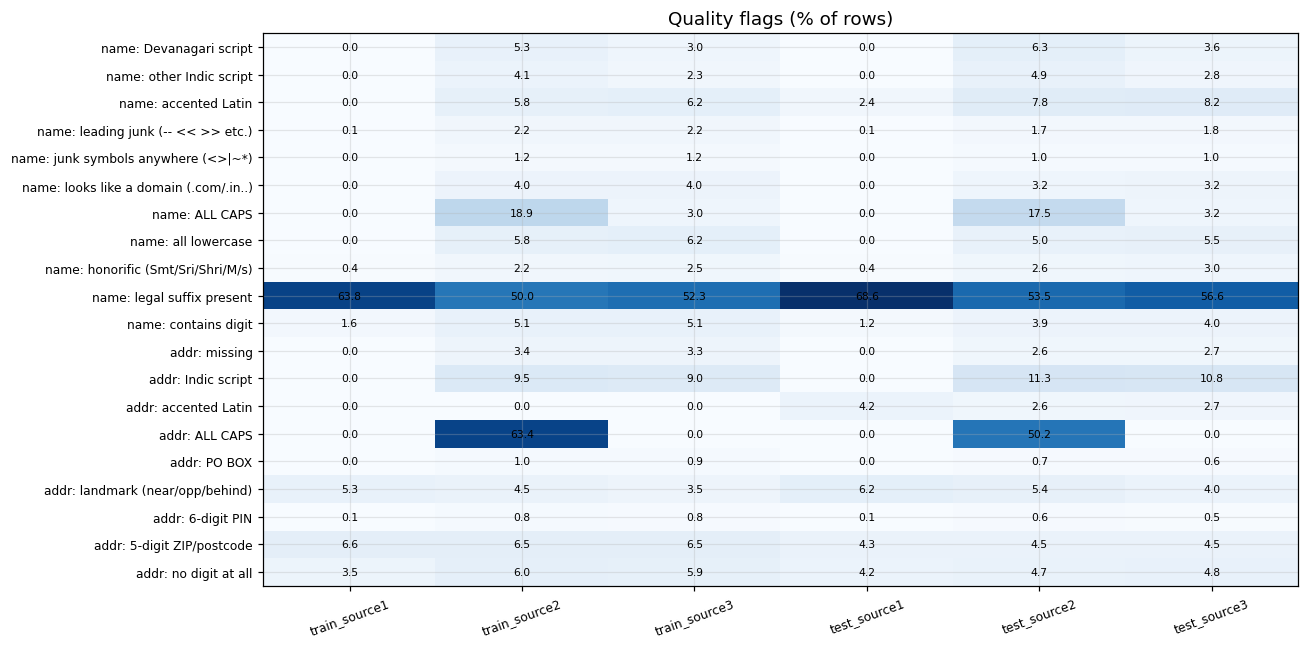

In [10]:
# [eda-only] analysis cell, not part of src/pipeline.py
LEGAL_RX = r'(?i)\b(pvt|private|ltd|limited|inc|incorporated|corp|corporation|llc|llp|lp|plc|co|company|sarl|sas|sasu|sa|sci|eurl|snc|gmbh)\b'
N, A = pl.col('business_name'), pl.col('business_address')
FLAGS = {
    'name: Devanagari script': N.str.contains(r'\p{Devanagari}'),
    'name: other Indic script': N.str.contains(r'[\p{Bengali}\p{Gujarati}\p{Gurmukhi}\p{Oriya}\p{Tamil}\p{Telugu}\p{Kannada}\p{Malayalam}]'),
    'name: accented Latin': N.str.contains(r'[À-ɏ]'),
    'name: leading junk (-- << >> etc.)': N.str.contains(r'^[^\p{L}\p{N}]'),
    'name: junk symbols anywhere (<>|~*)': N.str.contains(r'[<>|~*]|--'),
    'name: looks like a domain (.com/.in..)': N.str.contains(r'(?i)\.(com|in|net|org|co|fr|biz|info)\b'),
    'name: ALL CAPS': (N == N.str.to_uppercase()) & N.str.contains(r'[A-Z]'),
    'name: all lowercase': (N == N.str.to_lowercase()) & N.str.contains(r'[a-z]'),
    'name: honorific (Smt/Sri/Shri/M/s)': N.str.contains(r'(?i)\b(smt|sri|shri|shree|m/s)\b'),
    'name: legal suffix present': N.str.contains(LEGAL_RX),
    'name: contains digit': N.str.contains(r'\d'),
    'addr: missing': A.is_null(),
    'addr: Indic script': A.str.contains(INDIC),
    'addr: accented Latin': A.str.contains(r'[À-ɏ]'),
    'addr: ALL CAPS': (A == A.str.to_uppercase()) & A.str.contains(r'[A-Z]'),
    'addr: PO BOX': A.str.contains(r'(?i)\bp\.?\s?o\.?\s?box\b'),
    'addr: landmark (near/opp/behind)': A.str.contains(r'(?i)\b(near|nr|opp|opposite|behind|beside|back of)\b'),
    'addr: 6-digit PIN': A.str.contains(r'\b\d{6}\b'),
    'addr: 5-digit ZIP/postcode': A.str.contains(r'\b\d{5}\b'),
    'addr: no digit at all': ~A.str.contains(r'\d'),
}
qf = pd.DataFrame({k: T[k].select([e.fill_null(False).mean().mul(100).round(2).alias(n) for n, e in FLAGS.items()]).to_pandas().iloc[0] for k in SRC})
display(qf)
qfc = {}
for k in ['train_source1', 'train_source2', 'train_source3', 'test_source2']:
    for c, g in T[k].group_by('country'):
        qfc[(k, c[0])] = g.select([e.fill_null(False).mean().mul(100).round(2).alias(n) for n, e in FLAGS.items()]).to_pandas().iloc[0]
display(pd.DataFrame(qfc).loc[['name: Devanagari script', 'name: other Indic script', 'name: accented Latin', 'name: looks like a domain (.com/.in..)',
                               'addr: missing', 'addr: Indic script', 'addr: PO BOX', 'addr: landmark (near/opp/behind)', 'addr: no digit at all']])
fig, ax = plt.subplots(figsize=(12, 6)); im = ax.imshow(qf.values, aspect='auto', cmap='Blues')
ax.set_yticks(range(len(qf))); ax.set_yticklabels(qf.index, fontsize=8); ax.set_xticks(range(len(SRC))); ax.set_xticklabels(SRC, rotation=20, fontsize=8)
for i in range(qf.shape[0]):
    for j in range(qf.shape[1]): ax.text(j, i, f'{qf.values[i, j]:.1f}', ha='center', va='center', fontsize=7)
ax.set_title('Quality flags (% of rows)'); plt.tight_layout(); plt.show()

In [11]:
# [eda-only] analysis cell, not part of src/pipeline.py
# A few concrete matched groups (S1 row first, then its S2/S3 matches), to see the noise in context
def show_group(s1_id, split='train'):
    ids = pairs.filter(pl.col('s1') == s1_id)['rid'].to_list()
    rec = pl.concat([T[f'{split}_source1'].filter(pl.col('entity_id') == s1_id),
                     T[f'{split}_source2'].filter(pl.col('entity_id').is_in(ids)),
                     T[f'{split}_source3'].filter(pl.col('entity_id').is_in(ids))])
    display(rec.to_pandas())
for s in EXAMPLE_S1: show_group(s)

,entity_id,business_name,business_address,country
0,S1-965667,Maure Williams Colombier Inc,"85 Wayne Avenue, Ticonderoga, NY",US
1,S2-681193310,Maure Wilblims Colombier Inc,None,US
2,S2-743505751,Maure Williams Colombier,None,US
3,S3-860443364,Maure Williams Inc Center,None,US
4,S3-775321672,Dréxkor,"85 Wanye Avenue, Ticonderoga Townshiip, New York",US
5,S3-11291185,maurewilliamscolombier.com,"Wayne Ave, Ticonderoga Townshiip, New York",US


,entity_id,business_name,business_address,country
0,S1-314943099,Vision Systems,"104 Star Lite Aptd-4 Sector-14 Extn Rohini, New Delhi, North Delhi, Delhi",India
1,S2-138862089,विजन सिस्टम्स,"DOOR NO 104 STAR LITE AFTD-4 SECTOR-14 EXTN ROHINI, NEW DELHI, NORTH DELHI, Delhi",India
2,S3-680498398,Vision 5ystems,"DL, North Delhi, No 104- Star Lite Aptd-4 Sector-14 Extn Rohini",India
3,S3-286650999,Vision Systems,"No 104- Star Lite Aptd-4 Sector-14 Extn Rohini, New Delhi, North Delhi, DL",India
4,S3-675002804,विजन सिस्टम्स,"H.no 104- Star Lite Aptd-4 Sector-14 Extn Rohini, New Delhi, North Delhi, DL",India


,entity_id,business_name,business_address,country
0,S1-836452044,Swastik It Private Limited,"Chakgaria, 1St Floor Baghajatin, Howrah, Kolkata, 2009, West Bengal",India
1,S2-662876320,স্বস্তিক আইটি প্রাইভেট লিমিটেড,"#826 2009, KOLKATA, West Bengal",India
2,S2-545681989,স্বস্তিক আইটি প্রাইভেট লিমিটেড,"HOWRAH, পশ্চিমবঙ্গ, KOLKATA, H.NO 826 2009",India
3,S3-179658632,Swastik It,"2009, Chakgaria, 1St Floor Baghajatin, Kolkata, Howrah, WB",India
4,S3-502065780,Swastik It Private Limited,"2009, Chakgaria, 1St Floor Baghajatin, Kolkata, Howrah, WB",India
5,S3-23947171,স্বস্তিক আইটি প্রাইভেট লিমিটেড,"2009, Kolkata, Howrah, WB",India


,entity_id,business_name,business_address,country
0,S1-224471505,Diya Trading Private Limited,"Kohka Wilderness Camp Private Limited, Village Kohka, Post Turia, Tehsil Kurai, Seoni, Seoni, Madhya Pradesh",India
1,S2-877189098,DIYA TRADING PRIVATE LIMITED,None,India
2,S2-434380302,Smt Diya Traidng Private Limited,"Madhya Pradesh, KOHKA WILDERNESS CAMP PRIVATE LIMITED, VILLAGE KOHKA, POST TURIA, TEHSIL KURAI, SEONI, SEONI",India
3,S3-425299620,Sri diyatrading.com,"Hn 284 Kohka Wilderness Camp Private Limited, Seoni, MP",India
4,S3-900046225,Smt >> diyatrading.com,"Hn 284 Kohka Wilderness Camp Private Limited, Seoni, MP",India
5,S3-941433266,Diya Trading-Limited Partners,None,India


,entity_id,business_name,business_address,country
0,S1-18727616,Lumay Boral,"1056 Belden Avenue, Akron, OH",US
1,S2-755677256,Lumay Boral Inc.,"1056-1060 BELDEN AVE, PO BOX 8807, AKRON, OH",US
2,S3-641489370,Lumay Boral,"1056c Belden Ave, AKON, Ohio",US
3,S3-187831601,Lumay Bóral,"1056c Belden Ave, AKON, Ohio",US
4,S3-476250621,Lumay Bóral,"1056c Belden Avenue, AKON, Ohio",US


## 2.6 How separable are true matches with raw strings?
We sample 30k positive (S1, S2/S3) pairs and 30k *hard-ish* negatives. The negatives are the same S1 records paired with a random S2/S3 record **from the same country**. We then compare raw fuzzy similarities.

positive pairs with different country label: 0 of 30000
name_tsr   AUC(raw lower-cased) = 0.9159   (coverage 100.0%)
addr_tsr   AUC(raw lower-cased) = 0.9985   (coverage 96.2%)
positives: address missing on at least one side: 4.4%
positives: raw name token_set_ratio < 50: 10.7%


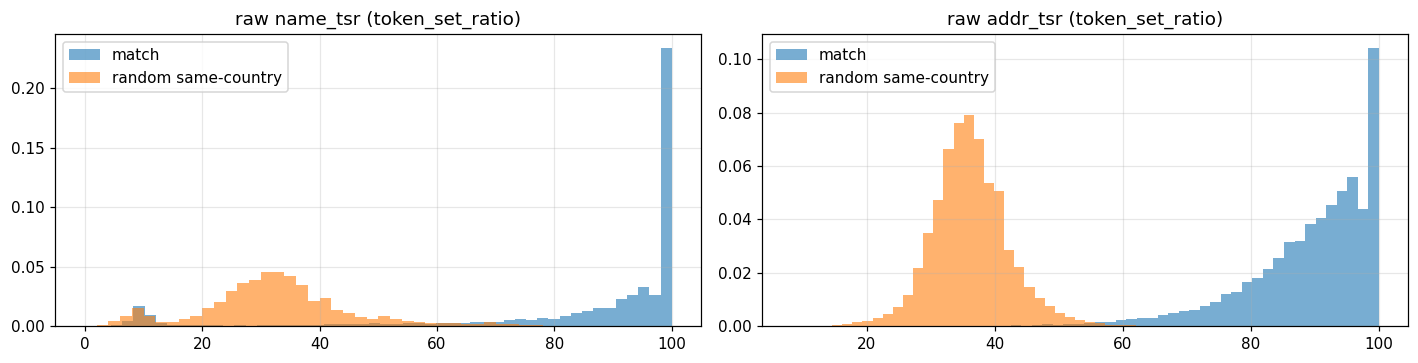

hardest positives by raw name similarity:


,name1,name2,addr1,addr2,c1,name_tsr,addr_tsr
11517,International Solutions,ইন্টারন্যাশনাল সলিউশনস,"1, N. S. Road 2Nd Floor, Kolkata, Kolkata, Howrah, West Bengal","PLOT 159 1, N. S. ROAD 2ND FLOOR, KOLKATA, HOWRAH, West Bengal",India,4.444444,100.000000
23573,Swastik Technologies,स्वस्तिक टेक्नोलॉजीज,"436 Vishnupuri Annex. Bhanwarkunwa, Indore, Madhya Pradesh","H.no 436 Vishnupuri Annex. Bhanwarkunwa, Indore, Madhyapradesh, MP",India,5.000000,91.935484
13461,Dynamic Hospitality,ಡೈನಾಮಿಕ್ ಹಾಸ್ಪಿಟಾಲಿಟಿ,"No.169, 7Th Cross, Anandapuram, New Thippasandra Post, Bangalore, Karnataka","NO.169/9, 7TH CROSS, ANANDAPURAM, NEW THIPPASANDRA POST, BENGALURU, BANGALORE, Karnataka",India,5.000000,94.366197
18570,United Construction,यूनाइटेड कंस्ट्रक्शन,"391 Sector-15A Noida, Gautam Budh Nagar, Gautam Buddha Nagar, Uttar Pradesh","H.no 391 Sector-15a Noida, Gautam Budh Nagar, Gautam Buddha Nagar, UP",India,5.128205,92.156863
25214,Laxmi Investment,லக்ஷ்மி இன்வெஸ்ட்மெண்ட்,"Sf No. 553/1 A1A1B, Melamayur Gst Road, Chengalpattu, Kanchipuram, Tamil Nadu","Block B-28 Sf No. 553/1 A1a1b, Kanchipuram, Chengalpattu, TN",India,5.128205,86.792453
10704,Tirupati Solutions,திருப்பதி சொல்யூஷன்ஸ்,"Manchillu48.Racecourse Road, Coimbatore, Tamil Nadu","DOOR NO 413 MANCHILLU48.RACECOURSE ROAD, COIMBATORE, தமிழ்நாடு",India,5.128205,87.912088
3524,Tech Infrastructure,टेक इंफ्रास्ट्रक्चर,"Villa 112Km, Ground Floor, Gaur Yamuna City, Sector 19, Goutam Budd Nagar, Gautam Buddha Nagar, Uttar Pradesh","BLOCK G-627 VIFLA 112KM, GROUND FLOOR, GAUR YAMUNA CITY, SECTOR 19, GAUTAM BUDDHA NAGAR, GOUTAM BUDD NAGAR...",India,5.263158,96.969697
3766,Universal Producer,यूनिवर्सल प्रोड्यूसर,"Flat No 128 Ist Floor, Govt Employees Cooperative House Building Society Ltd Sector 31 32A, Jharsa, Gurgao...","Haryana, GURGAON, FLAT NO 00128 IST FLOOR, GURGAON",India,5.263158,70.129870
20829,Digital Technologies,डिजिटल टेक्नोलॉजीज,"House No. 80, Upper Floor, Purana Quila Cantt Road, Lucknow, Uttar Pradesh","House No. ##80, Purana Quila Cantt Road, Lucknow, उत्तर प्रदेश",India,5.263158,81.904762
13603,United International,यूनाइटेड इंटरनेशनल,"Flat No. 1103, Tower Kt2, Kalypso Court Jaypee Greens, Wish Town, Sector-128, Noida, Gautam Buddha Nagar, ...","FLAT NO. 110, TOWER KT2, KALYPSO COURT JAYPEE GREENS, WISH TOWN, SECTOR-128, NOIDA, GAUTAM BUDDHA NAGAR, U...",India,5.263158,99.578059


In [12]:
# [eda-only] analysis cell, not part of src/pipeline.py
from rapidfuzz import fuzz
REC_TR = pl.concat([T['train_source2'], T['train_source3']])
s1_tr = T['train_source1'].rename({'entity_id': 's1', 'business_name': 'name1', 'business_address': 'addr1', 'country': 'c1'})
rec_tr = REC_TR.rename({'entity_id': 'rid', 'business_name': 'name2', 'business_address': 'addr2', 'country': 'c2'})
pos = pairs.sample(30000, seed=SEED).join(s1_tr, on='s1').join(rec_tr, on='rid').with_columns(pl.lit(1).alias('y'))
rng = np.random.default_rng(SEED)
negs = []
for c, g in pos.group_by('c1'):
    pool = rec_tr.filter(pl.col('c2') == c[0])
    idx = pl.Series(rng.integers(0, pool.height, g.height))
    negs.append(pl.concat([g.select('s1', 'name1', 'addr1', 'c1'), pool.select(pl.all().gather(idx))], how='horizontal'))
neg = pl.concat(negs).with_columns(pl.lit(0).alias('y'))
SP = pl.concat([pos.select(neg.columns), neg]).to_pandas()
print('positive pairs with different country label:', int((pos['c1'] != pos['c2']).sum()), 'of', pos.height)

def sims(df, n1='name1', n2='name2', a1='addr1', a2='addr2', pre=lambda s: s.lower()):
    f = lambda s: pre(s) if isinstance(s, str) else ''
    out = pd.DataFrame(index=df.index)
    out['name_tsr'] = [fuzz.token_set_ratio(f(a), f(b)) for a, b in zip(df[n1], df[n2])]
    out['addr_tsr'] = [fuzz.token_set_ratio(f(a), f(b)) if isinstance(a, str) and isinstance(b, str) else np.nan for a, b in zip(df[a1], df[a2])]
    return out
raw_s = sims(SP)
from sklearn.metrics import roc_auc_score
for c in raw_s:
    m = raw_s[c].notna()
    print(f'{c:10s} AUC(raw lower-cased) = {roc_auc_score(SP.y[m], raw_s[c][m]):.4f}   (coverage {m.mean():.1%})')
print('positives: address missing on at least one side: %.1f%%' % (100*SP[SP.y == 1][['addr1', 'addr2']].isna().any(axis=1).mean()))
print('positives: raw name token_set_ratio < 50: %.1f%%' % (100*(raw_s.name_tsr[SP.y == 1] < 50).mean()))
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
for i, c in enumerate(['name_tsr', 'addr_tsr']):
    for y, lab in [(1, 'match'), (0, 'random same-country')]:
        ax[i].hist(raw_s[c][SP.y == y].dropna(), bins=50, alpha=.6, density=True, label=lab)
    ax[i].set_title(f'raw {c} (token_set_ratio)'); ax[i].legend()
plt.tight_layout(); plt.show()
print('hardest positives by raw name similarity:')
display(pd.concat([SP[SP.y == 1], raw_s[SP.y == 1]], axis=1).sort_values('name_tsr').head(12)[['name1', 'name2', 'addr1', 'addr2', 'c1', 'name_tsr', 'addr_tsr']])

## 2.7 Train/test distribution differences

In [13]:
# [eda-only] analysis cell, not part of src/pipeline.py
cmp = []
for split in ['train', 'test']:
    for s in '123':
        k = f'{split}_source{s}'
        for c, g in T[k].group_by('country'):
            cmp.append({'split': split, 'source': 'S' + s, 'country': c[0], 'rows': g.height,
                        'name_len': round(g['business_name'].str.len_chars().mean(), 1),
                        'addr_null %': round(100*g['business_address'].null_count()/g.height, 2),
                        'addr_len': round(g['business_address'].str.len_chars().mean(), 1),
                        'indic name %': round(100*g['business_name'].str.contains(INDIC).mean(), 2),
                        'accented name %': round(100*g['business_name'].str.contains(r'[À-ɏ]').mean(), 2),
                        'domain name %': round(100*g['business_name'].str.contains(r'(?i)\.(com|in|net|org|co|fr)\b').mean(), 2)})
cmp = pd.DataFrame(cmp).sort_values(['country', 'source', 'split']).set_index(['country', 'source', 'split'])
display(cmp)
n1_test = T['test_source1'].height; n23_test = T['test_source2'].height + T['test_source3'].height
n1_tr = T['train_source1'].height; n23_tr = T['train_source2'].height + T['train_source3'].height
print(f'S2+S3 records per S1 entity: train {n23_tr/n1_tr:.3f}, test {n23_test/n1_test:.3f}')
for s in '123':
    k = f'test_source{s}'
    print(f'\nFrance sample ({k}):'); display(T[k].filter(pl.col('country') == 'France').sample(6, seed=1).to_pandas())

rows  name_len  addr_null %  addr_len  indic name %  accented name %  domain name %
country source split                                                                                        
France  S1     test    259452      19.4         0.00      50.1          0.00            15.72           0.00
        S2     test    703378      21.1         3.06      40.8          0.00            24.54           3.49
        S3     test    731615      21.1         2.94      41.2          0.00            23.94           3.43
India   S1     test    809986      26.4         0.00      77.7          0.00             0.00           0.00
               train   883188      26.4         0.00      77.7          0.00             0.00           0.00
        S2     test   2312565      28.3         2.28      70.4         23.64             3.98           2.75
               train  2017799      27.4         2.87      70.2         23.51             4.37           3.40
        S3     test   2405000      27.9         2.46      60.9         13.33             4.88           2.96
               train  2115547      27.0         3.07      61.0         13.17             5.32           3.64
US      S1     test    663106      22.5         0.00      35.0          0.00             0.00           0.00
               train  1323633      22.5         0.00      35.0          0.00             0.00           0.00
        S2     test   1871330      24.3         2.94      32.8          0.00             6.25           3.63
               train  3016817      23.6         3.68      32.7          0.00             6.70           4.40
        S3     test   1945701      24.6         2.84      40.0          0.00             6.39           3.48
               train  3170056      24.0         3.50      39.8          0.00             6.80           4.22

S2+S3 records per S1 entity: train 4.677, test 5.754

France sample (test_source1):


,entity_id,business_name,business_address,country
0,S1-932366805,Brazilian Centre EURL,"59 Rue de Cardurand, Saint-Nazaire, Pays de la Loire",France
1,S1-391225264,Établissements Team,"130 Bis Rue des Pavillons, Nantes, Pays de la Loire",France
2,S1-291884026,Pornic Institut EURL,"4 Rue du Traité de Lisbonne, Pornic, Pays de la Loire",France
3,S1-414082748,Roubaix Amicale SARL,"112 Rue de Béthune, Roubaix, Hauts-de-France",France
4,S1-758252118,Pauses & Fils SCI,"28 Rue de Saint-Quentin, Roubaix, Hauts-de-France",France
5,S1-221126882,Canoe Culture (France) SARL,"43 Chemin de la Villes-Ours, Saint-Nazaire, Pays de la Loire",France



France sample (test_source2):


,entity_id,business_name,business_address,country
0,S2-979016342,EU SARL-Collectif,"3 ALL BOIRON, PESSAC",France
1,S2-122840801,Saa SCI & Fils,"10 R DE GUYENNE, PESSAC, Gironde",France
2,S2-439563578,Team Conseil S.A.S.,None,France
3,S2-552560478,ETS 210 HOLDING SAS,"5 CITÉ DU LAC CAZAUX, LA TESTE-DE-BUCH",France
4,S2-421630571,As Section,"24 R MARCEL BILCKE, DUNKERQUE, Hauts-de-France",France
5,S2-783338240,Algerie Ach Amis International SARL,"27 CIRÉ DE L'ÉGLISE SAINT-AUGUSTIN, BORDEAUX",France



France sample (test_source3):


,entity_id,business_name,business_address,country
0,S3-857290700,nantes theatre sas,"Nantes, Loire-Atlantique, 69 Bis Rue Stendhal",France
1,S3-973997301,Comité de Boule S.N.C.,"20 Rue De Tournai, Lille, Hauts-de-France",France
2,S3-7690599,Departementale SARL Services,"40B Av. Du Général De Gaulle, La Teste-de-buch, Gironde",France
3,S3-858579566,Nantes Amis SAS & Co,None,France
4,S3-951057566,Ets Free Eurl,"79 R. De L'epeule, Roubaix, Hauts-de-France",France
5,S3-453693551,Gouttes Çentre SARL,"3 R Régis, Bordeaux",France


## 2.8 Leakage checks
We check whether identifiers or file order encode the answer. If they did, a model could score well offline for the wrong reasons. We **do not** use ids or row order as features either way.

In [14]:
# [eda-only] analysis cell, not part of src/pipeline.py
from scipy.stats import spearmanr
num = lambda e: e.str.slice(3).cast(pl.Int64)
ps = pairs.sample(200000, seed=SEED)
rho_id = spearmanr(ps.select(num(pl.col('s1'))).to_series(), ps.select(num(pl.col('rid'))).to_series()).correlation
S1i = T['train_source1'].select(pl.col('entity_id').alias('s1')).with_row_index('row1')
Ri = pl.concat([T['train_source2'].select(pl.col('entity_id').alias('rid')).with_row_index('rowr'),
                T['train_source3'].select(pl.col('entity_id').alias('rid')).with_row_index('rowr')])
ps2 = ps.join(S1i, on='s1').join(Ri, on='rid')
rho_row = spearmanr(ps2['row1'], ps2['rowr']).correlation
g2 = gt.with_row_index('g').join(S1i, left_on='source1_entity_id', right_on='s1')
gt_order = spearmanr(g2['g'], g2['row1']).correlation
print(f'Spearman(S1 id number, matched id number) = {rho_id:+.4f}')
print(f'Spearman(S1 file row, matched record file row) = {rho_row:+.4f}')
print(f'Spearman(GT row order, S1 file row) = {gt_order:+.4f}')
tr_ids = pl.concat([S1i.select(pl.col('s1').alias('id')), Ri.select(pl.col('rid').alias('id'))])
te_ids = pl.concat([T[f'test_source{s}'].select(pl.col('entity_id').alias('id')) for s in '123'])
print('test ids also present in train:', te_ids.join(tr_ids, on='id').height)
key = lambda df: df.select(pl.concat_str([pl.col('business_name').fill_null(''), pl.col('business_address').fill_null(''), 'country'], separator='|')).to_series()
print('test S1 rows whose exact (name|addr|country) appears in train S1:', int(key(T['test_source1']).is_in(key(T['train_source1']).unique()).sum()))
del tr_ids, te_ids, S1i, Ri, ps2, g2; gc.collect()

Spearman(S1 id number, matched id number) = +0.0014
Spearman(S1 file row, matched record file row) = +0.0019
Spearman(GT row order, S1 file row) = +0.0003
test ids also present in train: 0
test S1 rows whose exact (name|addr|country) appears in train S1: 0


29384

# Step 3: Data preprocessing

Every transformation is chosen to cancel a *documented noise pattern*, so that true pairs look identical and the model only has to handle the residual noise.

| # | transformation | noise it removes | applied to |
|---|---|---|---|
| 1 | Unicode NFKC + `anyascii` transliteration (ISC licence, offline rule tables, no lookup) | Devanagari, Bengali, Odia and other Indic spellings of English names; injected accents (`Bóral`, `Léarning`) | name, address |
| 2 | lower-casing, whitespace collapse | case (ALL CAPS in S2), double spaces | both |
| 3 | `&`→`and`, `M/s`, `L.L.C`, `S.A.S` … collapsed before punctuation stripping | punctuation variants of the same token | name |
| 4 | domain stems (`diyatrading.com` → `diyatrading`) + `is_domain` flag | website-style names in S3 | name |
| 5 | junk symbol removal (`--`, `<<`, `>>`, `|`) | injected leading/trailing junk | both |
| 6 | legal-form canonicalisation (`private`→`pvt`, `limited`→`ltd`, `corporation`→`corp` …) plus a separate `legal` field | legal-suffix inconsistencies | name |
| 7 | honorific removal (Smt, Sri, Shri, M/s, Mr, Dr …) from the *core* name | honorific prefixes | name |
| 8 | `name_core` (no legal/honorific tokens) and `name_sq` (core with spaces removed) | word splits and domain concatenations (`diya trading` ↔ `diyatrading`) | name |
| 9 | PO-BOX removal | PO boxes added in S2 but absent from S1 | address |
| 10 | per-component state canonicalisation (country-specific dictionaries with a generic fallback) | `New York` ↔ `NY`, `Madhya Pradesh` ↔ `MP`, `Orissa` ↔ `OD` | address |
| 11 | street-type / direction / Indian and French address vocabulary canonicalisation (`Road`→`rd`, `Avenue`→`ave`, `R.`→`rue`, `Extension`→`extn`) | abbreviation variants | address |
| 12 | ordinal stripping (`1st`→`1`), filler removal (`No`, `H.No`, `Door No`, `#`) | municipal numbering formats | address |
| 13 | structured extraction: all numbers, ZIP/PIN (5–6 digits), state code, has-address flag | enables numeric/attribute match features and blocking keys | address |

Component *reordering* (`DL, North Delhi, No 104 …` vs `No 104 …, North Delhi, DL`) is deliberately **not** "fixed" by re-sorting. Instead, all downstream similarities are order-invariant (token-set, sorted-token, and numeric-set features).

**Deduplication.** S1 is already deduplicated by construction. S2/S3 contain many near-identical rows, but these are *legitimate multiple matches* of the same S1 entity (see §2.3: up to 10 matches per S1), so they must **not** be collapsed. Dropping them would lose recall. Exact duplicates are instead exploited later, since identical records share their decision.

**Missing values.** Missing addresses stay as null and get a `has_addr` flag; they are never imputed. Null-aware features let the model learn that "no address" is weaker evidence rather than a mismatch.

**Open-set countries.** Country-specific dictionaries (US states, Indian states) are applied only where they apply. Any other label (France, or anything else) falls through to the generic pipeline. Nothing is filtered or one-hot-encoded by country.

In [15]:
from anyascii import anyascii

NORM_VERSION = 'v1'
NORM_DIR = OUT / 'norm'; NORM_DIR.mkdir(parents=True, exist_ok=True)

def _to_ascii(s):
    return anyascii(unicodedata.normalize('NFKC', s))

def translit(series: pl.Series) -> pl.Series:
    """Transliterate only the non-ASCII strings (deduplicated), map back vectorised.
    Single process on purpose: fork() after polars' thread pool has started can deadlock, and anyascii is fast."""
    uniq = series.filter(series.str.contains(r'[^\x00-\x7F]').fill_null(False)).unique()
    if uniq.len() == 0:
        return series
    out = [_to_ascii(x) for x in uniq.to_list()]
    return series.replace(uniq, pl.Series(out, dtype=pl.String))

for s in ['विजन सिस्टम्स', 'राम मार्केटिंग प्राइवेट लिमिटेड', 'स्वस्तिक आइटी प्राइवेट लिमिटेड', 'স্বস্তিক আইটি প্রাইভেট লিমিটেড',
          'आदित्य प्रॉपर्टीज एलएलपी', 'मॉडर्न फाइनेंस', 'ଓଡ଼ିଶା', 'পশ্চিমবঙ্গ', 'Lumay Bóral', 'Moncada Léarning Center', 'SCI Ptit Àmicale', 'Ｆｕｌｌ－ｗｉｄｔｈ']:
    print(f'{s:38s} -> {_to_ascii(s)}')

विजन सिस्टम्स                          -> vijn sistms
राम मार्केटिंग प्राइवेट लिमिटेड        -> ram marketimg praivet limited
स्वस्तिक आइटी प्राइवेट लिमिटेड         -> svstik aiti praivet limited
স্বস্তিক আইটি প্রাইভেট লিমিটেড         -> sbstik aiti praibhet limited
आदित्य प्रॉपर्टीज एलएलपी               -> adity proprtij elelpi
मॉडर्न फाइनेंस                         -> modrn phainems
ଓଡ଼ିଶା                                 -> od'isa
পশ্চিমবঙ্গ                             -> pscimbng
Lumay Bóral                            -> Lumay Boral
Moncada Léarning Center                -> Moncada Learning Center
SCI Ptit Àmicale                       -> SCI Ptit Amicale
Ｆｕｌｌ－ｗｉｄｔｈ                             -> Full-width


In [16]:
# ---- Dictionaries ----
LEGAL_CANON = {
    'private': 'pvt', 'pvt': 'pvt', 'pte': 'pvt', 'pvtltd': 'pvt', 'limited': 'ltd', 'ltd': 'ltd', 'ltda': 'ltd',
    'incorporated': 'inc', 'inc': 'inc', 'corporation': 'corp', 'corp': 'corp', 'corpn': 'corp',
    'company': 'co', 'co': 'co', 'cie': 'co', 'llc': 'llc', 'llp': 'llp', 'lp': 'lp', 'plc': 'plc',
    'sarl': 'sarl', 'sas': 'sas', 'sasu': 'sas', 'sa': 'sa', 'eurl': 'eurl', 'sci': 'sci', 'snc': 'snc',
    'gmbh': 'gmbh', 'pty': 'pty', 'opc': 'opc',
    # transliterated Indic spellings of the same legal words (from anyascii outputs above)
    'praivet': 'pvt', 'praaivet': 'pvt', 'praivett': 'pvt', 'prayvet': 'pvt', 'limited': 'ltd', 'limitedd': 'ltd', 'limitad': 'ltd',
    'elelpi': 'llp', 'elelpii': 'llp', 'kampani': 'co', 'kompani': 'co', 'inka': 'inc',
}
LEGAL_VALS = sorted(set(LEGAL_CANON.values()))
HONORIFICS = ['smt', 'sri', 'shri', 'shree', 'sh', 'mr', 'mrs', 'ms', 'dr', 'kumari', 'messrs', 'the']
DROP_NAME = LEGAL_VALS + HONORIFICS

NAME_PRE = [  # applied to the lower-cased ASCII name, in order
    (r'\bm\s*/\s*s\b\.?', ' '),
    (r'\bl\.\s*l\.\s*c\b\.?', ' llc '), (r'\bl\.\s*l\.\s*p\b\.?', ' llp '),
    (r'\bs\.\s*a\.\s*r\.\s*l\b\.?', ' sarl '), (r'\bs\.\s*a\.\s*s\b\.?', ' sas '), (r'\bs\.\s*a\.(\s|$)', ' sa '),
    (r'\bp\.?\s*ltd\b', ' pvt ltd '), (r'&', ' and '),
]
DOMAIN_RX = r'\b(?:www\.)?([a-z0-9][a-z0-9-]*)\.(?:co\.in|com|in|net|org|co|fr|biz|info|us)\b'

US_STATE = {'alabama': 'al', 'alaska': 'ak', 'arizona': 'az', 'arkansas': 'ar', 'california': 'ca', 'colorado': 'co', 'connecticut': 'ct',
    'delaware': 'de', 'district of columbia': 'dc', 'washington dc': 'dc', 'florida': 'fl', 'georgia': 'ga', 'hawaii': 'hi', 'idaho': 'id',
    'illinois': 'il', 'indiana': 'in', 'iowa': 'ia', 'kansas': 'ks', 'kentucky': 'ky', 'louisiana': 'la', 'maine': 'me', 'maryland': 'md',
    'massachusetts': 'ma', 'michigan': 'mi', 'minnesota': 'mn', 'mississippi': 'ms', 'missouri': 'mo', 'montana': 'mt', 'nebraska': 'ne',
    'nevada': 'nv', 'new hampshire': 'nh', 'new jersey': 'nj', 'new mexico': 'nm', 'new york': 'ny', 'north carolina': 'nc',
    'north dakota': 'nd', 'ohio': 'oh', 'oklahoma': 'ok', 'oregon': 'or', 'pennsylvania': 'pa', 'rhode island': 'ri',
    'south carolina': 'sc', 'south dakota': 'sd', 'tennessee': 'tn', 'texas': 'tx', 'utah': 'ut', 'vermont': 'vt', 'virginia': 'va',
    'washington': 'wa', 'west virginia': 'wv', 'wisconsin': 'wi', 'wyoming': 'wy', 'puerto rico': 'pr'}
IN_STATE = {'andhra pradesh': 'ap', 'arunachal pradesh': 'ar', 'assam': 'as', 'bihar': 'br', 'chhattisgarh': 'cg', 'chattisgarh': 'cg', 'ct': 'cg',
    'goa': 'ga', 'gujarat': 'gj', 'haryana': 'hr', 'himachal pradesh': 'hp', 'jharkhand': 'jh', 'karnataka': 'ka', 'kerala': 'kl',
    'madhya pradesh': 'mp', 'maharashtra': 'mh', 'manipur': 'mn', 'meghalaya': 'ml', 'mizoram': 'mz', 'nagaland': 'nl',
    'odisha': 'od', 'orissa': 'od', 'or': 'od', 'punjab': 'pb', 'rajasthan': 'rj', 'sikkim': 'sk', 'tamil nadu': 'tn', 'tamilnadu': 'tn',
    'telangana': 'ts', 'tg': 'ts', 'tripura': 'tr', 'uttar pradesh': 'up', 'uttarakhand': 'uk', 'uttaranchal': 'uk', 'ut': 'uk',
    'west bengal': 'wb', 'delhi': 'dl', 'nct of delhi': 'dl', 'jammu and kashmir': 'jk', 'ladakh': 'la', 'puducherry': 'py',
    'pondicherry': 'py', 'chandigarh': 'ch', 'andaman and nicobar islands': 'an', 'lakshadweep': 'ld',
    'dadra and nagar haveli': 'dn', 'daman and diu': 'dd'}
STATE_CODES = sorted(set(US_STATE.values()) | set(IN_STATE.values()))

ADDR_MAP = {
    'street': 'st', 'str': 'st', 'strt': 'st', 'saint': 'st', 'avenue': 'ave', 'av': 'ave', 'avn': 'ave', 'avenu': 'ave',
    'road': 'rd', 'drive': 'dr', 'drv': 'dr', 'lane': 'ln', 'boulevard': 'blvd', 'bd': 'blvd', 'boul': 'blvd', 'bvd': 'blvd',
    'court': 'ct', 'place': 'pl', 'highway': 'hwy', 'parkway': 'pkwy', 'circle': 'cir', 'terrace': 'ter', 'terr': 'ter',
    'square': 'sq', 'apartment': 'apt', 'apts': 'apt', 'suite': 'ste', 'floor': 'fl', 'flr': 'fl', 'building': 'bldg', 'bld': 'bldg',
    'north': 'n', 'south': 's', 'east': 'e', 'west': 'w', 'northeast': 'ne', 'northwest': 'nw', 'southeast': 'se', 'southwest': 'sw',
    'mount': 'mt', 'fort': 'ft', 'sector': 'sec', 'extension': 'extn', 'ext': 'extn', 'colony': 'col', 'district': 'dist', 'dt': 'dist',
    'village': 'vill', 'vil': 'vill', 'tehsil': 'teh', 'tahsil': 'teh', 'taluk': 'tq', 'taluka': 'tq', 'tk': 'tq',
    'opposite': 'opp', 'near': 'nr', 'post': 'po', 'nagar': 'ngr', 'township': 'twp',
    'rue': 'rue', 'r': 'rue', 'chemin': 'chem', 'che': 'chem', 'impasse': 'imp', 'allee': 'all', 'route': 'rte', 'faubourg': 'fbg',
    'residence': 'res', 'batiment': 'bat', 'quai': 'qu', 'cours': 'crs'}
ADDR_FILL = ['no', 'nos', 'number', 'num', 'hno', 'dno', 'h', 'd', 'door', '']
POBOX_RX = r'\bp\.?\s*o\.?\s*box\s*\d*'
print(len(LEGAL_CANON), 'legal tokens |', len(US_STATE) + len(IN_STATE), 'state names |', len(ADDR_MAP), 'address tokens')

40 legal tokens | 100 state names | 71 address tokens


In [17]:
def normalize_table(df: pl.DataFrame, src: int) -> pl.DataFrame:
    """Raw source table -> normalised record table (one row per entity_id, raw fields kept for display/models)."""
    df = df.rename({'business_name': 'name', 'business_address': 'addr'})
    df = df.with_columns(pl.col('name').fill_null('').str.strip_chars(), pl.col('addr').str.strip_chars(),
                         pl.col('country').fill_null('UNKNOWN'))
    df = df.with_columns(name_a=translit(df['name']), addr_a=translit(df['addr']))

    # ---------- name ----------
    e = pl.col('name_a').str.to_lowercase()
    for pat, rep in NAME_PRE:
        e = e.str.replace_all(pat, rep)
    is_dom = e.str.contains(DOMAIN_RX)
    e = e.str.replace_all(DOMAIN_RX, ' ${1} ').str.replace_all(r'[^a-z0-9]+', ' ').str.strip_chars()
    ntok = e.str.split(' ').list.eval(pl.element().filter(pl.element() != '').replace(LEGAL_CANON))
    df = df.with_columns(is_domain=is_dom, name_indic=pl.col('name').str.contains(INDIC), _nt=ntok)
    df = df.with_columns(
        name_norm=pl.col('_nt').list.join(' '),
        legal=pl.col('_nt').list.eval(pl.element().filter(pl.element().is_in(LEGAL_VALS))).list.unique().list.sort().list.join(' '),
        _ct=pl.col('_nt').list.eval(pl.element().filter(~pl.element().is_in(DROP_NAME))))
    df = df.with_columns(name_core=pl.when(pl.col('_ct').list.len() > 0).then(pl.col('_ct').list.join(' ')).otherwise(pl.col('name_norm')))
    df = df.with_columns(name_sq=pl.col('name_core').str.replace_all(' ', ''))

    # ---------- address ----------
    a = pl.col('addr_a').str.to_lowercase().str.replace_all('&', ' and ').str.replace_all(POBOX_RX, ' ')
    comps = a.str.split(',').list.eval(pl.element().str.replace_all(r'[.\s]+$', '').str.replace_all(r'\s+', ' ').str.strip_chars())
    comps = (pl.when(pl.col('country') == 'US').then(comps.list.eval(pl.element().replace(US_STATE)))
               .when(pl.col('country') == 'India').then(comps.list.eval(pl.element().replace(IN_STATE)))
               .otherwise(comps))
    df = df.with_columns(_a=a, _comps=comps)
    atok = (pl.col('_comps').list.join(' ').str.replace_all(r'\b(\d+)(st|nd|rd|th)\b', '${1}')
              .str.replace_all(r'[^a-z0-9]+', ' ').str.strip_chars().str.split(' ')
              .list.eval(pl.element().replace(ADDR_MAP).filter(~pl.element().is_in(ADDR_FILL))))
    df = df.with_columns(
        addr_norm=pl.when(pl.col('addr').is_null()).then(None).otherwise(atok.list.join(' ')),
        state=pl.col('_comps').list.eval(pl.element().filter(pl.element().is_in(STATE_CODES))).list.last(),
        addr_nums=pl.col('_a').str.extract_all(r'\d+').list.unique(maintain_order=True),
        zip=pl.col('_a').str.extract_all(r'\b\d{5,6}\b').list.last(),
        has_addr=pl.col('addr').is_not_null(),
        addr_indic=pl.col('addr').str.contains(INDIC).fill_null(False),
        src=pl.lit(src, dtype=pl.Int8))
    return df.select('entity_id', 'src', 'country', 'name', 'addr', 'name_norm', 'name_core', 'name_sq', 'legal', 'is_domain',
                     'name_indic', 'addr_norm', 'addr_nums', 'zip', 'state', 'has_addr', 'addr_indic')

In [18]:
# [eda-only] analysis cell, not part of src/pipeline.py
# unit examples (hand-written strings covering each rule)
demo = pl.DataFrame({'entity_id': [f'X-{i}' for i in range(9)],
    'business_name': ['Smt >> diyatrading.com', 'M/s. Ram Marketing Pvt. Ltd.', 'राम मार्केटिंग प्राइवेट लिमिटेड', 'B & G Holdings L.L.C.',
                      '-- Holloway Peak Inc Seafood', 'Houston  Patriot Solupdomer', 'SCI Ptit Àmicale', 'Marina Ecole France S.A.S.', 'Inc'],
    'business_address': ['Hn 284 Kohka Wilderness Camp Private Limited, Seoni, MP', 'DOOR NO 104 STAR LITE AFTD-4 SECTOR-14 EXTN ROHINI, NEW DELHI, NORTH DELHI, Delhi',
                         'Khordha, ଓଡ଼ିଶା, Bhubaneswar, Plot No. 59/5894 Jagannath Nagar Road No.1', '1056-1060 BELDEN AVE, PO BOX 8807, AKRON, OH',
                         '#10041 Whitehall Garden, Munster CDDP, Indiana', '85 Wanye Avenue, Ticonderoga Townshiip, New York', '18 RUE JEN ZAY, Dunkerque, Nord',
                         '63 R. DE DIEPPE, LILLE, Hauts-de-France', None],
    'country': ['India', 'India', 'India', 'US', 'US', 'US', 'France', 'France', 'US']})
display(normalize_table(demo, 9).drop('entity_id', 'src').to_pandas())

,country,name,addr,name_norm,name_core,name_sq,legal,is_domain,name_indic,addr_norm,addr_nums,zip,state,has_addr,addr_indic
0,India,Smt >> diyatrading.com,"Hn 284 Kohka Wilderness Camp Private Limited, Seoni, MP",smt diyatrading,diyatrading,diyatrading,,True,False,hn 284 kohka wilderness camp private limited seoni mp,[284],None,mp,True,False
1,India,M/s. Ram Marketing Pvt. Ltd.,"DOOR NO 104 STAR LITE AFTD-4 SECTOR-14 EXTN ROHINI, NEW DELHI, NORTH DELHI, Delhi",ram marketing pvt ltd,ram marketing,rammarketing,ltd pvt,False,False,104 star lite aftd 4 sec 14 extn rohini new delhi n delhi dl,"[104, 4, 14]",None,dl,True,False
2,India,राम मार्केटिंग प्राइवेट लिमिटेड,"Khordha, ଓଡ଼ିଶା, Bhubaneswar, Plot No. 59/5894 Jagannath Nagar Road No.1",ram marketimg pvt ltd,ram marketimg,rammarketimg,ltd pvt,False,True,khordha od isa bhubaneswar plot 59 5894 jagannath ngr rd 1,"[59, 5894, 1]",None,None,True,True
3,US,B & G Holdings L.L.C.,"1056-1060 BELDEN AVE, PO BOX 8807, AKRON, OH",b and g holdings llc,b and g holdings,bandgholdings,llc,False,False,1056 1060 belden ave akron oh,"[1056, 1060]",None,oh,True,False
4,US,-- Holloway Peak Inc Seafood,"#10041 Whitehall Garden, Munster CDDP, Indiana",holloway peak inc seafood,holloway peak seafood,hollowaypeakseafood,inc,False,False,10041 whitehall garden munster cddp in,[10041],10041,in,True,False
5,US,Houston Patriot Solupdomer,"85 Wanye Avenue, Ticonderoga Townshiip, New York",houston patriot solupdomer,houston patriot solupdomer,houstonpatriotsolupdomer,,False,False,85 wanye ave ticonderoga townshiip ny,[85],None,ny,True,False
6,France,SCI Ptit Àmicale,"18 RUE JEN ZAY, Dunkerque, Nord",sci ptit amicale,ptit amicale,ptitamicale,sci,False,False,18 rue jen zay dunkerque nord,[18],None,None,True,False
7,France,Marina Ecole France S.A.S.,"63 R. DE DIEPPE, LILLE, Hauts-de-France",marina ecole france sas,marina ecole france,marinaecolefrance,sas,False,False,63 rue de dieppe lille hauts de france,[63],None,None,True,False
8,US,Inc,None,inc,inc,inc,inc,False,False,None,None,None,None,False,False


In [19]:
# ---- Run normalisation on all 6 source tables (cached parquet on local disk, backed up to Drive) ----
for v in ['REC_TR', 's1_tr', 'rec_tr', 'ST', 'pos', 'neg', 'cmp', 'qfc']:   # EDA intermediates (absent in script mode)
    globals().pop(v, None)
gc.collect()
def norm_path(split, s): return NORM_DIR / f'{split}_s{s}_{NORM_VERSION}.parquet'
def nt(split, s, cols=None):  # normalised table, optionally only some columns (keeps RAM low)
    return pl.read_parquet(norm_path(split, s), columns=cols)
def nts(split, s):             # lazy scan
    return pl.scan_parquet(norm_path(split, s))
for split in ['train', 'test']:
    for s in '123':
        p = norm_path(split, s)
        raw = T.pop(f'{split}_source{s}')      # free each raw table as soon as it is processed (12.7 GB RAM)
        if p.exists():                          # verify the cache (an interrupted write must not be trusted)
            try:
                ok = pl.scan_parquet(p).select(pl.len()).collect().item() == raw.height
            except Exception:
                ok = False
            if ok:
                print(f'{p.name}: cached'); del raw; gc.collect(); continue
            print(f'{p.name}: incomplete cache -> recomputing'); p.unlink()
        t = time.time()
        nd = normalize_table(raw, int(s)); del raw
        tmp = p.with_suffix('.tmp'); nd.write_parquet(tmp); tmp.rename(p)   # atomic: never leaves a half-written file
        print(f'{p.name}: {nd.shape} in {time.time()-t:.0f}s | RAM used {psutil.virtual_memory().used/2**30:.1f} GiB')
        del nd; gc.collect()
T.clear(); gc.collect()   # raw tables no longer needed; everything downstream reads the normalised parquet
backup('norm')
print(elapsed())

train_s1_v1.parquet: (2206821, 17) in 2s | RAM used 16.4 GiB
train_s2_v1.parquet: (5034616, 17) in 11s | RAM used 16.9 GiB
train_s3_v1.parquet: (5285603, 17) in 12s | RAM used 17.1 GiB
test_s1_v1.parquet: (1732544, 17) in 2s | RAM used 15.5 GiB
test_s2_v1.parquet: (4887273, 17) in 14s | RAM used 15.9 GiB
test_s3_v1.parquet: (5082316, 17) in 13s | RAM used 15.9 GiB
3.0 min


In [20]:
# [eda-only] analysis cell, not part of src/pipeline.py
# ---- Before / after on real matched groups ----
COLS = ['entity_id', 'name', 'name_core', 'legal', 'addr', 'addr_norm', 'addr_nums', 'zip', 'state']
for s1_id in EXAMPLE_S1[:4]:
    ids = [s1_id] + pairs.filter(pl.col('s1') == s1_id)['rid'].to_list()
    display(pl.concat([nts('train', s).filter(pl.col('entity_id').is_in(ids)).select(COLS).collect() for s in '123']).to_pandas())
print('Random test rows per country (incl. France):')
TEST_COUNTRIES = nt('test', '1', ['country'])['country'].unique().sort().to_list()
display(pl.concat([nts('test', s).filter(pl.col('country') == c).head(20000).collect().sample(2, seed=3)
                   for s in '123' for c in TEST_COUNTRIES]).select(['country'] + COLS).to_pandas())

,entity_id,name,name_core,legal,addr,addr_norm,addr_nums,zip,state
0,S1-965667,Maure Williams Colombier Inc,maure williams colombier,inc,"85 Wayne Avenue, Ticonderoga, NY",85 wayne ave ticonderoga ny,[85],None,ny
1,S2-681193310,Maure Wilblims Colombier Inc,maure wilblims colombier,inc,None,None,None,None,None
2,S2-743505751,Maure Williams Colombier,maure williams colombier,,None,None,None,None,None
3,S3-860443364,Maure Williams Inc Center,maure williams center,inc,None,None,None,None,None
4,S3-775321672,Dréxkor,drexkor,,"85 Wanye Avenue, Ticonderoga Townshiip, New York",85 wanye ave ticonderoga townshiip ny,[85],None,ny
5,S3-11291185,maurewilliamscolombier.com,maurewilliamscolombier,,"Wayne Ave, Ticonderoga Townshiip, New York",wayne ave ticonderoga townshiip ny,[],None,ny


,entity_id,name,name_core,legal,addr,addr_norm,addr_nums,zip,state
0,S1-314943099,Vision Systems,vision systems,,"104 Star Lite Aptd-4 Sector-14 Extn Rohini, New Delhi, North Delhi, Delhi",104 star lite aptd 4 sec 14 extn rohini new delhi n delhi dl,"[104, 4, 14]",None,dl
1,S2-138862089,विजन सिस्टम्स,vijn sistms,,"DOOR NO 104 STAR LITE AFTD-4 SECTOR-14 EXTN ROHINI, NEW DELHI, NORTH DELHI, Delhi",104 star lite aftd 4 sec 14 extn rohini new delhi n delhi dl,"[104, 4, 14]",None,dl
2,S3-680498398,Vision 5ystems,vision 5ystems,,"DL, North Delhi, No 104- Star Lite Aptd-4 Sector-14 Extn Rohini",dl n delhi 104 star lite aptd 4 sec 14 extn rohini,"[104, 4, 14]",None,dl
3,S3-286650999,Vision Systems,vision systems,,"No 104- Star Lite Aptd-4 Sector-14 Extn Rohini, New Delhi, North Delhi, DL",104 star lite aptd 4 sec 14 extn rohini new delhi n delhi dl,"[104, 4, 14]",None,dl
4,S3-675002804,विजन सिस्टम्स,vijn sistms,,"H.no 104- Star Lite Aptd-4 Sector-14 Extn Rohini, New Delhi, North Delhi, DL",104 star lite aptd 4 sec 14 extn rohini new delhi n delhi dl,"[104, 4, 14]",None,dl


,entity_id,name,name_core,legal,addr,addr_norm,addr_nums,zip,state
0,S1-836452044,Swastik It Private Limited,swastik it,ltd pvt,"Chakgaria, 1St Floor Baghajatin, Howrah, Kolkata, 2009, West Bengal",chakgaria 1 fl baghajatin howrah kolkata 2009 wb,"[1, 2009]",None,wb
1,S2-662876320,স্বস্তিক আইটি প্রাইভেট লিমিটেড,sbstik aiti praibhet,ltd,"#826 2009, KOLKATA, West Bengal",826 2009 kolkata wb,"[826, 2009]",None,wb
2,S2-545681989,স্বস্তিক আইটি প্রাইভেট লিমিটেড,sbstik aiti praibhet,ltd,"HOWRAH, পশ্চিমবঙ্গ, KOLKATA, H.NO 826 2009",howrah pscimbng kolkata 826 2009,"[826, 2009]",None,None
3,S3-179658632,Swastik It,swastik it,,"2009, Chakgaria, 1St Floor Baghajatin, Kolkata, Howrah, WB",2009 chakgaria 1 fl baghajatin kolkata howrah wb,"[2009, 1]",None,wb
4,S3-502065780,Swastik It Private Limited,swastik it,ltd pvt,"2009, Chakgaria, 1St Floor Baghajatin, Kolkata, Howrah, WB",2009 chakgaria 1 fl baghajatin kolkata howrah wb,"[2009, 1]",None,wb
5,S3-23947171,স্বস্তিক আইটি প্রাইভেট লিমিটেড,sbstik aiti praibhet,ltd,"2009, Kolkata, Howrah, WB",2009 kolkata howrah wb,[2009],None,wb


,entity_id,name,name_core,legal,addr,addr_norm,addr_nums,zip,state
0,S1-224471505,Diya Trading Private Limited,diya trading,ltd pvt,"Kohka Wilderness Camp Private Limited, Village Kohka, Post Turia, Tehsil Kurai, Seoni, Seoni, Madhya Pradesh",kohka wilderness camp private limited vill kohka po turia teh kurai seoni seoni mp,[],None,mp
1,S2-877189098,DIYA TRADING PRIVATE LIMITED,diya trading,ltd pvt,None,None,None,None,None
2,S2-434380302,Smt Diya Traidng Private Limited,diya traidng,ltd pvt,"Madhya Pradesh, KOHKA WILDERNESS CAMP PRIVATE LIMITED, VILLAGE KOHKA, POST TURIA, TEHSIL KURAI, SEONI, SEONI",mp kohka wilderness camp private limited vill kohka po turia teh kurai seoni seoni,[],None,mp
3,S3-425299620,Sri diyatrading.com,diyatrading,,"Hn 284 Kohka Wilderness Camp Private Limited, Seoni, MP",hn 284 kohka wilderness camp private limited seoni mp,[284],None,mp
4,S3-900046225,Smt >> diyatrading.com,diyatrading,,"Hn 284 Kohka Wilderness Camp Private Limited, Seoni, MP",hn 284 kohka wilderness camp private limited seoni mp,[284],None,mp
5,S3-941433266,Diya Trading-Limited Partners,diya trading partners,ltd,None,None,None,None,None


Random test rows per country (incl. France):


,country,entity_id,name,name_core,legal,addr,addr_norm,addr_nums,zip,state
0,France,S1-840392378,Familiale Section SAS,familiale section,sas,"20 Avenue Landois, Nantes, Pays de la Loire",20 ave landois nantes pays de la loire,[20],None,None
1,France,S1-226041700,Institut Saint Notre,institut saint notre,,"67 Chemin de la Perrière, Saint-Nazaire, Pays de la Loire",67 chem de la perriere st nazaire pays de la loire,[67],None,None
2,India,S1-339930040,Shanker (india) Private Limited,shanker india,ltd pvt,"C/O Natthu Lak Tiwari, Pancharat, Ward No 11, Gola, Kheri, Uttar Pradesh",c o natthu lak tiwari pancharat ward 11 gola kheri up,[11],None,up
3,India,S1-289775087,Bangalore South Hr Private Limited,bangalore south hr,ltd pvt,"Karnataka, No 55/44, F3, V R Terrace, R Terrace, Nobo Nagar, 7T, Bangalore, Bangalore South",ka 55 44 f3 v rue ter rue ter nobo ngr 7t bangalore bangalore s,"[55, 44, 3, 7]",None,ka
4,US,S1-762149211,Proia LLC,proia,llc,"WI, 17561 Hideaway Court, Town Of Mishicot",wi 17561 hideaway ct town of mishicot,[17561],17561,wi
5,US,S1-686460738,Clean Software Networks Inc,clean software networks,inc,"399 Hairr Lane, Salemburg, NC",399 hairr ln salemburg nc,[399],None,nc
6,France,S2-184941906,TU JEUNES SCI,tu jeunes,sci,"10 CH DU ROMARIN, LILLE, Nord",10 ch du romarin lille nord,[10],None,None
7,France,S2-634021217,#marcheclub,marcheclub,,"NO 33 RUE JEAN JACQUES ROUSSEAU, ROUBAIX, Hauts-de-France",33 rue jean jacques rousseau roubaix hauts de france,[33],None,None
8,India,S2-478010098,Alpha Products Agencies,alpha products agencies,,"45 KHALIDI COMPOUND, AIWANE SHAHIROAD GULBARGA - 585 102., Karnataka",45 khalidi compound aiwane shahiroad gulbarga 585 102 ka,"[45, 585, 102]",None,ka
9,India,S2-187215619,Devin Realty Private Ltd,devin realty,ltd pvt,"345, SECTOR -THETA-2, JAITPUR VAISHPUR, NOIDA, Uttar Pradesh",345 sec theta 2 jaitpur vaishpur noida up,"[345, 2]",None,up


In [21]:
# [eda-only] analysis cell, not part of src/pipeline.py
# ---- Does normalisation make matches more separable? (same 60k pairs as in 2.6) ----
s1n = nt('train', '1').select(pl.col('entity_id').alias('s1'), pl.col('name').alias('rn1'), pl.col('addr').alias('ra1'),
                            pl.col('name_core').alias('n1'), pl.col('name_sq').alias('q1'), pl.col('addr_norm').alias('a1'))
rn = pl.concat([nt('train', '2'), nt('train', '3')]).select(pl.col('entity_id').alias('rid'), pl.col('name').alias('rn2'), pl.col('addr').alias('ra2'),
                                                       pl.col('name_core').alias('n2'), pl.col('name_sq').alias('q2'), pl.col('addr_norm').alias('a2'))
spn = pl.from_pandas(SP[['s1', 'rid', 'y']]).join(s1n, on='s1').join(rn, on='rid').to_pandas()
def auc_of(f, a, b):
    v = np.array([f(x, y) if isinstance(x, str) and isinstance(y, str) else np.nan for x, y in zip(spn[a], spn[b])], dtype=float)
    m = ~np.isnan(v); return roc_auc_score(spn.y[m], v[m])
low = lambda f: (lambda x, y: f(x.lower(), y.lower()))
res = pd.DataFrame([
    ('name token_set_ratio', auc_of(low(fuzz.token_set_ratio), 'rn1', 'rn2'), auc_of(fuzz.token_set_ratio, 'n1', 'n2')),
    ('name ratio (squashed core)', auc_of(low(fuzz.ratio), 'rn1', 'rn2'), auc_of(fuzz.ratio, 'q1', 'q2')),
    ('address token_set_ratio', auc_of(low(fuzz.token_set_ratio), 'ra1', 'ra2'), auc_of(fuzz.token_set_ratio, 'a1', 'a2')),
    ('address token_sort_ratio', auc_of(low(fuzz.token_sort_ratio), 'ra1', 'ra2'), auc_of(fuzz.token_sort_ratio, 'a1', 'a2')),
], columns=['similarity', 'AUC raw (lower-cased)', 'AUC normalised']).set_index('similarity')
res['gain'] = res.iloc[:, 1] - res.iloc[:, 0]
display(res.round(4))
del s1n, rn; gc.collect()

,AUC raw (lower-cased),AUC normalised,gain
similarity,,,
name token_set_ratio,0.9159,0.9821,0.0662
name ratio (squashed core),0.9160,0.9852,0.0692
address token_set_ratio,0.9985,0.9997,0.0012
address token_sort_ratio,0.9888,0.9932,0.0045


0

# Step 4: Feature engineering

This step **defines** the pair features. They are *computed* on candidate pairs only: first the cheap subset inside stage-2 blocking (Step 5), then the full set on the final candidates of every split (Step 6.2). That is about 8 pairs per S1, so roughly 14M test pairs rather than 10<sup>13</sup>. Families:

| family | features |
|---|---|
| **name lexical** | rapidfuzz `ratio`, `token_set`, `token_sort`, `partial_ratio` on the core name; Jaro-Winkler, normalised Levenshtein, common prefix/suffix on the squashed name; `token_set` on the full normalised name (with legal forms); token Jaccard; char 2–4-gram **TF-IDF cosine** |
| **name attributes** | lengths and token counts, legal-form equal / conflicting / missing, domain-style flags, Indic-script flags per side |
| **address lexical** | `token_set`, `token_sort`, `ratio`, `partial_ratio`, token Jaccard, char 3-gram TF-IDF cosine |
| **numeric / attribute match** | number-set Jaccard and intersection size, first-number equality, ZIP/PIN equality, state equality, each with explicit *missing* indicators |
| **blocking evidence** | stage-1 IDF score, number of shared keys, per-family IDF sums (name token, name pair, squashed, prefix, address token, address bigram, zip, number) and rank |
| **competition / context** | stage-2 probability and rank; probability relative to the best in the S1 list; list size; number of S1 lists that contain the record; the record's best competing score and runner-up gap |
| **transformer** (Step 7) | fine-tuned cross-encoder logit on the raw (original-script) text |

Missing values are encoded as −1 with explicit indicators, never imputed as matches. No feature uses the country label, so France is scored by the same functions as US and India.

In [22]:
# ---- (a) fast features: used by the stage-2 blocking re-ranker (Step 5) and kept for the matcher ----
from rapidfuzz import process, fuzz
from rapidfuzz.distance import JaroWinkler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

KEY_FAMILIES = ['t', 'n', 'q', 'p', 'a', 'b', 'z', 'm']   # blocking key families (Step 5); their IDF sums are features
FAST_COLS = ['name_core', 'name_sq', 'addr_norm', 'zip']
def side_tables(split):
    s1f = nt(split, '1', FAST_COLS).with_row_index('i1')
    rf = pl.concat([nt(split, s, FAST_COLS + ['src']) for s in '23']).with_row_index('ir')
    return s1f, rf, pl.read_parquet(rstats_path(split))

def cp(a, b, scorer):
    return process.cpdist(a, b, scorer=scorer, workers=-1, dtype=np.float32)

RR_FEATS = ['bscore', 'bkeys', 'brank', 'b_rel', 's_n', 'r_n', 'r_rel', 'r_best', 'r_gap2'] + [f'b_{f}' for f in KEY_FAMILIES] + \
           ['n_ratio', 'n_tset', 'n_jw', 'a_tset', 'a_miss', 'zip_eq', 'zip_miss', 'src3']
def fast_features(c: pl.DataFrame, s1f, rf, rs) -> pl.DataFrame:
    d = (c.join(s1f, on='i1').join(rf, on='ir', suffix='_r').join(rs, on='ir', how='left')
          .with_columns(s_max=pl.col('bscore').max().over('i1'), s_n=pl.len().over('i1')))
    a_miss = (d['addr_norm'].is_null() | d['addr_norm_r'].is_null()).to_numpy()
    a_tset = cp(d['addr_norm'].fill_null('').to_list(), d['addr_norm_r'].fill_null('').to_list(), fuzz.token_set_ratio)
    a_tset[a_miss] = -1
    zip_miss = (d['zip'].is_null() | d['zip_r'].is_null()).to_numpy()
    zip_eq = (d['zip'] == d['zip_r']).fill_null(False).to_numpy().astype(np.float32); zip_eq[zip_miss] = -1
    n1, n2 = d['name_core'].to_list(), d['name_core_r'].to_list()
    return d.select(
        'i1', 'ir', pl.col('bscore').log1p(), 'bkeys', 'brank', (pl.col('bscore') / pl.col('s_max')).alias('b_rel'), 's_n',
        pl.col('r_n').fill_null(0), (pl.col('bscore') / pl.col('r_max')).alias('r_rel'),
        (pl.col('bscore') >= pl.col('r_max')).cast(pl.Int8).alias('r_best'), (pl.col('bscore') - pl.col('r_2nd')).alias('r_gap2'),
        *[f'b_{f}' for f in KEY_FAMILIES], (pl.col('src') == 3).cast(pl.Int8).alias('src3'),
    ).with_columns(
        n_ratio=pl.Series(cp(n1, n2, fuzz.ratio)), n_tset=pl.Series(cp(n1, n2, fuzz.token_set_ratio)),
        n_jw=pl.Series(cp(d['name_sq'].to_list(), d['name_sq_r'].to_list(), JaroWinkler.normalized_similarity)),
        a_tset=pl.Series(a_tset), a_miss=pl.Series(a_miss.astype(np.int8)), zip_eq=pl.Series(zip_eq), zip_miss=pl.Series(zip_miss.astype(np.int8)))
print(len(RR_FEATS), 'fast features:', RR_FEATS)

25 fast features: ['bscore', 'bkeys', 'brank', 'b_rel', 's_n', 'r_n', 'r_rel', 'r_best', 'r_gap2', 'b_t', 'b_n', 'b_q', 'b_p', 'b_a', 'b_b', 'b_z', 'b_m', 'n_ratio', 'n_tset', 'n_jw', 'a_tset', 'a_miss', 'zip_eq', 'zip_miss', 'src3']


In [23]:
# ---- (b) full feature set: computed on the final stage-2 candidates ----
from rapidfuzz.distance import Levenshtein, Prefix, Postfix
from sklearn.feature_extraction.text import HashingVectorizer, TfidfTransformer
from sklearn.preprocessing import normalize as sk_normalize

FULL_COLS = ['name', 'addr', 'name_norm', 'name_core', 'name_sq', 'legal', 'is_domain', 'name_indic', 'addr_norm', 'addr_nums', 'zip', 'state', 'has_addr', 'addr_indic']
def side_full(split):
    s1 = nt(split, '1', FULL_COLS).with_row_index('i1')
    r = pl.concat([nt(split, s, FULL_COLS) for s in '23']).with_row_index('ir')
    return s1, r

# char n-gram TF-IDF (hashing trick, IDF fitted on a train sample of names/addresses from all sources)
import joblib
TFIDF_PATH = OUT / 'tfidf_char.joblib'
if TFIDF_PATH.exists():
    HV_N, TF_N, HV_A, TF_A = joblib.load(TFIDF_PATH)
else:
    smp = pl.concat([nt('train', s, ['name_core', 'addr_norm']).sample(400_000, seed=SEED) for s in '123'])
    HV_N = HashingVectorizer(analyzer='char_wb', ngram_range=(2, 4), n_features=2**20, alternate_sign=False, norm=None)
    HV_A = HashingVectorizer(analyzer='char_wb', ngram_range=(3, 3), n_features=2**20, alternate_sign=False, norm=None)
    TF_N = TfidfTransformer(sublinear_tf=True).fit(HV_N.transform(smp['name_core'].to_list()))
    TF_A = TfidfTransformer(sublinear_tf=True).fit(HV_A.transform(smp['addr_norm'].fill_null('').to_list()))
    joblib.dump((HV_N, TF_N, HV_A, TF_A), TFIDF_PATH); del smp
def tfidf_cos(a, b, hv, tf):
    A = tf.transform(hv.transform(a)); B = tf.transform(hv.transform(b))   # rows are L2-normalised by TfidfTransformer
    return np.asarray(A.multiply(B).sum(axis=1)).ravel().astype(np.float32)

def full_features(c: pl.DataFrame, s1: pl.DataFrame, r: pl.DataFrame) -> pl.DataFrame:
    """c: stage-2 rows (i1, ir, fast features, p_rr, rr_rank). Returns c + full features."""
    d = c.join(s1, on='i1').join(r, on='ir', suffix='_r')
    L = lambda col: d[col].fill_null('').to_list()
    n1, n2, q1, q2, a1, a2 = L('name_core'), L('name_core_r'), L('name_sq'), L('name_sq_r'), L('addr_norm'), L('addr_norm_r')
    a_miss = d['a_miss'].to_numpy().astype(bool)
    def amask(v): v = v.astype(np.float32); v[a_miss] = -1; return v
    new = {
        'n_tsort': cp(n1, n2, fuzz.token_sort_ratio), 'n_partial': cp(n1, n2, fuzz.partial_ratio),
        'n_lev': cp(q1, q2, Levenshtein.normalized_similarity), 'n_prefix': cp(q1, q2, Prefix.normalized_similarity),
        'n_postfix': cp(q1, q2, Postfix.normalized_similarity), 'n_full_tset': cp(L('name_norm'), L('name_norm_r'), fuzz.token_set_ratio),
        'n_tfidf': tfidf_cos(n1, n2, HV_N, TF_N),
        'a_tsort': amask(cp(a1, a2, fuzz.token_sort_ratio)), 'a_ratio': amask(cp(a1, a2, fuzz.ratio)),
        'a_partial': amask(cp(a1, a2, fuzz.partial_ratio)), 'a_tfidf': amask(tfidf_cos(a1, a2, HV_A, TF_A)),
    }
    d = d.with_columns(**{k: pl.Series(v) for k, v in new.items()})
    tok = lambda col: pl.col(col).fill_null('').str.split(' ').list.eval(pl.element().filter(pl.element() != ''))
    inter = lambda x, y: x.list.set_intersection(y).list.len()
    union = lambda x, y: x.list.set_union(y).list.len()
    nt1, nt2, at1, at2 = tok('name_core'), tok('name_core_r'), tok('addr_norm'), tok('addr_norm_r')
    num1, num2 = pl.col('addr_nums'), pl.col('addr_nums_r')
    l1, l2 = num1.list.len().fill_null(0), num2.list.len().fill_null(0)
    no_num = (l1 == 0) | (l2 == 0)
    d = d.with_columns(
        n_jacc=(inter(nt1, nt2) / union(nt1, nt2).clip(1)).cast(pl.Float32),
        n_len1=pl.col('name_core').str.len_chars(), n_len2=pl.col('name_core_r').str.len_chars(),
        n_ntok1=nt1.list.len(), n_ntok2=nt2.list.len(),
        legal_eq=((pl.col('legal') == pl.col('legal_r')) & (pl.col('legal') != '')).cast(pl.Int8),
        legal_conf=((pl.col('legal') != pl.col('legal_r')) & (pl.col('legal') != '') & (pl.col('legal_r') != '')).cast(pl.Int8),
        legal1=(pl.col('legal') != '').cast(pl.Int8), legal2=(pl.col('legal_r') != '').cast(pl.Int8),
        dom1=pl.col('is_domain').cast(pl.Int8), dom2=pl.col('is_domain_r').cast(pl.Int8),
        indic1=pl.col('name_indic').fill_null(False).cast(pl.Int8), indic2=pl.col('name_indic_r').fill_null(False).cast(pl.Int8),
        a_jacc=pl.when(pl.col('a_miss') == 1).then(-1.0).otherwise(inter(at1, at2) / union(at1, at2).clip(1)).cast(pl.Float32),
        num_inter=inter(num1, num2).fill_null(0), num1=l1, num2=l2,
        num_jacc=pl.when(no_num).then(-1.0).otherwise(inter(num1, num2) / union(num1, num2).clip(1)).cast(pl.Float32),
        num_first_eq=pl.when(no_num).then(-1).otherwise((num1.list.first() == num2.list.first()).cast(pl.Int8)),
        state_miss=(pl.col('state').is_null() | pl.col('state_r').is_null()).cast(pl.Int8),
        state_eq=pl.when(pl.col('state').is_null() | pl.col('state_r').is_null()).then(-1).otherwise((pl.col('state') == pl.col('state_r')).cast(pl.Int8)),
        a_len1=pl.col('addr_norm').str.len_chars().fill_null(0), a_len2=pl.col('addr_norm_r').str.len_chars().fill_null(0),
        has_a1=pl.col('has_addr').cast(pl.Int8), has_a2=pl.col('has_addr_r').cast(pl.Int8),
        aindic1=pl.col('addr_indic').cast(pl.Int8), aindic2=pl.col('addr_indic_r').cast(pl.Int8),
        p_rel=pl.col('p_rr') / pl.col('p_rr').max().over('i1'), n_cand=pl.len().over('i1'),
    ).with_columns(n_len_diff=(pl.col('n_len1') - pl.col('n_len2')).abs())
    return d.drop([c_ for c_ in d.columns if c_ in FULL_COLS or c_.endswith('_r') and c_[:-2] in FULL_COLS])

FEATS = RR_FEATS + ['p_rr', 'rr_rank', 'n_tsort', 'n_partial', 'n_lev', 'n_prefix', 'n_postfix', 'n_full_tset', 'n_tfidf', 'n_jacc',
         'n_len1', 'n_len2', 'n_ntok1', 'n_ntok2', 'n_len_diff', 'legal_eq', 'legal_conf', 'legal1', 'legal2', 'dom1', 'dom2', 'indic1', 'indic2',
         'a_tsort', 'a_ratio', 'a_partial', 'a_tfidf', 'a_jacc', 'num_inter', 'num1', 'num2', 'num_jacc', 'num_first_eq',
         'state_miss', 'state_eq', 'a_len1', 'a_len2', 'has_a1', 'has_a2', 'aindic1', 'aindic2', 'p_rel', 'n_cand']
print(len(FEATS), 'features')

68 features


# Step 5: Candidate blocking

The raw search space is S1 × (S2 ∪ S3) ≈ 2.2M × 10.3M ≈ 2.3·10<sup>13</sup> pairs in train (1.7M × 10.0M in test), so blocking is mandatory. The EDA shaped the design:

* Matches never cross countries (§2.6), so **blocking runs within country**. It loops over whatever labels exist; France is handled with no special casing.
* True pairs share *rare* evidence: distinctive name tokens, street names or house-number bigrams, ZIP/PIN codes, or the squashed name (for domain-style names). Common tokens (`trading`, `services`, city names) carry little evidence.
* About a third of positive pairs lack an address on one side, and some names are transliterated or DBA names that share nothing lexically. No single key covers everything, so we take the **union of several key families**.

**Stage 1: IDF-weighted multi-key blocking (inverted index, CPU/polars)**

| key family | definition | purpose |
|---|---|---|
| `t` name token | each core-name token (len ≥ 3) | shared distinctive words |
| `n` name token pair | adjacent and skip-1 pairs of the *sorted* core tokens | common words that are rare in combination (`vision systems`); order-invariant |
| `q` squashed name | full `name_sq` | `diyatrading.com` ↔ `Diya Trading` |
| `p` squashed prefix | first 6 chars of `name_sq` | typos late in the name |
| `a` address token | alphabetic address tokens (len ≥ 4) | street / locality names |
| `b` address bigram | adjacent address-token pairs (incl. house number + street) | rare, typo-tolerant (one typo breaks ≤ 2 bigrams) |
| `z` postal code | ZIP / PIN | strong locality evidence |
| `m` number | numbers with ≥ 3 digits | house / plot numbers |

Every key is prefixed with its country and family, then hashed to a u64. Keys with document frequency above `CAP` in S2∪S3 are dropped. They are uninformative, and their posting lists would explode the join. That precision-oriented cut is the main lever on candidate volume. A pair's stage-1 score is Σ IDF over shared keys, and the **top-K1 per S1** are kept. Per-family IDF sums are kept too, as features.

**Stage 2: learned re-rank to the final candidate set.** A logistic-regression re-ranker (cheap and well calibrated) uses fast string similarities on the K1 list and keeps the top-K2 per S1 whose probability exceeds a small floor. The stage-2 output is what `candidate_pairs.tsv` contains and what the matching model scores.

## 5.1 Evaluation utilities: metric and candidate-set diagnostics
The metric below is the exact PS metric: per-S1 F<sub>0.5</sub>, macro-averaged over *all* S1 entities in the evaluation set, with singletons scored 1/0.

We also report **candidate-set diagnostics**:
* **pair recall**: the share of true pairs present in the candidates.
* **oracle F<sub>0.5</sub>**: the metric reached by a perfect matcher restricted to the candidates. This is the true *ceiling* the model can reach.
* **pair precision**: the share of candidates that are true.
* **reduction ratio**: 1 − |candidates| / |S1 × (S2∪S3)| within country.

In [24]:
def macro_f05(pred: pl.DataFrame, truth: pl.DataFrame, s1_ids: pl.Series) -> float:
    """pred/truth: DataFrames with columns (s1, rid) (strings). s1_ids: every S1 id in the evaluation set."""
    base = pl.DataFrame({'s1': s1_ids.unique()})
    pred = pred.select('s1', 'rid').unique().join(base, on='s1', how='semi')
    truth = truth.select('s1', 'rid').join(base, on='s1', how='semi')
    tp = pred.join(truth, on=['s1', 'rid']).group_by('s1').len('tp')
    d = (base.join(pred.group_by('s1').len('np'), on='s1', how='left').join(truth.group_by('s1').len('nt'), on='s1', how='left')
             .join(tp, on='s1', how='left').fill_null(0))
    P = pl.col('tp') / pl.col('np'); R = pl.col('tp') / pl.col('nt')
    f = (pl.when((pl.col('nt') == 0) & (pl.col('np') == 0)).then(1.0)
           .when((pl.col('nt') == 0) | (pl.col('np') == 0) | (pl.col('tp') == 0)).then(0.0)
           .otherwise(1.25 * P * R / (0.25 * P + R)))
    return d.select(f.mean()).item()

def candidate_report(cand: pl.DataFrame, truth: pl.DataFrame, s1_ids: pl.Series, stage: str) -> dict:
    """cand: (s1, rid). Oracle = predict exactly the true pairs inside the candidate set."""
    base = pl.DataFrame({'s1': s1_ids.unique()})
    cand = cand.select('s1', 'rid').join(base, on='s1', how='semi')
    tr = truth.join(base, on='s1', how='semi')
    hit = cand.join(tr, on=['s1', 'rid'])
    return {'stage': stage, 'S1': base.height, 'candidates': cand.height, 'cand / S1': round(cand.height / base.height, 2),
            'pair recall': round(hit.height / max(tr.height, 1), 4), 'pair precision': round(hit.height / max(cand.height, 1), 4),
            'oracle F0.5': round(macro_f05(hit, tr, s1_ids), 4)}

# sanity check on the PS worked example: P=2/3, R=1 -> 0.714; plus a correct singleton (1.0) -> mean 0.857
_p = pl.DataFrame({'s1': ['a', 'a', 'a'], 'rid': ['x', 'y', 'z']}); _t = pl.DataFrame({'s1': ['a', 'a'], 'rid': ['x', 'z']})
print(round(macro_f05(_p, _t, pl.Series(['a'])), 3), round(macro_f05(_p, _t, pl.Series(['a', 'b'])), 3))
TRUTH_TR = pairs.select('s1', 'rid')

0.714 0.857


## 5.2 Stage 1: IDF-weighted key blocking (train and test)

In [25]:
BLOCK_VERSION = 'b1'
BLK_DIR = OUT / 'blocking'; BLK_DIR.mkdir(parents=True, exist_ok=True)
CAP = 300               # max postings in S2∪S3 for a key to be used
K1 = 50                 # stage-1 candidates kept per S1
MAX_JOIN_ROWS = 12e6    # rows per join partition (bounds peak RAM on a 12.7 GB machine)
BLOCK_COLS = ['entity_id', 'country', 'name_core', 'name_sq', 'addr_norm', 'zip', 'addr_nums']

# Stage 1 runs in a separate, short-lived Python process per (split, country). polars does not return freed memory to the OS,
# so running it inside this kernel accumulates RAM across countries (it exceeded 12.7 GB on the US pass). A worker process
# holds only one country and releases everything on exit. The same source is exec'd here, so the functions are
# visible and documented in the notebook too.
BLOCK_WORKER = """
import sys, json, math, re, gc, time
import polars as pl
KEY_FAMILIES = ['t', 'n', 'q', 'p', 'a', 'b', 'z', 'm']
BLOCK_COLS = ['entity_id', 'country', 'name_core', 'name_sq', 'addr_norm', 'zip', 'addr_nums']
safe = lambda c: re.sub(r'[^A-Za-z0-9]', '_', c)

def explode_keys(df, idc):
    # One row per (record, key); key = hash(country | family | value). Families are listed in KEY_FAMILIES order.
    toks = pl.col('name_core').str.split(' ').list.eval(pl.element().filter(pl.element().str.len_chars() >= 3)).list.unique(maintain_order=True).list.head(6)
    stoks = pl.col('name_core').str.split(' ').list.eval(pl.element().filter(pl.element().str.len_chars() >= 2)).list.unique().list.sort().list.head(6)
    atoks = pl.col('addr_norm').fill_null('').str.split(' ').list.eval(pl.element().filter(pl.element() != ''))
    fam = {
        't': toks,
        'n': pl.concat_list(stoks.list.eval((pl.element() + pl.lit(' ') + pl.element().shift(-1)).drop_nulls()),
                            stoks.list.eval((pl.element() + pl.lit(' ') + pl.element().shift(-2)).drop_nulls())).list.unique(),
        'q': pl.concat_list(pl.col('name_sq')).list.eval(pl.element().filter(pl.element().str.len_chars() >= 4)),
        'p': pl.concat_list(pl.col('name_sq').str.slice(0, 6)).list.eval(pl.element().filter(pl.element().str.len_chars() >= 5)),
        'a': atoks.list.eval(pl.element().filter((pl.element().str.len_chars() >= 4) & ~pl.element().str.contains(r'\\d'))).list.unique(maintain_order=True).list.head(8),
        'b': atoks.list.eval((pl.element() + pl.lit(' ') + pl.element().shift(-1)).drop_nulls()).list.unique(maintain_order=True).list.head(10),
        'z': pl.concat_list(pl.col('zip')).list.drop_nulls(),
        'm': pl.col('addr_nums').list.eval(pl.element().filter(pl.element().str.len_chars() >= 3)).list.head(4),
    }
    assert list(fam) == KEY_FAMILIES
    parts = []
    for j, (f, e) in enumerate(fam.items()):
        parts.append(df.select(idc, 'country', e.alias('v')).explode('v').drop_nulls('v')
                       .select(idc, pl.lit(j, dtype=pl.UInt8).alias('fam'),
                               pl.concat_str([pl.col('country'), pl.lit(f'|{f}|'), pl.col('v')]).hash(seed=7).alias('key')))
    return pl.concat(parts)

def block_country(norm1, norm2, norm3, out_dir, country, cap, k1, max_join_rows):
    # Top-k1 candidates per S1 of one country, IDF-scored, written as parquet parts with global integer ids (i1, ir).
    t = time.time()
    s1 = pl.scan_parquet(norm1).select(BLOCK_COLS).with_row_index('i1').filter(pl.col('country') == country).collect()
    r = (pl.concat([pl.scan_parquet(norm2).select(BLOCK_COLS), pl.scan_parquet(norm3).select(BLOCK_COLS)])
           .with_row_index('ir').filter(pl.col('country') == country).collect())
    n_s1, n_r = s1.height, r.height
    k1_ = explode_keys(s1, 'i1'); del s1
    kr = explode_keys(r, 'ir'); del r; gc.collect()
    dfr = kr.group_by('key').agg(pl.len().alias('df')).filter(pl.col('df') <= cap)
    dfr = dfr.with_columns(idf=((n_r + 1) / (pl.col('df') + 1)).log().cast(pl.Float32))
    kr = kr.join(dfr.select('key', 'idf'), on='key').select('key', 'ir', 'idf')
    k1_ = k1_.join(dfr.select('key', 'df'), on='key')
    n_keys = dfr.height; del dfr; gc.collect()
    join_rows = int(k1_['df'].sum())          # exact size of the S1-key x R-key join
    n_part = max(1, int(math.ceil(join_rows / max_join_rows)))
    n_c = 0
    for p in range(n_part):
        j = k1_.filter(pl.col('i1') % n_part == p).join(kr, on='key')
        agg = j.group_by(['i1', 'ir']).agg(
            pl.col('idf').sum().alias('bscore'), pl.len().cast(pl.UInt16).alias('bkeys'),
            *[pl.col('idf').filter(pl.col('fam') == jj).sum().alias(f'b_{f}') for jj, f in enumerate(KEY_FAMILIES)])
        del j
        agg = (agg.with_columns(pl.col('bscore').rank('ordinal', descending=True).over('i1').cast(pl.UInt16).alias('brank'))
                  .filter(pl.col('brank') <= k1))
        agg.write_parquet(f'{out_dir}/part_{safe(country)}_{p:04d}.parquet')
        n_c += agg.height; del agg; gc.collect()
    import psutil
    print(f'{country}: S1 {n_s1:,} | R {n_r:,} | usable keys {n_keys:,} | join rows {join_rows:,} in {n_part} parts | '
          f'cands {n_c:,} | worker peak RSS {psutil.Process().memory_info().rss/2**30:.1f} GiB | {time.time()-t:.0f}s', flush=True)
    open(f'{out_dir}/_DONE_{safe(country)}', 'w').close()

def record_stats(out_dir, out_path):
    # Record-side competition stats: how many S1 lists contain the record, its best claim and its runner-up.
    q = (pl.scan_parquet(f'{out_dir}/part_*.parquet').select('ir', 'bscore').group_by('ir')
           .agg(pl.len().cast(pl.UInt16).alias('r_n'), pl.col('bscore').max().alias('r_max'),
                pl.when(pl.len() > 1).then(pl.col('bscore').top_k(2).min()).otherwise(0.0).alias('r_2nd')))
    try:
        rs = q.collect(engine='streaming')
    except TypeError:
        rs = q.collect(streaming=True)
    rs.write_parquet(out_path)

if __name__ == '__main__' and len(sys.argv) > 1 and sys.argv[1].startswith('{'):
    task = json.loads(sys.argv[1]); op = task.pop('op')
    {'country': block_country, 'rstats': record_stats}[op](**task)
"""
exec(BLOCK_WORKER)                     # defines explode_keys / block_country / record_stats in this kernel as well
assert KEY_FAMILIES == ['t', 'n', 'q', 'p', 'a', 'b', 'z', 'm']
WORKER_PY = OUT / '_stage1_worker.py'; WORKER_PY.write_text(BLOCK_WORKER)

def run_worker(**task):
    """Run one stage-1 task in a fresh Python process; stream its output; raise on failure."""
    r_ = subprocess.run([sys.executable, str(WORKER_PY), json.dumps(task, default=str)], capture_output=True, text=True)
    print('   ', r_.stdout.strip())
    if r_.returncode != 0:
        raise RuntimeError(f'stage-1 worker failed ({task.get("country", task)}):\n{r_.stderr[-3000:]}')

def id_maps(split):
    """Row-index <-> entity_id maps; same row order as the worker (S1 file order; S2 then S3)."""
    m1 = nt(split, '1', ['entity_id']).with_row_index('i1').rename({'entity_id': 's1'})
    mr = pl.concat([nt(split, '2', ['entity_id']), nt(split, '3', ['entity_id'])]).with_row_index('ir').rename({'entity_id': 'rid'})
    return m1, mr

def stage1_dir(split): return BLK_DIR / f'{split}_stage1_{BLOCK_VERSION}_cap{CAP}_k{K1}'
def rstats_path(split): return BLK_DIR / f'{split}_rstats_{BLOCK_VERSION}_cap{CAP}_k{K1}.parquet'

for split in ['train', 'test']:
    d = stage1_dir(split); d.mkdir(parents=True, exist_ok=True)
    if (d / '_DONE').exists():
        print(split, 'stage-1 cached'); continue
    t = time.time()
    for c in nt(split, '1', ['country'])['country'].unique().sort().to_list():   # open set of countries
        if (d / f'_DONE_{safe(c)}').exists():
            print(f'  {split}/{c}: cached'); continue
        for f in d.glob(f'part_{safe(c)}_*.parquet'): f.unlink()                  # drop parts of an interrupted run
        print(f'  {split}/{c}: running ...', flush=True)
        run_worker(op='country', norm1=norm_path(split, '1'), norm2=norm_path(split, '2'), norm3=norm_path(split, '3'),
                   out_dir=d, country=c, cap=CAP, k1=K1, max_join_rows=MAX_JOIN_ROWS)
        backup('blocking')                                                          # a crash later never loses this country
    run_worker(op='rstats', out_dir=d, out_path=rstats_path(split))
    (d / '_DONE').touch(); backup('blocking')
    print(f'{split} stage-1 done in {(time.time()-t)/60:.1f} min | kernel RAM used {psutil.virtual_memory().used/2**30:.1f} GiB')
print(elapsed())

  train/India: running ...
    India: S1 883,188 | R 4,133,346 | usable keys 8,600,469 | join rows 477,438,788 in 40 parts | cands 43,841,554 | worker peak RSS 2.6 GiB | 115s
  train/US: running ...
    US: S1 1,323,633 | R 6,186,873 | usable keys 12,990,671 | join rows 550,616,944 in 46 parts | cands 64,014,257 | worker peak RSS 3.3 GiB | 149s
    
train stage-1 done in 4.8 min | kernel RAM used 13.7 GiB
  test/France: running ...
    France: S1 259,452 | R 1,434,993 | usable keys 1,824,943 | join rows 107,056,943 in 9 parts | cands 12,409,157 | worker peak RSS 1.3 GiB | 31s
  test/India: running ...
    India: S1 809,986 | R 4,717,565 | usable keys 9,367,265 | join rows 446,754,037 in 38 parts | cands 40,202,162 | worker peak RSS 3.5 GiB | 121s
  test/US: running ...
    US: S1 663,106 | R 3,817,031 | usable keys 8,510,351 | join rows 276,987,430 in 24 parts | cands 32,400,069 | worker peak RSS 2.3 GiB | 84s
    
test stage-1 done in 4.3 min | kernel RAM used 14.7 GiB
12.9 min


In [26]:
# ---- Stage-1 diagnostics on train (all 2.2M S1), computed on integer ids ----
M1_TR, MR_TR = id_maps('train')
TRUTH_TR_I = TRUTH_TR.join(M1_TR, on='s1').join(MR_TR, on='rid').select('i1', 'ir')
as_eval = lambda df: df.select(pl.col('i1').alias('s1'), pl.col('ir').alias('rid'))
C1_TR = pl.scan_parquet(stage1_dir('train') / 'part_*.parquet').select('i1', 'ir', 'brank', 'bscore').collect()
print('stage-1 train candidates:', f'{C1_TR.height:,}', '| memory', f'{C1_TR.estimated_size()/2**30:.2f} GiB')
S1_ALL_TR_I = M1_TR['i1']
rep = [candidate_report(as_eval(C1_TR.filter(pl.col('brank') <= k)), as_eval(TRUTH_TR_I), S1_ALL_TR_I, f'stage1 top-{k}')
       for k in [1, 3, 5, 10, 20, 30, K1]]
REP_BLOCK = pd.DataFrame(rep).set_index('stage'); display(REP_BLOCK)
S1_TR_META = nt('train', '1', ['entity_id', 'country']).with_row_index('i1')
hit = C1_TR.select('i1', 'ir').join(TRUTH_TR_I, on=['i1', 'ir'])
display(pd.DataFrame({'true pairs': TRUTH_TR_I.join(S1_TR_META, on='i1').group_by('country').len().sort('country').to_pandas().set_index('country')['len'],
                      'found in top-K1': hit.join(S1_TR_META, on='i1').group_by('country').len().sort('country').to_pandas().set_index('country')['len']})
        .assign(recall=lambda d: (d.iloc[:, 1] / d.iloc[:, 0]).round(4)))
missed = TRUTH_TR_I.join(hit, on=['i1', 'ir'], how='anti')
print('missed true pairs:', f'{missed.height:,}')
mm = missed.sample(15, seed=1).join(M1_TR, on='i1').join(MR_TR, on='ir')
show = (mm.join(nt('train', '1', ['entity_id', 'name', 'addr']).rename({'entity_id': 's1', 'name': 'name1', 'addr': 'addr1'}), on='s1')
          .join(pl.concat([nt('train', s, ['entity_id', 'name', 'addr']) for s in '23']).rename({'entity_id': 'rid', 'name': 'name2', 'addr': 'addr2'}), on='rid'))
display(show.select('s1', 'name1', 'addr1', 'rid', 'name2', 'addr2').to_pandas())
del hit, mm, show, missed, C1_TR; gc.collect()   # free RAM before stage 2

stage-1 train candidates: 107,855,811 | memory 1.41 GiB


,S1,candidates,cand / S1,pair recall,pair precision,oracle F0.5
stage,,,,,,
stage1 top-1,2206821,2206261,1.00,0.2467,0.8541,0.6261
stage1 top-3,2206821,6615161,3.00,0.6120,0.7067,0.8744
stage1 top-5,2206821,11015442,4.99,0.7936,0.5503,0.9284
stage1 top-10,2206821,21975321,9.96,0.8830,0.3069,0.9534
stage1 top-20,2206821,43737625,19.82,0.9139,0.1596,0.9651
stage1 top-30,2206821,65299230,29.59,0.9247,0.1082,0.9694
stage1 top-50,2206821,107855811,48.87,0.9349,0.0662,0.9737


,true pairs,found in top-K1,recall
country,,,
India,3059843,2783078,0.9095
US,4578522,4358218,0.9519


missed true pairs: 497,069


,s1,name1,addr1,rid,name2,addr2
0,S1-157212321,Faridabad Exports,"G2, 25 Bptp Park Lands, G Block Sector 89, Faridabad, Haryana",S2-827701173,Faridabad Partners - 9851770744,None
1,S1-884930596,Internal Medicine Center,"870 Brook Road, Hampton, CT",S2-523232861,Internal Medicine,"0870 BROOK RD, HAMPTON, CT"
2,S1-566124030,Golden Tattoo,"1965 Wallace Avenue, Unit D, Costa Mesa, CA",S2-624151909,Golden Tattoo Ltd,"WALLACE AVENUE, COSTA MESA, CA"
3,S1-534995196,Kritan Consultancy Pvt. Ltd.,"Third Floor Defence Colony, South Delhi, New Delhi, C-302, Delhi",S2-292881356,Avisol,"C-302, NEW DELHI, SOUTH DELHI, Delhi"
4,S1-596320262,Board of Buildings Care,"425 Commercial St Street, Seymour, MO",S2-348319494,Board of Building Care,"425-427 COMMERCIAL ST STREET, SEYMOUR, MO"
5,S1-833300265,Hitech Consultants Private Limited,"#25, 11Th Cross J.C Nagar, Bangalore, Karnataka",S2-133826935,ಹೈಟೆಕ್ ಕನ್ಸಲ್ಟೆಂಟ್ಸ್ ಪ್ರೈವೇಟ್ ಲಿಮಿಟೆಡ್,"25, BENGALURU, BANGALORE, Karnataka"
6,S1-966776640,Creative Care,"C/O-Md Manzoor Ul Hasan Paik Para Tirtho Complex, P.O-Narendrapur, South 24 Parganas, West Bengal",S2-121638353,Creative Care Limited,None
7,S1-205691483,New Foundation Private Limited,"P. No. 12, Nit Hill Top Layout Ambazari, Nagpur, Maharashtra",S2-902073440,न्यू फाउंडेशन प्राइवेट लिमिटेड,"P. NO. 12, NAGPUR, NAGPUR I, महाराष्ट्र"
8,S1-370829869,Green Laxmi Consulting Private Limited,"54, Sagar Mahal, 7 Floor, 65 Walkeshwar Road, Mumbai, Maharashtra",S3-38246852,ग्रीन लक्ष्मी कंसल्टिंग प्राइवेट लिमिटेड,"Mumbai, 54, MH"
9,S1-310130197,Metro Xrp Inc,"22 Ohio Avenue, Oyster Bay, NY",S3-414294295,Mteob Xrp Inc,"Ohio Avenue, Massapequa CDP, New York"


0

## 5.3 Stage 2: learned re-rank

The stage-1 score only counts shared keys. Stage 2 adds **cheap, vectorised string similarities** (rapidfuzz `cpdist`, multi-threaded C++):
* name `ratio`, `token_set_ratio` and Jaro-Winkler on the squashed name
* address `token_set_ratio`
* ZIP equality

It also adds **competition features**. Because each S2/S3 record belongs to at most one S1, a record strongly claimed by *another* S1 is unlikely to be ours. These features are `r_n` (how many S1 lists contain the record), the score relative to the record's best claimant, and the gap to its runner-up.

A logistic regression scores every stage-1 pair. Because the PS ranks **smaller candidate sets higher**, the kept list is **adaptive per S1** rather than a fixed top-K. A candidate is kept if all three hold:
* its rank is ≤ `kmax`;
* p ≥ `floor` (absolute);
* p ≥ `alpha` × (best p of that S1) (relative).

An entity with one obvious match therefore keeps one or two candidates, and an ambiguous one keeps more. The logistic regression needs labelled data, so Step 5 draws two small, disjoint, stratified S1 subsets with the same procedure that Step 6 uses for the rest of the data:
* `rr_train` (100k S1) fits the re-ranker;
* `rr_tune` (100k S1) chooses (`kmax`, `floor`, `alpha`) over a 120-point grid. The rule is stated up front: take **the smallest mean candidates-per-S1 whose oracle F0.5 stays within `TOL` = 0.003 of the stage-1 ceiling**. The full size-vs-ceiling Pareto frontier is shown so the trade-off is auditable.

Neither subset is reused by any later model or evaluation.

In [27]:
# ---- S1 subsets for the learned re-ranker (group-aware + stratified; the full split design is described in Step 6) ----
from sklearn.model_selection import train_test_split
META = (sizes.select(pl.col('source1_entity_id').alias('s1'), 'country', 'n')
             .with_columns(bucket=pl.col('n').clip(0, 6))
             .with_columns(strat=pl.concat_str([pl.col('country'), pl.lit('_'), pl.col('bucket').cast(pl.String)]))
             .join(M1_TR, on='s1'))
POOL = META.to_pandas()          # S1 entities not yet assigned to any subset
SPLITS = {}
def take_stratified(name, n):
    """Remove a stratified sample of n S1 entities from POOL and register it as SPLITS[name]."""
    global POOL
    POOL, take = train_test_split(POOL, test_size=n, stratify=POOL['strat'], random_state=SEED)
    SPLITS[name] = pl.from_pandas(take[['s1', 'i1']]).with_columns(pl.col('i1').cast(pl.UInt32))
take_stratified('rr_train', 100_000); take_stratified('rr_tune', 100_000)
print({k: v.height for k, v in SPLITS.items()}, '| remaining pool', len(POOL))

def stage1_for(split, i1_subset=None):
    lf = pl.scan_parquet(stage1_dir(split) / 'part_*.parquet')
    if i1_subset is not None:
        lf = lf.join(pl.DataFrame({'i1': i1_subset}).lazy(), on='i1', how='semi')
    return lf.collect()

S1F_TR, RF_TR, RS_TR = side_tables('train')
MODEL_DIR = OUT / 'models'; MODEL_DIR.mkdir(exist_ok=True)
RR_PATH = MODEL_DIR / 'stage2_reranker_lr.joblib'
if RR_PATH.exists():
    RR = joblib.load(RR_PATH); print('stage-2 re-ranker loaded from', RR_PATH)
else:
    t = time.time()
    rr = fast_features(stage1_for('train', SPLITS['rr_train']['i1']), S1F_TR, RF_TR, RS_TR)
    rr = rr.join(TRUTH_TR_I.with_columns(pl.lit(1, dtype=pl.Int8).alias('y')), on=['i1', 'ir'], how='left').with_columns(pl.col('y').fill_null(0))
    print(f'rr_train pairs {rr.height:,}, positives {rr["y"].sum():,}, features in {time.time()-t:.0f}s')
    RR = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=500))
    RR.fit(rr.select(RR_FEATS).fill_nan(0).fill_null(0).to_numpy(), rr['y'].to_numpy())
    joblib.dump(RR, RR_PATH); backup('models'); del rr; gc.collect()
coef = pd.Series(RR[-1].coef_[0], index=RR_FEATS).sort_values()
display(coef.round(3).to_frame('LR coefficient (standardised)').T)

{'rr_train': 100000, 'rr_tune': 100000} | remaining pool 2006821
rr_train pairs 4,889,952, positives 323,858, features in 9s


,brank,bkeys,r_n,b_z,n_tset,b_a,b_n,b_p,s_n,b_rel,r_best,n_jw,src3,b_t,bscore,r_gap2,b_q,b_b,b_m,zip_miss,a_miss,zip_eq,n_ratio,r_rel,a_tset
LR coefficient (standardised),-0.541,-0.484,-0.472,-0.157,-0.122,-0.102,-0.031,-0.021,0.003,0.038,0.07,0.078,0.09,0.158,0.223,0.312,0.314,0.349,0.402,1.047,1.097,1.149,1.328,2.234,2.376


,cand / S1,pair recall,pair precision,oracle F0.5
stage,,,,
stage2 kmax=5 p>=0.5 p>=0.0*pmax,3.26,0.7946,0.8434,0.9248
stage2 kmax=5 p>=0.5 p>=0.02*pmax,3.26,0.7946,0.8434,0.9248
stage2 kmax=5 p>=0.5 p>=0.05*pmax,3.26,0.7946,0.8434,0.9248
stage2 kmax=5 p>=0.5 p>=0.1*pmax,3.26,0.7946,0.8434,0.9248
stage2 kmax=5 p>=0.5 p>=0.2*pmax,3.26,0.7946,0.8434,0.9248
stage2 kmax=20 p>=0.5 p>=0.2*pmax,3.44,0.8286,0.8339,0.9298
stage2 kmax=10 p>=0.5 p>=0.1*pmax,3.44,0.8286,0.8339,0.9298
stage2 kmax=10 p>=0.5 p>=0.2*pmax,3.44,0.8286,0.8339,0.9298
stage2 kmax=20 p>=0.5 p>=0.0*pmax,3.44,0.8286,0.8339,0.9298


,cand / S1,pair recall,pair precision,oracle F0.5
stage,,,,
stage1-only top-3,3.00,0.6120,0.7066,0.8744
stage1-only top-5,4.99,0.7932,0.5500,0.9285
stage1-only top-10,9.96,0.8824,0.3068,0.9533


ceiling (stage-1 top-50): 48.86 cand/S1, oracle F0.5 0.9742
CHOSEN: kmax=10, floor=0.05, alpha=0.0 -> 4.78 cand/S1 (true matches per S1 = 3.46), pair recall 0.9282, oracle F0.5 0.9715


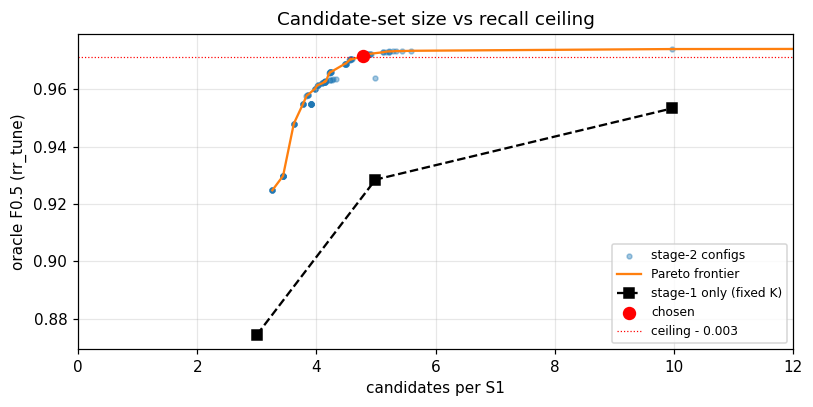

16105

In [28]:
# ---- Choose the adaptive stage-2 cut-off on rr_tune (PS: smaller candidate sets rank higher) ----
GRID_PATH = MODEL_DIR / 'stage2_cutoff_grid.csv'
cv = fast_features(stage1_for('train', SPLITS['rr_tune']['i1']), S1F_TR, RF_TR, RS_TR)
cv = cv.with_columns(p_rr=pl.Series(RR.predict_proba(cv.select(RR_FEATS).fill_nan(0).fill_null(0).to_numpy())[:, 1].astype(np.float32)))
cv = cv.with_columns(rr_rank=pl.col('p_rr').rank('ordinal', descending=True).over('i1'), p_max=pl.col('p_rr').max().over('i1'))
TUNE_I = SPLITS['rr_tune']['i1']
TRUTH_TUNE_I = TRUTH_TR_I.join(SPLITS['rr_tune'].select('i1'), on='i1', how='semi')
def stage2_keep(d, kmax, floor, alpha):
    """Adaptive per-S1 candidate list: at most kmax, absolute floor on p, and p >= alpha * best p of that S1."""
    return d.filter((pl.col('rr_rank') <= kmax) & (pl.col('p_rr') >= floor) & (pl.col('p_rr') >= alpha * pl.col('p_max')))
base_or = candidate_report(as_eval(cv), as_eval(TRUTH_TUNE_I), TUNE_I, f'stage1 top-{K1} (input to stage 2)')
grid = [{**base_or, 'kmax': K1, 'floor': 0.0, 'alpha': 0.0}]
for kmax in ([] if GRID_PATH.exists() else [5, 10, 20]):
    for fl in [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5]:
        for al in [0.0, 0.02, 0.05, 0.1, 0.2]:
            grid.append({**candidate_report(as_eval(stage2_keep(cv, kmax, fl, al)), as_eval(TRUTH_TUNE_I), TUNE_I, f'stage2 kmax={kmax} p>={fl} p>={al}*pmax'),
                         'kmax': kmax, 'floor': fl, 'alpha': al})
for k in ([] if GRID_PATH.exists() else [3, 5, 10]):   # stage-1 ranking alone at a fixed K, for comparison
    grid.append({**candidate_report(as_eval(cv.filter(pl.col('brank') <= k)), as_eval(TRUTH_TUNE_I), TUNE_I, f'stage1-only top-{k}'), 'kmax': k, 'floor': -1, 'alpha': -1})
G = pd.read_csv(GRID_PATH, index_col='stage') if GRID_PATH.exists() else pd.DataFrame(grid).set_index('stage')
G.to_csv(GRID_PATH)
# Selection rule: the SMALLEST candidate set whose oracle F0.5 is within TOL of the stage-1 ceiling.
TOL = 0.003
s2 = G[G.index.str.startswith('stage2')]
ok = s2[s2['oracle F0.5'] >= base_or['oracle F0.5'] - TOL]
best = ok.sort_values(['cand / S1', 'oracle F0.5'], ascending=[True, False]).iloc[0] if len(ok) else s2.sort_values('oracle F0.5').iloc[-1]
KMAX, FLOOR, ALPHA = int(best.kmax), float(best.floor), float(best.alpha)
# Pareto frontier (no other config is both smaller and higher-ceiling) for the report
front = s2.sort_values('cand / S1'); front = front[front['oracle F0.5'] >= front['oracle F0.5'].cummax()]
display(front[['cand / S1', 'pair recall', 'pair precision', 'oracle F0.5']].head(25))
display(G[G.floor == -1][['cand / S1', 'pair recall', 'pair precision', 'oracle F0.5']])
print(f'ceiling (stage-1 top-{K1}): {base_or["cand / S1"]} cand/S1, oracle F0.5 {base_or["oracle F0.5"]}')
print(f'CHOSEN: kmax={KMAX}, floor={FLOOR}, alpha={ALPHA} -> {best["cand / S1"]} cand/S1 '
      f'(true matches per S1 = {TRUTH_TUNE_I.height / TUNE_I.len():.2f}), pair recall {best["pair recall"]}, oracle F0.5 {best["oracle F0.5"]}')
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.scatter(s2['cand / S1'], s2['oracle F0.5'], s=10, alpha=.4, label='stage-2 configs')
ax.plot(front['cand / S1'], front['oracle F0.5'], 'C1-', label='Pareto frontier')
g = G[G.floor == -1]; ax.plot(g['cand / S1'], g['oracle F0.5'], 'ks--', label='stage-1 only (fixed K)')
ax.scatter([best['cand / S1']], [best['oracle F0.5']], c='red', s=60, zorder=5, label='chosen')
ax.axhline(base_or['oracle F0.5'] - TOL, color='r', lw=.8, ls=':', label=f'ceiling - {TOL}')
ax.set_xlabel('candidates per S1'); ax.set_ylabel('oracle F0.5 (rr_tune)'); ax.set_xlim(0, 12)
ax.legend(fontsize=8); ax.set_title('Candidate-set size vs recall ceiling'); plt.tight_layout(); plt.show()
# persist the re-ranker and the blocking configuration (part of the reproducible pipeline)
BLOCK_CFG = {'CAP': CAP, 'K1': K1, 'KEY_FAMILIES': KEY_FAMILIES, 'KMAX': KMAX, 'FLOOR': FLOOR, 'ALPHA': ALPHA, 'TOL': TOL,
             'RR_FEATS': RR_FEATS, 'tune_oracle_f05': float(best['oracle F0.5']), 'tune_cand_per_s1': float(best['cand / S1'])}
json.dump(BLOCK_CFG, open(MODEL_DIR / 'blocking_config.json', 'w'), indent=1)
backup('models')
del cv; gc.collect()

# Step 6: Train / validation split (leakage-safe)

All subsets are **disjoint sets of S1 entities**, drawn one after another from the same pool by a stratified sampler. The two re-ranker subsets were drawn in Step 5.3; this step draws the rest.

* **Unit = S1 entity (its whole match group).** Each S2/S3 record belongs to at most one S1 group (§2.1: zero ids appear in two groups), so splitting by S1 is automatically **group-aware**. No record is ever a positive in two splits.
* **Stratified by country × group-size bucket** (0 = singleton, 1, 2, 3, 4, 5, 6+). Singletons are worth a full point each and are rare (~5–6 %), and the per-country difficulty differs, so every split must keep both proportions.
* **Disjoint S1 subsets, one per learned component**, so that no component is scored on data it was trained on:
  * `rr_train` / `rr_tune`: fit / tune the stage-2 blocking re-ranker (Step 5.3)
  * `ce_train`: fine-tunes the transformer matcher
  * `stack_train`: trains the stacking/decision layer on *out-of-sample* transformer scores
  * `val`: touched only for final evaluation and the results table (all thresholds are tuned on `stack_train` out-of-fold predictions)
* Blocking (stage 1) is unsupervised and runs over **all** train S1 and all S2/S3 records. So val candidates face exactly the same distractors as test candidates, including records that belong to other (train) S1 entities. Those are hard negatives, not leakage: no labels are involved.

In [29]:
take_stratified('val', 100_000); take_stratified('ce_train', 200_000); take_stratified('stack_train', 150_000)
ids = [set(v['s1'].to_list()) for v in SPLITS.values()]
assert all(not (a & b) for i, a in enumerate(ids) for b in ids[i + 1:]), 'splits overlap'
summ = []
for name, v in SPLITS.items():
    m = META.join(v.select('s1'), on='s1')
    summ.append({'split': name, 'S1': m.height, 'true pairs': int(m['n'].sum()), 'singleton %': round(100 * (m['n'] == 0).mean(), 2),
                 'mean matches': round(m['n'].mean(), 3), **{f'{c} %': round(100 * (m['country'] == c).mean(), 2) for c in sorted(META['country'].unique())}})
display(pd.DataFrame(summ).set_index('split'))
for name, v in SPLITS.items():
    v.write_parquet(OUT / f'split_{name}.parquet')
VAL_I = SPLITS['val']['i1']
TRUTH_VAL_I = TRUTH_TR_I.join(SPLITS['val'].select('i1'), on='i1', how='semi')
print('S1 left unused:', len(POOL)); del POOL; gc.collect()

,S1,true pairs,singleton %,mean matches,India %,US %
split,,,,,,
rr_train,100000,346199,5.58,3.462,40.02,59.98
rr_tune,100000,346098,5.58,3.461,40.02,59.98
val,100000,346142,5.58,3.461,40.02,59.98
ce_train,200000,692246,5.58,3.461,40.02,59.98
stack_train,150000,519318,5.58,3.462,40.02,59.98


S1 left unused: 1556821


0

## 6.1 Final candidate sets for every split (stage-2 blocking)
Stage 2 from Step 5.3 is applied to `ce_train`, `stack_train` and `val`, and to **all test S1**. The blocking summary is then reported on `val`, which no blocking component has seen.

In [30]:
# ---- Materialise stage-2 candidate sets (train subsets + all test), with fast features ----
STAGE2_VERSION = f'{BLOCK_VERSION}_km{KMAX}_f{FLOOR}_a{ALPHA}'
def stage2_path(split, name): return BLK_DIR / f'{split}_{name}_stage2_{STAGE2_VERSION}.parquet'

def run_stage2(split, i1_all, name, s1f, rf, rs, chunk=150_000):
    p = stage2_path(split, name)
    if p.exists():
        print(p.name, 'cached'); return
    outs, t = [], time.time()
    i1_all = np.asarray(i1_all)
    for k in range(0, len(i1_all), chunk):
        f = fast_features(stage1_for(split, i1_all[k:k + chunk]), s1f, rf, rs)
        f = f.with_columns(p_rr=pl.Series(RR.predict_proba(f.select(RR_FEATS).fill_nan(0).fill_null(0).to_numpy())[:, 1].astype(np.float32)))
        f = f.with_columns(rr_rank=pl.col('p_rr').rank('ordinal', descending=True).over('i1').cast(pl.UInt16),
                           p_max=pl.col('p_rr').max().over('i1'))
        outs.append(stage2_keep(f, KMAX, FLOOR, ALPHA)); del f; gc.collect()
    out = pl.concat(outs); out.write_parquet(p)
    print(f'{p.name}: {out.height:,} pairs for {len(i1_all):,} S1 in {(time.time()-t)/60:.1f} min')

for name in ['ce_train', 'stack_train', 'val']:
    run_stage2('train', SPLITS[name]['i1'].to_numpy(), name, S1F_TR, RF_TR, RS_TR)
del S1F_TR, RF_TR, RS_TR; gc.collect()
S1F_TE, RF_TE, RS_TE = side_tables('test')
run_stage2('test', np.arange(S1F_TE.height, dtype=np.uint32), 'all', S1F_TE, RF_TE, RS_TE)
del S1F_TE, RF_TE, RS_TE; gc.collect()
backup('blocking')
print(elapsed())

train_ce_train_stage2_b1_km10_f0.05_a0.0.parquet: 956,609 pairs for 200,000 S1 in 0.3 min
train_stack_train_stage2_b1_km10_f0.05_a0.0.parquet: 717,992 pairs for 150,000 S1 in 0.2 min
train_val_stage2_b1_km10_f0.05_a0.0.parquet: 478,521 pairs for 100,000 S1 in 0.2 min
test_all_stage2_b1_km10_f0.05_a0.0.parquet: 10,062,729 pairs for 1,732,544 S1 in 2.7 min
17.7 min


,S1,candidates,cand / S1,pair recall,pair precision,oracle F0.5,reduction ratio
stage,,,,,,,
stage 1: key blocking top-50,100000,4887535,48.88,0.9356,0.0663,0.9740,0.999991
"stage 2: LR re-rank, adaptive (kmax=10, p>=0.05, p>=0.0*pmax)",100000,478521,4.79,0.9289,0.6719,0.9715,0.999999


val: true matches per S1 = 3.46; final candidates per S1 = 4.79
candidates per S1, val:


,S1,total candidates,mean,median,p90,max,0 cand %,1 cand %,<=3 cand %
group,,,,,,,,,
all,100000,478521,4.785,5.0,7.0,10,0.45,2.57,27.00
India,40021,196393,4.907,5.0,8.0,10,0.39,2.40,25.71
US,59979,282128,4.704,5.0,7.0,10,0.50,2.68,27.86


candidates per S1, TEST (this is candidate_pairs.tsv):


,S1,total candidates,mean,median,p90,max,0 cand %,1 cand %,<=3 cand %
group,,,,,,,,,
all,1732544,10062729,5.808,6.0,9.0,10,0.37,1.47,14.39
France,259452,1740034,6.707,7.0,10.0,10,0.89,1.15,10.74
India,809986,4662811,5.757,6.0,9.0,10,0.26,1.55,14.89
US,663106,3659884,5.519,5.0,8.0,10,0.29,1.51,15.22


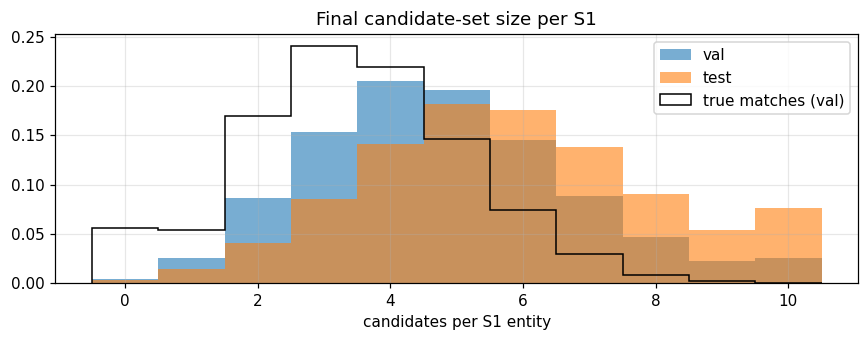

3675

In [31]:
# ---- Blocking summary: every stage, on val (train) ----
v2 = pl.read_parquet(stage2_path('train', 'val'))
c1v = stage1_for('train', VAL_I)
n_r_by_c = {c: nt('train', '2', ['country']).filter(pl.col('country') == c).height + nt('train', '3', ['country']).filter(pl.col('country') == c).height
            for c in S1_TR_META['country'].unique().to_list()}
val_c = S1_TR_META.join(SPLITS['val'].select('i1'), on='i1', how='semi')['country'].value_counts()
full_space = sum(r['count'] * n_r_by_c[r['country']] for r in val_c.to_dicts())
rows = [candidate_report(as_eval(c1v.filter(pl.col('brank') <= K1)), as_eval(TRUTH_VAL_I), VAL_I, f'stage 1: key blocking top-{K1}'),
        candidate_report(as_eval(v2), as_eval(TRUTH_VAL_I), VAL_I, f'stage 2: LR re-rank, adaptive (kmax={KMAX}, p>={FLOOR}, p>={ALPHA}*pmax)')]
BLOCK_SUMMARY = pd.DataFrame(rows).set_index('stage')
BLOCK_SUMMARY['reduction ratio'] = [1 - r['candidates'] / full_space for r in rows]
display(BLOCK_SUMMARY)
print(f'val: true matches per S1 = {TRUTH_VAL_I.height / VAL_I.len():.2f}; final candidates per S1 = {v2.height / VAL_I.len():.2f}')

# candidate-set size distribution (what the organisers audit): val and test, every S1 counted (0 if no candidate)
te2 = pl.read_parquet(stage2_path('test', 'all'), columns=['i1'])
M1_TE_META = nt('test', '1', ['entity_id', 'country']).with_row_index('i1')
def size_dist(c2, meta):
    n = meta.select('i1', 'country').join(c2.group_by('i1').len('n'), on='i1', how='left').with_columns(pl.col('n').fill_null(0))
    rows_ = []
    for key, g in [('all', n)] + [(c, n.filter(pl.col('country') == c)) for c in sorted(n['country'].unique().to_list())]:
        v = g['n']
        rows_.append({'group': key, 'S1': g.height, 'total candidates': int(v.sum()), 'mean': round(v.mean(), 3), 'median': v.median(),
                      'p90': v.quantile(.9), 'max': v.max(), '0 cand %': round(100 * (v == 0).mean(), 2), '1 cand %': round(100 * (v == 1).mean(), 2),
                      '<=3 cand %': round(100 * (v <= 3).mean(), 2)})
    return pd.DataFrame(rows_).set_index('group'), n['n'].to_numpy()
val_meta = S1_TR_META.join(SPLITS['val'].select('i1'), on='i1', how='semi')
d_val, nv = size_dist(v2, val_meta); d_te, nte = size_dist(te2, M1_TE_META)
print('candidates per S1, val:'); display(d_val)
print('candidates per S1, TEST (this is candidate_pairs.tsv):'); display(d_te)
fig, ax = plt.subplots(figsize=(8, 3.2))
b = np.arange(0, max(nv.max(), nte.max()) + 2) - .5
ax.hist(nv, bins=b, density=True, alpha=.6, label='val'); ax.hist(nte, bins=b, density=True, alpha=.6, label='test')
tv = sizes.join(SPLITS['val'].select(pl.col('s1').alias('source1_entity_id')), on='source1_entity_id', how='semi')['n'].to_numpy()
ax.hist(tv, bins=b, density=True, histtype='step', color='k', label='true matches (val)')
ax.set_xlabel('candidates per S1 entity'); ax.set_title('Final candidate-set size per S1'); ax.legend(); plt.tight_layout(); plt.show()
BLOCK_SUMMARY.to_csv(OUT / 'blocking_summary_val.csv'); d_te.to_csv(OUT / 'candidate_size_test.csv')
del v2, c1v, te2; gc.collect()

## 6.2 Features for every candidate set (Step 4 definitions)

In [32]:
# ---- Compute + cache features for every candidate set ----
FEAT_VERSION = f'{STAGE2_VERSION}_f1'
def feat_path(split, name): return OUT / 'features' / f'{split}_{name}_{FEAT_VERSION}.parquet'
(OUT / 'features').mkdir(exist_ok=True)
def build_features(split, name, s1, r, chunk_s1=250_000):
    p = feat_path(split, name)
    if p.exists():
        print(p.name, 'cached'); return
    c2 = pl.read_parquet(stage2_path(split, name)); u = c2['i1'].unique().sort().to_numpy(); outs = []; t = time.time()
    for k in range(0, len(u), chunk_s1):
        outs.append(full_features(c2.join(pl.DataFrame({'i1': u[k:k + chunk_s1]}), on='i1', how='semi'), s1, r)); gc.collect()
    f = pl.concat(outs)
    if split == 'train':
        f = f.join(TRUTH_TR_I.with_columns(pl.lit(1, dtype=pl.Int8).alias('y')), on=['i1', 'ir'], how='left').with_columns(pl.col('y').fill_null(0))
    f.write_parquet(p); print(f'{p.name}: {f.shape} in {(time.time()-t)/60:.1f} min')
    backup('features')

S1X, RX = side_full('train')
for name in ['ce_train', 'stack_train', 'val']:
    build_features('train', name, S1X, RX)
del S1X, RX; gc.collect()
S1X, RX = side_full('test')
build_features('test', 'all', S1X, RX)
del S1X, RX; gc.collect()
F_STACK = pl.read_parquet(feat_path('train', 'stack_train'))
print('stack_train:', F_STACK.shape, '| positive rate %.3f' % F_STACK['y'].mean())
desc = F_STACK.select(FEATS + ['y']).to_pandas()
display(desc.groupby('y')[FEATS].mean().T.round(3).rename(columns={0: 'mean | non-match', 1: 'mean | match'}).head(70))

train_ce_train_b1_km10_f0.05_a0.0_f1.parquet: (956609, 72) in 1.5 min
train_stack_train_b1_km10_f0.05_a0.0_f1.parquet: (717992, 72) in 1.1 min
train_val_b1_km10_f0.05_a0.0_f1.parquet: (478521, 72) in 0.7 min
test_all_b1_km10_f0.05_a0.0_f1.parquet: (10062729, 71) in 15.3 min
stack_train: (717992, 72) | positive rate 0.671


y,mean | non-match,mean | match
bscore,3.751,4.202
bkeys,4.173,6.103
brank,10.684,3.814
b_rel,0.574,0.799
s_n,49.280,48.949
...,...,...
has_a2,0.789,0.966
aindic1,0.000,0.000
aindic2,0.069,0.088
p_rel,0.455,0.862


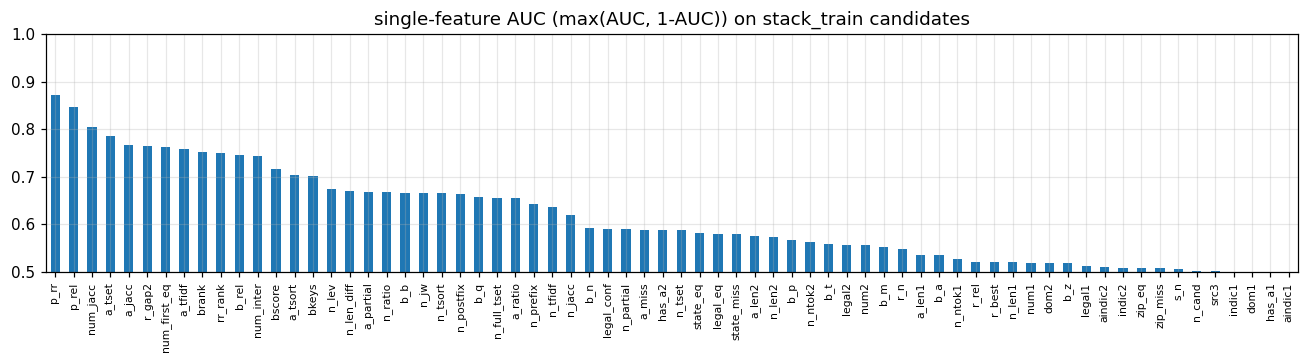

4362

In [33]:
# [eda-only] analysis cell, not part of src/pipeline.py
# ---- Single-feature separability (AUC on stack_train) : which signals matter ----
aucs = {}
for f_ in FEATS:
    v = desc[f_].astype(float).fillna(-1).values
    try: aucs[f_] = roc_auc_score(desc['y'], v)
    except ValueError: pass
aucs = pd.Series(aucs); aucs = aucs.where(aucs >= .5, 1 - aucs).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 3.4)); aucs.plot.bar(ax=ax); ax.set_ylim(.5, 1); ax.set_title('single-feature AUC (max(AUC, 1-AUC)) on stack_train candidates')
plt.xticks(fontsize=7); plt.tight_layout(); plt.show()
del desc; gc.collect()

# Step 7: Model research and fine-tuning

## 7.1 Which model family? (MIT/Apache-2.0, ≤ 8B parameters, must fit this Colab GPU)

The matcher must score about **14M test pairs** (≈ 8 per S1 after blocking), plus training data, within hours on one GPU. The data is multilingual: English, French, transliterated Hindi, and native Devanagari/Bengali/Odia names on the S2/S3 side.

| family | examples (licence) | params | strengths | weaknesses here | est. throughput on a T4-class GPU | verdict |
|---|---|---|---|---|---|---|
| Bi-encoder (embed each record, cosine) | multilingual-e5-small (MIT), bge-small-en-v1.5 (MIT) | 33–118M | Encodes each record once and enables ANN retrieval | Pair decisions are coarse: no token-level interaction, so a single-digit house-number change or typo is poorly separated | ~10k records/s | useful for retrieval, weaker as matcher |
| **Cross-encoder** (both records in one sequence) | **multilingual-e5-small** (MIT), ms-marco-MiniLM-L6 (Apache), bge-reranker-base (MIT) | 22–278M | Full cross-attention between the two records, so it sees exact token/number alignments. The standard strongest pairwise matcher at small size (Ditto-style ER) | Cost ∝ #pairs, so it needs precise blocking. We have that (≈ 8 pairs/S1) | e5-small: ~3–5k pairs/s fp16 inference | **chosen** |
| DeBERTa-v3 classifier | deberta-v3-small/base (MIT), mdeberta-v3-base (MIT) | 70–280M | Excellent English NLU | English vocab cannot read Devanagari/Bengali; mDeBERTa-base is ~3× slower than e5-small; fp16 overflow quirks | 1–1.5k pairs/s (base) | too slow for 14M pairs |
| Small LLM + LoRA/QLoRA | Qwen2.5-0.5B/1.5B (Apache), Phi-3-mini (MIT) | 0.5–3.8B | World knowledge (abbreviations, transliteration) | 10–50× slower per pair: 14M pairs at ~300/s ≈ 13 h for 1.5B, far beyond the budget; QLoRA training is also slow | 100–500 pairs/s | infeasible at this volume |
| Gradient boosting on similarity features | LightGBM (MIT) | – | Fast; very strong on engineered ER features; natural for stacking | Only as good as its features | millions/s | **secondary stacking layer only** |

**Decision.** Fine-tune **`intfloat/multilingual-e5-small`** (MIT, 118M parameters: 12 layers, 384 hidden units, 250k-token multilingual SentencePiece vocabulary) as a **cross-encoder** with a single-logit head:
* It is multilingual, so native-script names are tokenised meaningfully rather than as unknown bytes.
* Its contrastive pre-training on text pairs gives a good similarity initialisation.
* It is small enough to score all test candidates on a single GPU.

Its logit then feeds a LightGBM **stacker**, together with the engineered features. The stacker is trained on held-out (`stack_train`) scores only, so no in-sample leakage.

**Training recipe** (scaled to the reported GPU):
* Mixed precision: bf16 only on GPUs with *native* bf16 (compute capability ≥ 8.0). On a **T4 (CC 7.5), fp16 with a GradScaler** is used, because torch reports bf16 as "supported" on a T4 but emulates it several times slower. On an A100, native bf16 is used.
* Gradient accumulation to an effective batch of 256.
* Gradient checkpointing only when VRAM < 10 GB. A 118M model at 96 tokens fits a 15 GB T4 without it, and checkpointing would cost ~30 % speed.
* AdamW, linear warm-up/decay, 1 epoch over `ce_train` stage-2 candidates.
* Those candidates are *already hard negatives*: they survived IDF blocking and the learned re-rank. **Hard-negative mining is intrinsic to the pipeline.**
* Input: `name | address` of the S1 record vs the candidate. We use the **raw, original-script text**, so the transformer sees information complementary to the normalised-string features.

In [34]:
import torch, torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

CE_NAME = 'intfloat/multilingual-e5-small'
CE_TAG = 'ce_e5s_v1'
CE_DIR = OUT / CE_TAG; CE_DIR.mkdir(exist_ok=True)
MAX_LEN = 96
assert HAS_GPU, 'The cross-encoder stage needs a GPU runtime (Runtime > Change runtime type > GPU).'
DEV = 'cuda'
USE_BF16 = HAS_GPU and NATIVE_BF16          # never emulated bf16 (T4 -> fp16)
AMP_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16
MICRO_BS = 256 if GPU_MEM_GB >= 30 else (128 if GPU_MEM_GB >= 14 else 64)
ACC = max(1, 256 // MICRO_BS)
INFER_BS = 2048 if GPU_MEM_GB >= 30 else 768
# cap on training pairs so fine-tuning fits the budget on slower GPUs (A100/H100/L4 can take more)
MAX_TRAIN_PAIRS = 3_000_000 if GPU_MEM_GB >= 30 else 1_500_000
print(f'device={DEV} amp={AMP_DTYPE} micro_bs={MICRO_BS} acc={ACC} infer_bs={INFER_BS} max_train_pairs={MAX_TRAIN_PAIRS:,}')

TXT_COLS = ['name', 'addr']
def pair_texts(c: pl.DataFrame, split: str):
    """Raw text of both sides for candidate rows c (i1, ir), in c's row order."""
    s1 = nt(split, '1', TXT_COLS).with_row_index('i1'); r = pl.concat([nt(split, s, TXT_COLS) for s in '23']).with_row_index('ir')
    d = c.select('i1', 'ir').with_row_index('_o').join(s1, on='i1').join(r, on='ir', suffix='_r').sort('_o')
    fmt = lambda n, a: pl.when(a.is_null() | (a == '')).then(n).otherwise(pl.concat_str([n, pl.lit(' | '), a]))
    d = d.select(fmt(pl.col('name'), pl.col('addr')).alias('ta'), fmt(pl.col('name_r'), pl.col('addr_r')).alias('tb'))
    return d['ta'].to_list(), d['tb'].to_list()

TOK = AutoTokenizer.from_pretrained(CE_NAME)
enc = TOK('Vision Systems | 104 Star Lite Aptd-4 Sector-14 Extn Rohini, New Delhi', 'विजन सिस्टम्स | DOOR NO 104 STAR LITE AFTD-4 SECTOR-14 EXTN ROHINI')
print(len(enc['input_ids']), 'tokens:', TOK.convert_ids_to_tokens(enc['input_ids'])[:40])

device=cuda amp=torch.bfloat16 micro_bs=256 acc=1 infer_bs=2048 max_train_pairs=3,000,000


config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

49 tokens: ['<s>', '▁Vision', '▁Systems', '▁', '|', '▁104', '▁Star', '▁Lite', '▁Ap', 't', 'd', '-4', '▁Sector', '-14', '▁Ex', 't', 'n', '▁Roh', 'ini', ',', '▁New', '▁Delhi', '</s>', '</s>', '▁वि', 'जन', '▁सिस्टम', '्स', '▁', '|', '▁D', 'OOR', '▁NO', '▁104', '▁STAR', '▁', 'LITE', '▁AF', 'TD', '-4']


training pairs 956,609  positive rate 0.672


model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

step      0/3737  loss 0.6857  258 pairs/s  eta 61.7 min
step    200/3737  loss 0.5043  2,612 pairs/s  eta 5.8 min
step    400/3737  loss 0.1681  2,668 pairs/s  eta 5.3 min
step    600/3737  loss 0.1189  2,689 pairs/s  eta 5.0 min
step    800/3737  loss 0.1020  2,701 pairs/s  eta 4.6 min
step   1000/3737  loss 0.0928  2,707 pairs/s  eta 4.3 min
step   1200/3737  loss 0.0828  2,713 pairs/s  eta 4.0 min
step   1400/3737  loss 0.0824  2,710 pairs/s  eta 3.7 min
step   1600/3737  loss 0.0752  2,714 pairs/s  eta 3.4 min
step   1800/3737  loss 0.0744  2,711 pairs/s  eta 3.0 min
step   2000/3737  loss 0.0726  2,713 pairs/s  eta 2.7 min
step   2200/3737  loss 0.0676  2,715 pairs/s  eta 2.4 min
step   2400/3737  loss 0.0652  2,712 pairs/s  eta 2.1 min
step   2600/3737  loss 0.0649  2,714 pairs/s  eta 1.8 min
step   2800/3737  loss 0.0618  2,712 pairs/s  eta 1.5 min
step   3000/3737  loss 0.0625  2,714 pairs/s  eta 1.2 min
step   3200/3737  loss 0.0597  2,715 pairs/s  eta 0.8 min
step   3400/373

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

CE trained on 956,609 pairs in 5.9 min | files: ['checkpoint', 'config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'train_log.json']


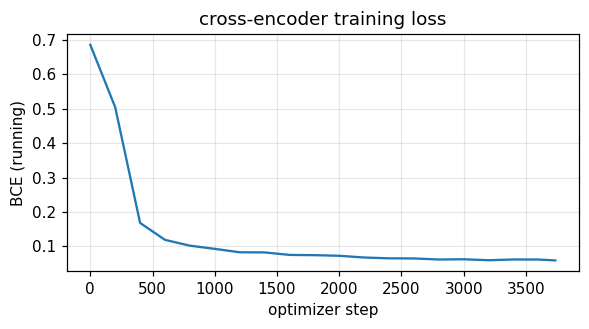

In [35]:
# ---- Fine-tune with periodic checkpoints + automatic resume (skipped entirely once the final model exists) ----
CKPT_DIR = CE_DIR / 'checkpoint'; CKPT_DIR.mkdir(exist_ok=True)
CKPT = CKPT_DIR / 'last.pt'                                   # latest training state (model + optimizer + scheduler + scaler + step)
CKPT_MINUTES = float(os.environ.get('ER_CKPT_MINUTES', 10))   # save a checkpoint at least this often

def save_ckpt(state):
    tmp = CKPT.with_suffix('.tmp'); torch.save(state, tmp); tmp.replace(CKPT)   # atomic: a crash never leaves a broken checkpoint
    json.dump({k: state[k] for k in ['step', 'n_steps', 'n_pairs', 'elapsed_min']}, open(CKPT_DIR / 'last.json', 'w'))
    backup(CE_TAG)

def train_ce():
    tr = pl.read_parquet(feat_path('train', 'ce_train'), columns=['i1', 'ir', 'y'])
    if tr.height > MAX_TRAIN_PAIRS:
        keep = tr.select('i1').unique().sort('i1').sample(fraction=MAX_TRAIN_PAIRS / tr.height, seed=SEED)
        tr = tr.join(keep, on='i1', how='semi')
    tr = tr.sort(['i1', 'ir'])                                  # deterministic order, so a resumed run sees the same batches
    ta, tb = pair_texts(tr, 'train'); y = tr['y'].to_numpy().astype(np.float32)
    print(f'training pairs {len(y):,}  positive rate {y.mean():.3f}')
    model = AutoModelForSequenceClassification.from_pretrained(CE_NAME, num_labels=1).to(DEV)
    if GPU_MEM_GB < 10: model.gradient_checkpointing_enable()
    opt = torch.optim.AdamW(model.parameters(), lr=4e-5, weight_decay=0.01)
    n_steps = math.ceil(len(y) / (MICRO_BS * ACC))
    sch = get_linear_schedule_with_warmup(opt, int(0.06 * n_steps), n_steps)
    scaler = torch.cuda.amp.GradScaler(enabled=not USE_BF16)
    order = np.random.default_rng(SEED).permutation(len(y))
    start, hist, prev_min = 0, [], 0.0
    if CKPT.exists():
        st = torch.load(CKPT, map_location=DEV, weights_only=False)
        if st['n_pairs'] == len(y) and st['n_steps'] == n_steps:
            model.load_state_dict(st['model']); opt.load_state_dict(st['opt']); sch.load_state_dict(st['sch']); scaler.load_state_dict(st['scaler'])
            start, hist, prev_min = st['step'], st['hist'], st['elapsed_min']
            print(f'RESUMING from checkpoint: step {start}/{n_steps} ({prev_min:.1f} min already trained)')
        else:
            print('checkpoint belongs to a different training set -> starting fresh')
    model.train(); t = time.time(); last_ck = time.time(); run_loss = []
    state = lambda step: {'model': model.state_dict(), 'opt': opt.state_dict(), 'sch': sch.state_dict(), 'scaler': scaler.state_dict(),
                          'step': step, 'n_steps': n_steps, 'n_pairs': len(y), 'hist': hist, 'elapsed_min': prev_min + (time.time() - t) / 60}
    for step in range(start, n_steps):
        for a in range(ACC):
            idx = order[(step * ACC + a) * MICRO_BS:(step * ACC + a + 1) * MICRO_BS]
            if len(idx) == 0: continue
            b = TOK([ta[i] for i in idx], [tb[i] for i in idx], truncation=True, max_length=MAX_LEN, padding=True, return_tensors='pt').to(DEV)
            with torch.autocast('cuda', dtype=AMP_DTYPE):
                logit = model(**b).logits.squeeze(-1)
            loss = F.binary_cross_entropy_with_logits(logit.float(), torch.from_numpy(y[idx]).to(DEV)) / ACC
            scaler.scale(loss).backward(); run_loss.append(loss.item() * ACC)
        scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True); sch.step()
        if step % 200 == 0 or step == n_steps - 1:
            el = time.time() - t; done = step + 1 - start; hist.append((step, float(np.mean(run_loss[-200 * ACC:]))))
            print(f'step {step:6d}/{n_steps}  loss {hist[-1][1]:.4f}  {done * MICRO_BS * ACC / el:,.0f} pairs/s  '
                  f'eta {(n_steps - step - 1) * el / done / 60:.1f} min', flush=True)
        if time.time() - last_ck > CKPT_MINUTES * 60:
            save_ckpt(state(step + 1)); last_ck = time.time(); print(f'  [checkpoint] step {step + 1} saved -> {CKPT}', flush=True)
    save_ckpt(state(n_steps))                                    # final training state is kept as the last checkpoint
    model.save_pretrained(CE_DIR); TOK.save_pretrained(CE_DIR)   # final model (Hugging Face format); config.json marks "done"
    json.dump({'hist': hist, 'pairs': len(y), 'minutes': prev_min + (time.time() - t) / 60}, open(CE_DIR / 'train_log.json', 'w'))
    del model, opt; torch.cuda.empty_cache()

if not (CE_DIR / 'config.json').exists():
    train_ce()
else:
    print('fine-tuned cross-encoder found -> loading, no training')
backup(CE_TAG)
CE_LOG = json.load(open(CE_DIR / 'train_log.json'))
print(f"CE trained on {CE_LOG['pairs']:,} pairs in {CE_LOG['minutes']:.1f} min | files:", sorted(p.name for p in CE_DIR.iterdir()))
h = np.array(CE_LOG['hist']); plt.figure(figsize=(6, 2.8)); plt.plot(h[:, 0], h[:, 1]); plt.xlabel('optimizer step'); plt.ylabel('BCE (running)'); plt.title('cross-encoder training loss'); plt.show()

In [36]:
# ---- Score candidate sets with the fine-tuned cross-encoder (chunked + cached, length-sorted batches) ----
CE_MODEL = AutoModelForSequenceClassification.from_pretrained(CE_DIR).to(DEV).eval()
if HAS_GPU: CE_MODEL = CE_MODEL.to(AMP_DTYPE)
@torch.no_grad()
def ce_score(ta, tb):
    lens = np.array([len(a) + len(b) for a, b in zip(ta, tb)]); order = np.argsort(lens); out = np.empty(len(ta), np.float32)
    for k in range(0, len(ta), INFER_BS):
        idx = order[k:k + INFER_BS]
        b = TOK([ta[i] for i in idx], [tb[i] for i in idx], truncation=True, max_length=MAX_LEN, padding=True, return_tensors='pt').to(DEV)
        out[idx] = CE_MODEL(**b).logits.squeeze(-1).float().cpu().numpy()
    return out

def ce_path(split, name): return OUT / 'ce_scores' / f'{split}_{name}_{CE_TAG}_{FEAT_VERSION}'
def score_set(split, name, chunk=1_000_000):
    d = ce_path(split, name); d.mkdir(parents=True, exist_ok=True)
    c = pl.read_parquet(feat_path(split, name), columns=['i1', 'ir'])
    n_chunks = math.ceil(c.height / chunk)
    for k in range(n_chunks):
        p = d / f'part_{k:04d}.parquet'
        if p.exists(): continue
        t = time.time(); sub = c.slice(k * chunk, chunk); ta, tb = pair_texts(sub, split)
        sub.with_columns(ce=pl.Series(ce_score(ta, tb))).write_parquet(p)
        print(f'  {split}/{name} chunk {k + 1}/{n_chunks}: {sub.height / (time.time() - t):,.0f} pairs/s  ({(time.time()-t)/60:.1f} min)')
    backup('ce_scores')
    return pl.read_parquet(d / 'part_*.parquet')

CE_S = {}
for split, name in [('train', 'stack_train'), ('train', 'val'), ('test', 'all')]:
    CE_S[(split, name)] = score_set(split, name)
    print(split, name, CE_S[(split, name)].shape, elapsed())
del CE_MODEL; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  train/stack_train chunk 1/1: 7,883 pairs/s  (1.5 min)
train stack_train (717992, 3) 44.2 min
  train/val chunk 1/1: 7,796 pairs/s  (1.0 min)
train val (478521, 3) 45.3 min
  test/all chunk 1/11: 7,511 pairs/s  (2.2 min)
  test/all chunk 2/11: 7,498 pairs/s  (2.2 min)
  test/all chunk 3/11: 7,571 pairs/s  (2.2 min)
  test/all chunk 4/11: 7,487 pairs/s  (2.2 min)
  test/all chunk 5/11: 7,481 pairs/s  (2.2 min)
  test/all chunk 6/11: 7,583 pairs/s  (2.2 min)
  test/all chunk 7/11: 7,520 pairs/s  (2.2 min)
  test/all chunk 8/11: 7,469 pairs/s  (2.2 min)
  test/all chunk 9/11: 7,574 pairs/s  (2.2 min)
  test/all chunk 10/11: 7,541 pairs/s  (2.2 min)
  test/all chunk 11/11: 7,534 pairs/s  (0.1 min)
test all (10062729, 3) 67.5 min


## 7.2 From pair scores to per-entity match lists

Because the metric is a **per-S1 macro F<sub>0.5</sub>**, the final decision is made per entity, not per pair. Three rules are compared:

1. **Global threshold**: keep every candidate with p ≥ t.
2. **Exclusive assignment**: each S2/S3 record belongs to at most one S1 (verified in §2.1), so a record is only kept for the S1 that scores it highest. This removes a whole class of false merges.
3. **Expected-F<sub>0.5</sub> list selection.** For one S1 with sorted probabilities p<sub>1</sub> ≥ p<sub>2</sub> ≥ …, predicting the top *k* gives F<sub>0.5</sub> = 1.25·TP / (0.25·|true| + k). We plug in E[TP] = Σ<sub>i≤k</sub> p<sub>i</sub> and E[|true|] = Σ<sub>i</sub> p<sub>i</sub>. The empty list scores Π(1 − p<sub>i</sub>), the probability of a singleton. We pick the *k* (possibly 0) with the highest expected score. This handles singletons explicitly.

All thresholds and scaling constants are tuned on **out-of-fold predictions on `stack_train`**. `val` is used only to report the final numbers, so the results table is not overfit to the validation split.

In [37]:
TRUTH = {}  # evaluation truth per train subset (integer ids)
for name in ['stack_train', 'val']:
    TRUTH[name] = TRUTH_TR_I.join(SPLITS[name].select('i1'), on='i1', how='semi')

def exclusive(d: pl.DataFrame, p='p') -> pl.DataFrame:
    """keep a record only for the S1 that gives it the highest probability"""
    return d.filter(pl.col(p) >= pl.col(p).max().over('ir'))

def rule_threshold(d, t, p='p', excl=True):
    d = exclusive(d, p) if excl else d
    return d.filter(pl.col(p) >= t).select('i1', 'ir')

def rule_expected_f(d, p='p', excl=True, min_p=0.0):
    d = exclusive(d, p) if excl else d
    d = d.filter(pl.col(p) >= min_p).sort(['i1', p], descending=[False, True])
    d = d.with_columns(k=(pl.int_range(pl.len()).over('i1') + 1), cs=pl.col(p).cum_sum().over('i1'), et=pl.col(p).sum().over('i1'),
                       p0=(1 - pl.col(p)).log().sum().over('i1').exp())
    d = d.with_columns(ef=1.25 * pl.col('cs') / (0.25 * pl.col('et') + pl.col('k')))
    d = d.with_columns(best_k=pl.col('k').sort_by('ef', descending=True).first().over('i1'), best_ef=pl.col('ef').max().over('i1'))
    return d.filter((pl.col('best_ef') > pl.col('p0')) & (pl.col('k') <= pl.col('best_k'))).select('i1', 'ir')

def score(pred, name):
    return macro_f05(as_eval(pred), as_eval(TRUTH[name]), SPLITS[name]['i1'])

def tune_threshold(d, name, p='p', excl=True, grid=np.round(np.arange(0.05, 0.96, 0.025), 3)):
    res = [(t, score(rule_threshold(d, t, p, excl), name)) for t in grid]
    return max(res, key=lambda x: x[1]), res

RESULTS = []
def log_result(exp, model, params, val_score, notes=''):
    RESULTS.append({'#': len(RESULTS) + 1, 'experiment': exp, 'model': model, 'key params': params, 'val macro F0.5': round(val_score, 5), 'notes': notes})
    print(f'[{len(RESULTS)}] {exp}: val F0.5 = {val_score:.5f}')

F_STACK = pl.read_parquet(feat_path('train', 'stack_train')).join(CE_S[('train', 'stack_train')], on=['i1', 'ir'])
F_VAL = pl.read_parquet(feat_path('train', 'val')).join(CE_S[('train', 'val')], on=['i1', 'ir'])
print('stack_train', F_STACK.shape, '| val', F_VAL.shape)
print('oracle (perfect matcher on stage-2 candidates) val F0.5:', round(score(F_VAL.filter(pl.col('y') == 1), 'val'), 5))

stack_train (717992, 73) | val (478521, 73)
oracle (perfect matcher on stage-2 candidates) val F0.5: 0.97149


In [38]:
# [eda-only] analysis cell, not part of src/pipeline.py
# ---- Baselines: blocking re-ranker probability and cross-encoder alone ----
sig = lambda x: 1 / (1 + np.exp(-x))
for label, col, fn in [('stage-2 LR re-ranker prob', 'p_rr', lambda d: d.with_columns(p=pl.col('p_rr'))),
                       ('fine-tuned cross-encoder (e5-small)', 'ce', lambda d: d.with_columns(p=pl.Series(sig(d['ce'].to_numpy()))))]:
    ds, dv = fn(F_STACK), fn(F_VAL)
    for excl in [False, True]:
        (t, s_tr), _ = tune_threshold(ds, 'stack_train', excl=excl)
        log_result(f'{label}, threshold{" + exclusive" if excl else ""}', 'LR (blocking)' if col == 'p_rr' else f'{CE_NAME} cross-encoder',
                   f't={t} (tuned on stack_train)', score(rule_threshold(dv, t, excl=excl), 'val'))
    log_result(f'{label}, expected-F0.5 lists + exclusive', 'LR (blocking)' if col == 'p_rr' else f'{CE_NAME} cross-encoder', 'no tuning',
               score(rule_expected_f(dv), 'val'))

[1] stage-2 LR re-ranker prob, threshold: val F0.5 = 0.79339
[2] stage-2 LR re-ranker prob, threshold + exclusive: val F0.5 = 0.79343
[3] stage-2 LR re-ranker prob, expected-F0.5 lists + exclusive: val F0.5 = 0.80428
[4] fine-tuned cross-encoder (e5-small), threshold: val F0.5 = 0.95380
[5] fine-tuned cross-encoder (e5-small), threshold + exclusive: val F0.5 = 0.95399
[6] fine-tuned cross-encoder (e5-small), expected-F0.5 lists + exclusive: val F0.5 = 0.95340


## 7.3 Stacking: LightGBM over engineered features + cross-encoder logit

LightGBM is used only as the **second-level stacker**. It learns *when* to trust the transformer (for example, the cross-encoder is less reliable when one address is missing or the name is in a different script) and combines that with the numeric, attribute and competition evidence. The stacker is trained with **5-fold GroupKFold by S1 on `stack_train`**, whose cross-encoder scores are out-of-sample. The OOF predictions give honest tuning data for the decision rule. An ablation *without* the CE logit quantifies the transformer's contribution.

feats_only: best iterations per fold [1414, 1155, 1138, 1060, 1078]; OOF AUC 0.99706
[7] LightGBM on features (no transformer) [ablation], threshold + exclusive: val F0.5 = 0.95472
[8] LightGBM on features (no transformer) [ablation], expected-F0.5 lists + exclusive: val F0.5 = 0.95444
feats_ce: best iterations per fold [315, 374, 352, 272, 288]; OOF AUC 0.99914
[9] LightGBM stack: features + CE logit, threshold + exclusive: val F0.5 = 0.96310
[10] LightGBM stack: features + CE logit, expected-F0.5 lists + exclusive: val F0.5 = 0.96260


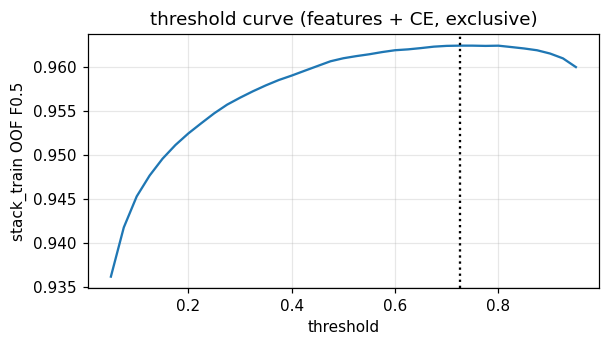

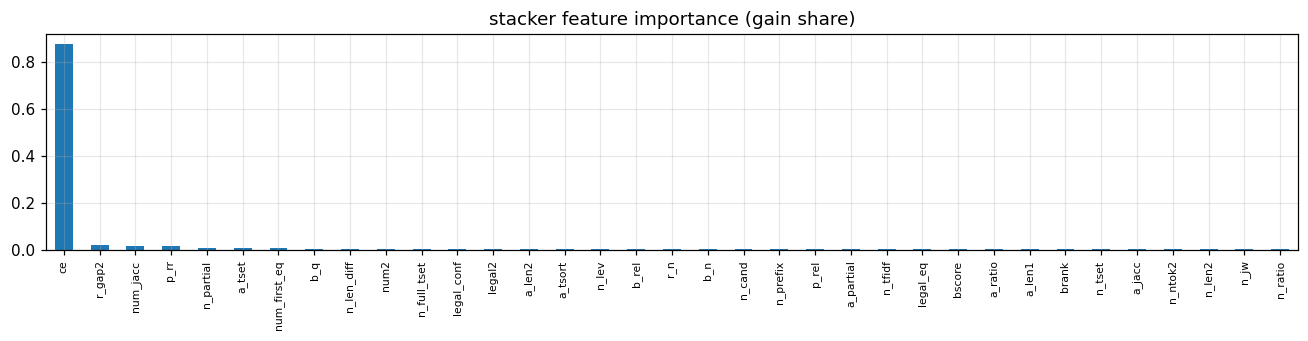

In [39]:
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
LGB_PARAMS = dict(objective='binary', learning_rate=0.05, num_leaves=127, min_data_in_leaf=200, feature_fraction=0.8, bagging_fraction=0.8,
                  bagging_freq=1, lambda_l2=1.0, verbose=-1, num_threads=os.cpu_count(), seed=SEED)
def fit_stack(df, feats, tag, rounds=3000):
    """5-fold GroupKFold (by S1) OOF predictions + a final model on all rows.
    Every fold is a checkpoint (model file + its OOF slice), so an interrupted run resumes at the next fold;
    a finished stacker is loaded from disk instead of being re-fitted."""
    ck = MODEL_DIR / f'lgb_{tag}_folds'; ck.mkdir(exist_ok=True)
    final_path, oof_path = MODEL_DIR / f'lgb_{tag}.txt', MODEL_DIR / f'lgb_{tag}_oof.npy'
    X = df.select(feats).to_numpy().astype(np.float32); y = df['y'].to_numpy(); g = df['i1'].to_numpy()
    if final_path.exists() and oof_path.exists() and len(np.load(oof_path)) == len(y):
        print(f'{tag}: loading saved stacker + OOF predictions'); oof = np.load(oof_path)
        return lgb.Booster(model_file=str(final_path)), oof
    oof = np.zeros(len(y), np.float32); iters = []
    for k, (a, b) in enumerate(GroupKFold(5).split(X, y, g)):
        mf, of = ck / f'fold{k}.txt', ck / f'fold{k}_oof.npy'
        if mf.exists() and of.exists():
            m = lgb.Booster(model_file=str(mf)); oof[b] = np.load(of); iters.append(m.current_iteration()); continue
        m = lgb.train(LGB_PARAMS, lgb.Dataset(X[a], y[a]), rounds, valid_sets=[lgb.Dataset(X[b], y[b])],
                      callbacks=[lgb.early_stopping(100, verbose=False)])
        oof[b] = m.predict(X[b], num_iteration=m.best_iteration); iters.append(m.best_iteration)
        m.save_model(str(mf), num_iteration=m.best_iteration); np.save(of, oof[b]); backup('models')
    final = lgb.train(LGB_PARAMS, lgb.Dataset(X, y), int(np.mean(iters) * 1.1))
    final.save_model(str(final_path)); np.save(oof_path, oof); backup('models')
    print(f'{tag}: best iterations per fold {iters}; OOF AUC {roc_auc_score(y, oof):.5f}')
    return final, oof

STACK_FEATS = FEATS + ['ce']
for tag, feats in [('feats_only', FEATS), ('feats_ce', STACK_FEATS)]:
    model, oof = fit_stack(F_STACK, feats, tag)
    ds = F_STACK.with_columns(p=pl.Series(oof))
    dv = F_VAL.with_columns(p=pl.Series(model.predict(F_VAL.select(feats).to_numpy().astype(np.float32)).astype(np.float32)))
    (t, _), curve = tune_threshold(ds, 'stack_train', excl=True)
    label = 'LightGBM on features (no transformer) [ablation]' if tag == 'feats_only' else 'LightGBM stack: features + CE logit'
    log_result(f'{label}, threshold + exclusive', 'LightGBM' + (' + CE' if 'ce' in tag else ''), f'leaves=127, lr=0.05, t={t}', score(rule_threshold(dv, t), 'val'))
    ef_tr = score(rule_expected_f(ds), 'stack_train')
    log_result(f'{label}, expected-F0.5 lists + exclusive', 'LightGBM' + (' + CE' if 'ce' in tag else ''), 'no tuning', score(rule_expected_f(dv), 'val'),
               f'stack_train OOF {ef_tr:.5f}')
    if tag == 'feats_ce':
        STACK_MODEL, STACK_T, DV_BEST, DS_BEST = model, t, dv, ds
        plt.figure(figsize=(6, 3)); plt.plot(*zip(*curve)); plt.axvline(t, ls=':', c='k'); plt.xlabel('threshold'); plt.ylabel('stack_train OOF F0.5'); plt.title('threshold curve (features + CE, exclusive)'); plt.show()
imp = pd.Series(STACK_MODEL.feature_importance('gain'), index=STACK_FEATS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 3.2)); (imp / imp.sum()).head(35).plot.bar(ax=ax); ax.set_title('stacker feature importance (gain share)'); plt.xticks(fontsize=7); plt.tight_layout(); plt.show()

In [40]:
# ---- Choose the final decision rule on stack_train OOF, then report val ----
cands = {'threshold+exclusive': lambda d: rule_threshold(d, STACK_T), 'expected-F0.5+exclusive': lambda d: rule_expected_f(d)}
oof_scores = {k: score(f(DS_BEST), 'stack_train') for k, f in cands.items()}
FINAL_RULE = max(oof_scores, key=oof_scores.get)
print('OOF stack_train:', {k: round(v, 5) for k, v in oof_scores.items()}, '-> final rule:', FINAL_RULE)
pred_val = cands[FINAL_RULE](DV_BEST)
VAL_FINAL = score(pred_val, 'val')
log_result('FINAL: LightGBM stack (features + CE) + ' + FINAL_RULE, 'e5-small CE + LightGBM', f'rule chosen on stack_train OOF', VAL_FINAL)

# per-country + singleton breakdown on val
vm = S1_TR_META.join(SPLITS['val'].select('i1'), on='i1', how='semi')
rows = []
for c in vm['country'].unique().sort().to_list():
    ids_c = vm.filter(pl.col('country') == c)['i1']
    rows.append({'country': c, 'S1': len(ids_c), 'F0.5': macro_f05(as_eval(pred_val.join(pl.DataFrame({'i1': ids_c}), on='i1', how='semi')),
                                                                  as_eval(TRUTH['val']), ids_c)})
sing = vm.join(TRUTH['val'].select('i1').unique(), on='i1', how='anti')['i1']
rows.append({'country': 'singletons only', 'S1': len(sing), 'F0.5': macro_f05(as_eval(pred_val.join(pl.DataFrame({'i1': sing}), on='i1', how='semi')), as_eval(TRUTH['val']), sing)})
display(pd.DataFrame(rows).set_index('country').round(5))
RES_DF = pd.DataFrame(RESULTS).set_index('#'); RES_DF.to_csv(OUT / 'results_table.csv')
DECISION_CFG = {'final_rule': FINAL_RULE, 'threshold': float(STACK_T), 'exclusive_assignment': True, 'stack_features': STACK_FEATS,
                'oof_scores_stack_train': oof_scores, 'val_macro_f05': VAL_FINAL, 'ce_model': CE_NAME, 'ce_dir': CE_TAG}
json.dump(DECISION_CFG, open(MODEL_DIR / 'decision_config.json', 'w'), indent=1)
backup()
display(RES_DF)

OOF stack_train: {'threshold+exclusive': 0.96238, 'expected-F0.5+exclusive': 0.96203} -> final rule: threshold+exclusive
[11] FINAL: LightGBM stack (features + CE) + threshold+exclusive: val F0.5 = 0.96310


,S1,F0.5
country,,
India,40021,0.95062
US,59979,0.97142
singletons only,5585,0.99069


,experiment,model,key params,val macro F0.5,notes
#,,,,,
1,"stage-2 LR re-ranker prob, threshold",LR (blocking),t=0.625 (tuned on stack_train),0.79339,
2,"stage-2 LR re-ranker prob, threshold + exclusive",LR (blocking),t=0.625 (tuned on stack_train),0.79343,
3,"stage-2 LR re-ranker prob, expected-F0.5 lists + exclusive",LR (blocking),no tuning,0.80428,
4,"fine-tuned cross-encoder (e5-small), threshold",intfloat/multilingual-e5-small cross-encoder,t=0.725 (tuned on stack_train),0.95380,
5,"fine-tuned cross-encoder (e5-small), threshold + exclusive",intfloat/multilingual-e5-small cross-encoder,t=0.725 (tuned on stack_train),0.95399,
6,"fine-tuned cross-encoder (e5-small), expected-F0.5 lists + exclusive",intfloat/multilingual-e5-small cross-encoder,no tuning,0.95340,
7,"LightGBM on features (no transformer) [ablation], threshold + exclusive",LightGBM,"leaves=127, lr=0.05, t=0.7",0.95472,
8,"LightGBM on features (no transformer) [ablation], expected-F0.5 lists + exclusive",LightGBM,no tuning,0.95444,stack_train OOF 0.95332
9,"LightGBM stack: features + CE logit, threshold + exclusive",LightGBM + CE,"leaves=127, lr=0.05, t=0.725",0.96310,


# Step 8: Inference and submission

The test pipeline is identical to validation:

normalise → stage-1 key blocking → stage-2 LR re-rank (→ **`candidate_pairs.tsv`**) → features → cross-encoder → LightGBM stack → exclusive assignment → final decision rule (→ **`matching_results.tsv`**).

On test, exclusive assignment runs across **all** 1.7M S1 entities at once. On validation it could only see the val entities' own lists, so its benefit there is a lower bound.

In [41]:
F_TEST = pl.read_parquet(feat_path('test', 'all')).join(CE_S[('test', 'all')], on=['i1', 'ir'])
F_TEST = F_TEST.with_columns(p=pl.Series(STACK_MODEL.predict(F_TEST.select(STACK_FEATS).to_numpy().astype(np.float32)).astype(np.float32)))
pred_te = cands[FINAL_RULE](F_TEST)
M1_TE, MR_TE = id_maps('test')
print(f'test candidate pairs {F_TEST.height:,} | predicted matches {pred_te.height:,} | S1 with >=1 match {pred_te["i1"].n_unique():,} of {M1_TE.height:,}')
print('predicted matches per S1 (test) vs true matches per S1 (train):', round(pred_te.height / M1_TE.height, 3), 'vs', round(TRUTH_TR.height / M1_TR.height, 3))

def id_lists(pairs_i: pl.DataFrame, col: str) -> pl.DataFrame:
    """(i1, ir) -> one row per test S1 (all of them), comma-joined S2/S3 ids ('' when none), deterministic order."""
    g = (pairs_i.join(MR_TE, on='ir').sort(['i1', 'rid']).group_by('i1', maintain_order=True)
                .agg(pl.col('rid').unique(maintain_order=True).str.join(',').alias(col)))
    return M1_TE.join(g, on='i1', how='left').with_columns(pl.col(col).fill_null('')).sort('i1').select(pl.col('s1').alias('source1_entity_id'), col)

MATCH = id_lists(pred_te, 'matched_entity_ids')
CAND = id_lists(pl.read_parquet(stage2_path('test', 'all'), columns=['i1', 'ir']), 'candidate_entity_ids')

def write_tsv(df: pl.DataFrame, path: Path):
    cols = df.columns
    with open(path, 'w', encoding='utf-8', newline='\n') as fh:
        fh.write('\t'.join(cols) + '\n')
        for a, b in df.iter_rows():
            fh.write(f'{a}\t{b}\n')
SUB_DIR = FINAL_OUT; SUB_DIR.mkdir(parents=True, exist_ok=True)
write_tsv(MATCH, SUB_DIR / 'matching_results.tsv'); write_tsv(CAND, SUB_DIR / 'candidate_pairs.tsv')
HIST = OUT / 'submission_history' / time.strftime('%Y%m%d_%H%M%S'); HIST.mkdir(parents=True, exist_ok=True)
for f in ['matching_results.tsv', 'candidate_pairs.tsv']:
    shutil.copy(SUB_DIR / f, HIST / f)          # version history of every generated submission (guidelines)
    print(f, f'{(SUB_DIR / f).stat().st_size / 2**20:.1f} MiB ->', SUB_DIR / f)
json.dump({'val_macro_f05': VAL_FINAL, 'test_pairs': F_TEST.height, 'test_matches': pred_te.height, **BLOCK_CFG, **{k: v for k, v in DECISION_CFG.items() if k != 'stack_features'}},
          open(HIST / 'run_info.json', 'w'), indent=1, default=str)
backup()

test candidate pairs 10,062,729 | predicted matches 5,424,625 | S1 with >=1 match 1,609,730 of 1,732,544
predicted matches per S1 (test) vs true matches per S1 (train): 3.131 vs 3.461
matching_results.tsv 88.1 MiB -> /teamspace/studios/this_studio/output/matching_results.tsv
candidate_pairs.tsv 145.0 MiB -> /teamspace/studios/this_studio/output/candidate_pairs.tsv


In [42]:
# ---- Validate both files against every PS rule, then preview ----
def validate(path_match, path_cand, test_s1_ids, test_r_ids):
    issues = []
    m = pd.read_csv(path_match, sep='\t', dtype=str, keep_default_na=False)
    c = pd.read_csv(path_cand, sep='\t', dtype=str, keep_default_na=False)
    for name, df, col in [('matching', m, 'matched_entity_ids'), ('candidate', c, 'candidate_entity_ids')]:
        if list(df.columns) != ['source1_entity_id', col]: issues.append(f'{name}: columns {list(df.columns)}')
        if len(df) != len(test_s1_ids): issues.append(f'{name}: {len(df)} rows, expected {len(test_s1_ids)}')
        if df['source1_entity_id'].duplicated().any(): issues.append(f'{name}: duplicate source1_entity_id')
        if set(df['source1_entity_id']) != test_s1_ids: issues.append(f'{name}: S1 id coverage mismatch')
        if df['source1_entity_id'].isna().any() or (df['source1_entity_id'] == '').any(): issues.append(f'{name}: null S1 id')
        lists = df[col].map(lambda s: s.split(',') if s else [])
        flat = [x for l in lists for x in l]
        if any(len(l) != len(set(l)) for l in lists): issues.append(f'{name}: duplicate ids inside a list')
        if any(not (x.startswith('S2-') or x.startswith('S3-')) for x in flat): issues.append(f'{name}: non S2/S3 id in list')
        if any(x not in test_r_ids for x in flat): issues.append(f'{name}: id not present in test S2/S3')
        if any(' ' in x or '"' in x for x in flat): issues.append(f'{name}: whitespace/quotes inside ids')
    mm = dict(zip(m.source1_entity_id, m.matched_entity_ids)); cc = dict(zip(c.source1_entity_id, c.candidate_entity_ids))
    not_sub = sum(1 for k, v in mm.items() if v and not set(v.split(',')) <= set(cc[k].split(',') if cc[k] else []))
    if not_sub: issues.append(f'{not_sub} S1 rows have matches outside their candidates')
    return m, c, issues

TEST_S1_IDS = set(M1_TE['s1'].to_list()); TEST_R_IDS = set(MR_TE['rid'].to_list())
m_df, c_df, issues = validate(SUB_DIR / 'matching_results.tsv', SUB_DIR / 'candidate_pairs.tsv', TEST_S1_IDS, TEST_R_IDS)
print('rows:', len(m_df), '| expected:', len(TEST_S1_IDS), '| columns:', list(m_df.columns), '| dtypes:', dict(m_df.dtypes.astype(str)))
print('null cells:', int(m_df.isna().sum().sum()), '| S1 with empty prediction:', int((m_df.matched_entity_ids == '').sum()),
      f'({100 * (m_df.matched_entity_ids == "").mean():.2f}%; train singleton rate {100 * (sizes["n"] == 0).mean():.2f}%)')
print('candidate_pairs rows:', len(c_df), '| mean candidates per S1:', round(c_df.candidate_entity_ids.map(lambda s: len(s.split(",")) if s else 0).mean(), 2))
print('VALIDATION:', 'PASS' if not issues else 'FAIL'); [print(' -', i) for i in issues]
te_meta = nt('test', '1', ['entity_id', 'country']).rename({'entity_id': 'source1_entity_id'}).to_pandas()
mc = m_df.merge(te_meta, on='source1_entity_id')
display(mc.assign(n=mc.matched_entity_ids.map(lambda s: len(s.split(',')) if s else 0)).groupby('country').n.agg(['count', 'mean', lambda x: (x == 0).mean()]).rename(columns={'<lambda_0>': 'empty share'}))
print('\nmatching_results.tsv preview:'); print(open(SUB_DIR / 'matching_results.tsv', encoding='utf-8').read(700))
print('candidate_pairs.tsv preview:'); print(open(SUB_DIR / 'candidate_pairs.tsv', encoding='utf-8').read(500))
display(RES_DF)
print('total notebook time', elapsed())

rows: 1732544 | expected: 1732544 | columns: ['source1_entity_id', 'matched_entity_ids'] | dtypes: {'source1_entity_id': 'object', 'matched_entity_ids': 'object'}
null cells: 0 | S1 with empty prediction: 122814 (7.09%; train singleton rate 5.58%)
candidate_pairs rows: 1732544 | mean candidates per S1: 5.81
VALIDATION: PASS


,count,mean,empty share
country,,,
France,259452,2.966352,0.081557
India,809986,3.073933,0.075077
US,663106,3.265173,0.061593



matching_results.tsv preview:
source1_entity_id	matched_entity_ids
S1-714132312	S2-637340732,S3-625880872
S1-106407869	S3-585937637,S3-613056593
S1-156285671	S2-364557824,S3-871416040
S1-689823050	S2-212601842,S2-319486263,S2-65478038,S2-829077756,S3-506456729
S1-921369899	S2-107533354,S2-808920974,S2-995426671,S3-285097097,S3-57594330,S3-779830725
S1-481669221	S2-284602321
S1-909865979	S2-528901108,S3-699465428
S1-280204013	S2-157082864
S1-742053041	S2-317425677,S2-73207920,S3-43121093,S3-488222184,S3-826246833
S1-913506265	S2-377106401,S3-258414643,S3-388866191
S1-479574617	S2-262582939,S2-985539429,S3-407377878
S1-680637447	S2-405395037,S3-261988229
S1-870190130	S2-520350664,S3-153733853,S3-184171664,S3-756882787
S1-3
candidate_pairs.tsv preview:
source1_entity_id	candidate_entity_ids
S1-714132312	S2-187020300,S2-435263846,S2-637340732,S2-786029403,S3-625880872,S3-867809779
S1-106407869	S3-585937637,S3-613056593
S1-156285671	S2-364557824,S3-136954291,S3-164786500,S3-871416040
S1-68

,experiment,model,key params,val macro F0.5,notes
#,,,,,
1,"stage-2 LR re-ranker prob, threshold",LR (blocking),t=0.625 (tuned on stack_train),0.79339,
2,"stage-2 LR re-ranker prob, threshold + exclusive",LR (blocking),t=0.625 (tuned on stack_train),0.79343,
3,"stage-2 LR re-ranker prob, expected-F0.5 lists + exclusive",LR (blocking),no tuning,0.80428,
4,"fine-tuned cross-encoder (e5-small), threshold",intfloat/multilingual-e5-small cross-encoder,t=0.725 (tuned on stack_train),0.95380,
5,"fine-tuned cross-encoder (e5-small), threshold + exclusive",intfloat/multilingual-e5-small cross-encoder,t=0.725 (tuned on stack_train),0.95399,
6,"fine-tuned cross-encoder (e5-small), expected-F0.5 lists + exclusive",intfloat/multilingual-e5-small cross-encoder,no tuning,0.95340,
7,"LightGBM on features (no transformer) [ablation], threshold + exclusive",LightGBM,"leaves=127, lr=0.05, t=0.7",0.95472,
8,"LightGBM on features (no transformer) [ablation], expected-F0.5 lists + exclusive",LightGBM,no tuning,0.95444,stack_train OOF 0.95332
9,"LightGBM stack: features + CE logit, threshold + exclusive",LightGBM + CE,"leaves=127, lr=0.05, t=0.725",0.96310,


total notebook time 82.9 min


# Final submission package

The PS requires a single zip:
```
<team_name>_submission.zip
├── output/{matching_results.tsv, candidate_pairs.tsv}
├── code/business_entity_resolution/{src/, README.md, requirements.txt}
└── Documentation_template.md
```
`src/pipeline.py` is the verbatim export of every pipeline cell of this notebook (the `eda-only` cells are left out), so the package and the notebook cannot drift apart. `requirements.txt` is pinned from the exact versions installed in this runtime. The methodology document is filled automatically from this run's numbers.

In [43]:
# [eda-only] analysis cell, not part of src/pipeline.py
# ---- Build <team>_submission.zip (notebook runs only) ----
import zipfile, importlib.metadata as md_
PKG = OUT / 'package'; shutil.rmtree(PKG, ignore_errors=True)
CODE = PKG / 'code' / 'business_entity_resolution'
(PKG / 'output').mkdir(parents=True); CODE.mkdir(parents=True)
for f in ['matching_results.tsv', 'candidate_pairs.tsv']:
    shutil.copy(SUB_DIR / f, PKG / 'output' / f)
code_src = next((c for c in [CODE_SRC, LOCAL / 'unzipped' / 'code' / 'business_entity_resolution']
                 if c is not None and (c / 'src' / 'pipeline.py').exists()), None)     # uploaded folder, or inside the uploaded zip
if code_src is not None:
    shutil.copytree(code_src, CODE, dirs_exist_ok=True)
else:
    print(f'WARNING: {CODE_SRC} not found - upload the code/ folder next to the notebook to include src/ and README.md in the zip')
REQ = ['polars', 'pandas', 'numpy', 'scipy', 'scikit-learn', 'lightgbm', 'rapidfuzz', 'anyascii', 'torch', 'transformers',
       'tokenizers', 'safetensors', 'joblib', 'psutil', 'matplotlib', 'pyarrow']
pins = []
for r in REQ:
    try: pins.append(f'{r}=={md_.version(r)}')
    except md_.PackageNotFoundError: pass
(CODE / 'requirements.txt').write_text('# pinned from the Colab runtime that produced output/ (Python ' + sys.version.split()[0] + ')\n' + '\n'.join(pins) + '\n')
print((CODE / 'requirements.txt').read_text())

def md_table(df, floatfmt='{:.4f}'):
    df = df.reset_index()
    fmt = lambda v: floatfmt.format(v) if isinstance(v, float) else str(v)
    return '\n'.join(['| ' + ' | '.join(map(str, df.columns)) + ' |', '|' + '---|' * len(df.columns)] +
                     ['| ' + ' | '.join(fmt(v) for v in row) + ' |' for row in df.itertuples(index=False)])
doc = f"""# Business Entity Resolution: methodology (team: {TEAM_NAME})

## 1. Methodology used
A two-stage **blocking** pipeline produces a small, adaptive candidate list per Source-1 entity. A **fine-tuned multilingual cross-encoder**
(`{CE_NAME}`, MIT, 118M parameters) scores every candidate pair. A **LightGBM stacker** combines the cross-encoder logit with {len(FEATS)} engineered similarity,
attribute and competition features. A per-entity **decision layer** (exclusive assignment of each S2/S3 record to at most one S1 entity, plus
`{FINAL_RULE}`) turns pair probabilities into match lists that maximise the macro F0.5. Everything is learned from `train/` only.
The test set is used once, for inference.

Validation protocol: the train S1 entities are split into disjoint, stratified (country × group size) subsets:
`rr_train`, `rr_tune` (blocking re-ranker), `ce_train` (transformer), `stack_train` (stacker + decision rule, tuned on out-of-fold
predictions) and `val` (reporting only). Each S2/S3 record belongs to at most one S1 group, so splitting by S1 is group-aware.

**Held-out val macro F0.5 = {VAL_FINAL:.5f}.**

## 2. Data preprocessing
Unicode NFKC + `anyascii` transliteration (Devanagari, Bengali, Odia, … → Latin; accents stripped); lower-casing; junk-symbol removal;
`&`→`and`; dotted legal forms collapsed (`L.L.C`, `S.A.S`, `M/s`); domain-style names reduced to their stem (`diyatrading.com` → `diyatrading`);
legal-form canonicalisation into a separate `legal` field and honorific removal. This yields `name_core` and its space-free `name_sq`.
Addresses: PO-box removal, per-component state canonicalisation (US/India dictionaries, generic fallback for any other country),
street-type/direction/Indian/French vocabulary canonicalisation, ordinal and filler removal, and extraction of all numbers, ZIP/PIN and state.
Country is treated as an open set: nothing is filtered or one-hot encoded by country.

## 3. Candidate generation / blocking strategy
**Stage 1: IDF-weighted multi-key inverted index, within country.** Eight key families: name tokens, sorted name-token pairs,
squashed name, 6-char squashed prefix, address tokens, address bigrams, ZIP/PIN and ≥3-digit numbers. Keys are hashed to u64 and prefixed by
country, and keys with more than CAP={CAP} postings are dropped. The pair score is Σ IDF of shared keys; top-{K1} per S1 are kept.
Cost is linear in the number of key postings (capped), processed in hash partitions of ≤25M join rows. There is no quadratic comparison, and the same
scheme shards by key hash to billions of records.

**Stage 2: learned re-rank with an adaptive per-entity cut-off.** A logistic regression over fast similarities and record-side
competition statistics scores the stage-1 pairs. A candidate is kept if rank ≤ {KMAX}, p ≥ {FLOOR} and p ≥ {ALPHA}·max p of its S1.
Rule (chosen on `rr_tune`): the **smallest mean candidate set** whose oracle F0.5 is within {TOL} of the stage-1 ceiling.
The PS ranks smaller candidate sets higher. `candidate_pairs.tsv` is exactly this stage-2 output, i.e. the set the matching model scores.

Blocking quality on `val`:

{md_table(BLOCK_SUMMARY)}

Candidates per S1 on the **test** set (`candidate_pairs.tsv`):

{md_table(d_te, '{:.3f}')}

## 4. Model architecture and feature engineering
* **Cross-encoder:** `{CE_NAME}` with a single-logit head, input `name | address` of both records (raw, original script), max {MAX_LEN} tokens.
  Fine-tuned for 1 epoch with BCE, AdamW (lr 4e-5, linear warm-up/decay), effective batch 256, {'bf16' if USE_BF16 else 'fp16'} mixed precision on a {GPU_NAME}.
  Training pairs are the stage-2 candidates of `ce_train`. These are hard negatives by construction.
* **Stacker:** LightGBM (binary, 127 leaves, lr 0.05, early stopping, 5-fold GroupKFold by S1) on {len(STACK_FEATS)} inputs.
  The inputs: name similarities (ratio, token set/sort, partial, Jaro-Winkler, Levenshtein, prefix/suffix, token Jaccard, char 2–4-gram TF-IDF cosine);
  name attributes (lengths, legal-form equal/conflict, domain and script flags); address similarities (token set/sort, ratio, partial, Jaccard, char
  3-gram TF-IDF); numeric/attribute matches (number-set Jaccard, first-number equality, ZIP and state equality, with missing indicators); blocking
  evidence (per-key-family IDF sums, rank); competition/context (re-ranker probability, relative probability, list size, number of S1 lists that
  claim the record, runner-up gap); and the cross-encoder logit.
* **Decision:** exclusive assignment plus `{FINAL_RULE}` (threshold {STACK_T:.3f} where applicable), chosen on `stack_train` OOF predictions.

## 5. Experiments (held-out `val`, exact PS metric)
{md_table(RES_DF, '{:.5f}')}

## 6. Compliance
* Models: `{CE_NAME}` (MIT, 118M parameters) and LightGBM (MIT); both are far below 8B parameters.
* No external data or lookup of any kind: no ER/geocoding/registry APIs and no internet augmentation. Only the provided training data is used.
  The normalisation dictionaries are generic language rules written by hand. `anyascii` is an offline transliteration table.
* Reproducibility: `code/business_entity_resolution/src/pipeline.py` regenerates both output files from the raw TSVs (see its README).
"""
(PKG / 'Documentation_template.md').write_text(doc, encoding='utf-8')
ZIP = (OUT if MODE == 'colab' else FINAL_OUT.parent) / f'{TEAM_NAME}_submission.zip'
with zipfile.ZipFile(ZIP, 'w', zipfile.ZIP_DEFLATED) as z:
    for f in sorted(PKG.rglob('*')):
        if f.is_file(): z.write(f, f.relative_to(PKG))
with zipfile.ZipFile(ZIP) as z:
    names = z.namelist()
print(ZIP.name, f'{ZIP.stat().st_size / 2**20:.1f} MiB'); print('\n'.join(names))
must = ['output/matching_results.tsv', 'output/candidate_pairs.tsv', 'code/business_entity_resolution/README.md',
        'code/business_entity_resolution/requirements.txt', 'code/business_entity_resolution/src/pipeline.py', 'Documentation_template.md']
print('PACKAGE STRUCTURE:', 'PASS' if all(m in names for m in must) else f'FAIL, missing {[m for m in must if m not in names]}')
backup()

# pinned from the Colab runtime that produced output/ (Python 3.12.11)
polars==1.44.2
pandas==2.1.4
numpy==1.26.4
scipy==1.11.4
scikit-learn==1.3.2
lightgbm==4.7.0
rapidfuzz==3.14.6
anyascii==0.3.3
torch==2.8.0+cu128
transformers==5.17.0
tokenizers==0.23.2
safetensors==0.8.0
joblib==1.6.0
psutil==7.2.2
matplotlib==3.8.2
pyarrow==25.0.1

team_submission.zip 99.9 MiB
Documentation_template.md
code/business_entity_resolution/README.md
code/business_entity_resolution/requirements.txt
code/business_entity_resolution/src/pipeline.py
output/candidate_pairs.tsv
output/matching_results.tsv
PACKAGE STRUCTURE: PASS


## Trained models and checkpoints (download bundle)
Every trained component, with its latest training checkpoint, goes into one `trained_models.zip` next to the submission zip. `LOAD_MODELS.md` inside the zip explains how to load each part.

In [44]:
# [eda-only] analysis cell, not part of src/pipeline.py
# ---- Bundle all trained models + checkpoints into trained_models.zip ----
import zipfile
load_md = f"""# Trained models (Business Entity Resolution)
| file | what | load with |
|---|---|---|
| models/stage2_reranker_lr.joblib | stage-2 blocking re-ranker (StandardScaler + LogisticRegression) | `joblib.load(path)` |
| models/blocking_config.json | blocking constants (CAP, K1, adaptive cut-off KMAX/FLOOR/ALPHA, feature order) | `json.load` |
| models/stage2_cutoff_grid.csv | full cut-off search on rr_tune (size vs recall ceiling) | pandas |
| tfidf_char.joblib | (HashingVectorizer, TfidfTransformer) x (name, address) | `joblib.load(path)` |
| {CE_TAG}/ (config.json, model.safetensors, tokenizer files) | fine-tuned cross-encoder `{CE_NAME}` | `AutoModelForSequenceClassification.from_pretrained(dir)` + `AutoTokenizer.from_pretrained(dir)` |
| {CE_TAG}/checkpoint/last.pt | latest cross-encoder training checkpoint (model, optimizer, scheduler, scaler, step) | `torch.load(path, weights_only=False)` |
| models/lgb_feats_ce.txt | final LightGBM stacker (features + CE logit) | `lightgbm.Booster(model_file=path)` |
| models/lgb_feats_only.txt | ablation stacker (no transformer) | `lightgbm.Booster(model_file=path)` |
| models/lgb_*_folds/ | per-fold CV checkpoints + OOF predictions | `lightgbm.Booster(model_file=path)`, `numpy.load` |
| models/decision_config.json | final decision rule + threshold + stacker feature order | `json.load` |
| _stage1_worker.py | stage-1 blocking worker source | python |
Validation macro F0.5 of this run: {VAL_FINAL:.5f}
"""
MZIP = (OUT if MODE == 'colab' else FINAL_OUT.parent) / 'trained_models.zip'
items = [OUT / 'models', OUT / CE_TAG, OUT / 'tfidf_char.joblib', OUT / '_stage1_worker.py', OUT / 'results_table.csv',
         OUT / 'blocking_summary_val.csv', OUT / 'candidate_size_test.csv'] + sorted(OUT.glob('split_*.parquet'))
with zipfile.ZipFile(MZIP, 'w', zipfile.ZIP_DEFLATED, compresslevel=1) as z:
    z.writestr('LOAD_MODELS.md', load_md)
    for it in items:
        if not it.exists(): print('  (missing, skipped)', it.name); continue
        for f in ([it] if it.is_file() else sorted(p for p in it.rglob('*') if p.is_file())):
            z.write(f, f.relative_to(OUT))
with zipfile.ZipFile(MZIP) as z:
    info = z.infolist()
print(f'{MZIP}  ({MZIP.stat().st_size / 2**20:.0f} MiB, {len(info)} files)')
for i in info:
    if i.file_size > 1 << 20 or i.filename.endswith(('.json', '.joblib', '.txt', '.md')):
        print(f'  {i.file_size / 2**20:9.1f} MiB  {i.filename}')
backup()

/teamspace/studios/this_studio/trained_models.zip  (1025 MiB, 46 files)
        0.0 MiB  LOAD_MODELS.md
        0.0 MiB  models/blocking_config.json
        0.0 MiB  models/decision_config.json
        4.7 MiB  models/lgb_feats_ce.txt
        4.1 MiB  models/lgb_feats_ce_folds/fold0.txt
        4.9 MiB  models/lgb_feats_ce_folds/fold1.txt
        4.6 MiB  models/lgb_feats_ce_folds/fold2.txt
        3.6 MiB  models/lgb_feats_ce_folds/fold3.txt
        3.8 MiB  models/lgb_feats_ce_folds/fold4.txt
        2.7 MiB  models/lgb_feats_ce_oof.npy
       17.1 MiB  models/lgb_feats_only.txt
       18.8 MiB  models/lgb_feats_only_folds/fold0.txt
       15.3 MiB  models/lgb_feats_only_folds/fold1.txt
       15.1 MiB  models/lgb_feats_only_folds/fold2.txt
       14.1 MiB  models/lgb_feats_only_folds/fold3.txt
       14.3 MiB  models/lgb_feats_only_folds/fold4.txt
        2.7 MiB  models/lgb_feats_only_oof.npy
        0.0 MiB  models/stage2_reranker_lr.joblib
        0.0 MiB  ce_e5s_v1/checkpoint/la